# Análise MSR: Filtragem, Classificação e Caracterização de Repositórios

Este notebook é a terceira etapa do pipeline empírico do estudo sobre uso do Kubernetes Horizontal Pod Autoscaler (HPA) em projetos open source. Ele parte dos arquivos e metadados produzidos nos notebooks anteriores e concentra a análise em três eixos: qualidade do corpus, atividade dos repositórios e padrões de risco associados às configurações HPA.

```text
1_mine_hpa_usage.ipynb        -> coleta, mineração e enriquecimento do corpus
2_classify_hpa.ipynb          -> classificação de HPA, HFRS, features e arcótipos
3_msr_repository_analysis.ipynb -> filtragem, maturidade, atividade, riscos e sensibilidade
```

## 0.1 Visão geral do notebook

| Seção | Conteúdo | Papel na análise |
|-------|----------|------------------|
| **1. Setup e carregamento** | Datasets, constantes, funções auxiliares e diretório de saída dos plots | Preparação |
| **2. Caracterização de projetos toy** | Detecção de repositórios educacionais, exemplos, demos e testes | Ameaça à validade |
| **3. HFRS por perfil toy vs. non-toy** | Comparação da riqueza de configuração entre repositórios sinalizados e não sinalizados como toy | RQ2 / sensibilidade |
| **4. Critérios de filtragem do corpus** | Janela temporal, status de atividade e critérios opcionais | Desenho metodológico |
| **5. Score de confiança multi-sinal** | Score S(r), combinando atividade, sinais de HPA, versão, estrelas e sinal toy | Análise de robustez |
| **6. Atividade do repositório vs. estabilidade do HPA** | Identificação do padrão de HPA estático em repositório ativo | RQ3 |
| **7. Comparação active vs. outdated** | Testes estatísticos entre repositórios ativos, intermediários e desatualizados | RQ3 |
| **8. HFRS × atividade do repositório** | Relação entre riqueza de features e manutenção recente | RQ3 |
| **9. Ciclo de vida dos repositórios** | Lifespan, idade e recência por versão de API | RQ1 / RQ3 |
| **10. Análise de sensibilidade** | Distribuição de versões sob filtros progressivos | Ameaça à validade |
| **11. Indicadores de risco** | Catálogo R1–R8, prevalência, contagem e coocorrência | RQ4 |
| **12. Sensibilidade do HFRS por cenário** | HFRS sob filtros de atividade, idade, estrelas e ano de commit | RQ2 / robustez |
| **13. Maturidade do repositório × HFRS** | Popularidade e idade do repositório em relação à riqueza de configuração | RQ2 |
| **14. Risco × riqueza e status** | Cruzamento dos indicadores de risco com HFRS e atividade | RQ4 |
| **15. Richer but poorly maintained** | Teste da hipótese de HPAs ricos, porém mal mantidos | RQ4 |
| **16. HPA-touch frequency** | Frequência de commits que tocaram arquivos HPA | RQ3 |
| **17. Coevolução temporal** | Proximidade temporal entre commits HPA e commits gerais do repositório | RQ3 |
| **18. Notas metodológicas** | Decisões de medição, filtros e reprodução | Documentação |

## 0.2 Convenções adotadas nesta versão

- Os plots são salvos em **PDF**, para evitar perda de qualidade em artigo ou apresentação.
- Figuras compostas foram separadas em arquivos individuais quando isso melhora a legibilidade.
- Os textos dos markdowns foram alinhados aos outputs atuais das células, evitando manter números antigos após ajustes nos dados.
- Os indicadores de risco são descritivos. Eles sinalizam padrões que merecem inspeção, mas não classificam automaticamente uma configuração como incorreta.

## 0.3 Dados de entrada necessários

| Arquivo | Uso principal |
|---------|---------------|
| `hpa_repo_aggregated.csv` | Metadados dos repositórios, atividade, estrelas, contagens e status |
| `phase4_latest.csv` | Arquivos HPA classificados, versões, métricas e campos de configuração |
| `phase3_file_commits_latest.csv` | Último commit por arquivo HPA, usado para medir idade real do arquivo |
| `hpa_hfrs.csv` | HFRS e subdimensões por arquivo HPA |
| `hpa_hfrs_full.csv` | HFRS enriquecido com metadados de repositório e commit |
| `phase6_commit_timeline_latest.csv` | Eventos de commit para análise de HPA-touch frequency |
| `phase6_coevolution.csv` | Distância temporal entre commits HPA e commits gerais do repositório |


## 1. Setup e carregamento

Dependencias, constantes e funcoes auxiliares reutilizadas em todas as secoes.

**Data de referencia `REF_DATE = 2026-03-07`:** data de execucao do pipeline de coleta,
registrada nos metadados dos CSVs. E usada como ancora para calcular `pushed_age_years`,
`repo_age_years` e `hpa_file_age_years`. Fixa-la garante reprodutibilidade: qualquer
re-execucao futura usa a mesma janela temporal que o paper reporta.

**Sobre `hpa_file_age_years`:** campo calculado a partir da Phase 3.5 (coleta do ultimo
commit por arquivo HPA via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`).
Quando disponivel, e mais preciso do que `pushed_at` para medir quando o HPA foi
efetivamente modificado.

**`last_commit_age_years`:** campo pre-calculado pelo Notebook 1 (Phase 5) e armazenado
em `hpa_repo_aggregated.csv`. Usa o menor entre `pushed_at` (repo) e o ultimo commit
disponivel. Os campos `is_active` e `is_outdated` no CSV sao derivados desse campo:
- `is_active = True` quando `last_commit_age_years <= 2`
- `is_outdated = True` quando `last_commit_age_years > 3`
- In-between: `2 < last_commit_age_years <= 3`


In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR  = Path('data')
PLOTS_DIR = Path('plots/msr_analysis')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.30,
    'grid.linestyle':    '--',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':    9,
})

VERSION_COLORS = {
    'v1':      '#E65100',
    'v2beta1': '#7B1FA2',
    'v2beta2': '#2E7D32',
    'v2':      '#1565C0',
    'other':   '#757575',
    'unknown': '#9E9E9E',
}

def map_version(api):
    if not isinstance(api, str): return 'unknown'
    if 'v2beta2' in api: return 'v2beta2'
    elif 'v2beta1' in api: return 'v2beta1'
    elif 'v2' in api: return 'v2'
    elif 'v1' in api: return 'v1'
    return 'other'


def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def savefig(name):
    p = PLOTS_DIR / name
    plt.savefig(p, dpi=150, bbox_inches='tight')
    print(f'Salvo: {p}')

print('Setup concluído.')

Setup concluído.


In [2]:
# ── Carregar datasets ──────────────────────────────────────────────────────

repos = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
repos['created_at'] = pd.to_datetime(repos['created_at'], errors='coerce', utc=True).dt.tz_localize(None)
repos['pushed_at']  = pd.to_datetime(repos['pushed_at'],  errors='coerce', utc=True).dt.tz_localize(None)

p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
p4 = p4[p4['Is Helm Template'] == False].copy()
p4 = p4.rename(columns={
    'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path',
    'Is Helm Template': 'is_helm_template', 'Has Behavior': 'has_behavior',
    'Metric Type': 'metric_type', 'Metric Name': 'metric_name',
})
p4['repo_full_name'] = p4['owner'].astype(str) + '/' + p4['project'].astype(str)

classify = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
classify = classify[classify['Is Helm Template'] == False].copy()

# ── Dados de commit por arquivo HPA (Phase 3.5) ────────────────────────────
_fc_path = DATA_DIR / 'phase3_file_commits_latest.csv'
if _fc_path.exists():
    df_file_commits = pd.read_csv(_fc_path)
    df_file_commits['file_last_commit'] = pd.to_datetime(
        df_file_commits['file_last_commit'], errors='coerce', utc=True
    ).dt.tz_localize(None)
    df_file_commits = df_file_commits.rename(columns={
        'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path'
    })
    HAS_FILE_COMMITS = True
    print(f'phase3_file_commits: {len(df_file_commits):,} arquivos  '
          f'({df_file_commits["file_last_commit"].notna().sum():,} com data real)')
else:
    df_file_commits = None
    HAS_FILE_COMMITS = False
    print('AVISO: phase3_file_commits_latest.csv não encontrado.')
    print('       Execute a Phase 3.5 em 1_mine_hpa_usage.ipynb.')
    print('       Análises de atividade usarão pushed_at como proxy.')

# ── Data de referência ─────────────────────────────────────────────────────
REF_DATE = pd.Timestamp('2026-03-07')

print(f'\nData de referência (coleta): {REF_DATE.date()}')
print(f'Repositórios no corpus:      {len(repos):,}')
print(f'Arquivos HPA (phase4):       {len(p4):,}')
print(f'Linhas classify:             {len(classify):,}')

phase3_file_commits: 9,770 arquivos  (9,770 com data real)

Data de referência (coleta): 2026-03-07
Repositórios no corpus:      12,741
Arquivos HPA (phase4):       16,506
Linhas classify:             16,506


In [3]:
# ── Enriquecer repos com métricas derivadas ────────────────────────────────

repos['repo_age_years']    = (REF_DATE - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['pushed_age_years']  = (REF_DATE - repos['pushed_at']).dt.total_seconds() / (365.25 * 86400)
repos['lifespan_years']    = (repos['pushed_at'] - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['has_hpa_data']      = repos['metrics_count'].notna()

# Repos que têm dados HPA coletados (phase3/4 encontrou algo)
repos_hpa = repos[repos['has_hpa_data']].copy()

# ── Adicionar hpa_file_age_years por repositório ───────────────────────────
# hpa_file_age_years: idade do arquivo HPA modificado mais recentemente dentro do repo.
# Diferente de pushed_age_years (repo inteiro), reflete quando o HPA foi de fato tocado.
# Fonte: phase3_file_commits_latest.csv (Phase 3.5).

if HAS_FILE_COMMITS:
    # Por repositório: usar o arquivo HPA com commit mais recente (menor idade)
    _fc_repo = (
        df_file_commits
        .assign(repo_full_name=lambda d: d['owner'].astype(str) + '/' + d['project'].astype(str))
        .groupby('repo_full_name')['file_last_commit']
        .max()   # max date = min age = arquivo mais recentemente modificado
        .reset_index()
    )
    _fc_repo['hpa_file_age_years'] = (
        (REF_DATE - _fc_repo['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    repos_hpa = repos_hpa.merge(
        _fc_repo[['repo_full_name', 'hpa_file_age_years']],
        on='repo_full_name', how='left'
    )
    # Gap: quanto o arquivo HPA ficou parado enquanto o repo foi atualizado
    repos_hpa['hpa_lag_years'] = (
        repos_hpa['hpa_file_age_years'] - repos_hpa['pushed_age_years']
    ).clip(lower=0)
    _n_real = repos_hpa['hpa_file_age_years'].notna().sum()
    print(f'hpa_file_age_years (dados reais): {_n_real:,}/{len(repos_hpa):,} repos')
    print(f'  Mediana: {repos_hpa["hpa_file_age_years"].median():.2f} anos')
    print(f'  Repos com HPA lag ≥ 1yr: {(repos_hpa["hpa_lag_years"] >= 1).sum():,}')
else:
    # Fallback: mesma coisa que pushed_age_years
    repos_hpa['hpa_file_age_years'] = repos_hpa['pushed_age_years']
    repos_hpa['hpa_lag_years']      = 0.0
    print('Fallback: hpa_file_age_years = pushed_age_years (Phase 3.5 não executada)')

print(f'\nRepos com dados HPA: {len(repos_hpa):,}  ({len(repos_hpa)/len(repos)*100:.2f}%)')
print(repos_hpa[['repo_age_years', 'pushed_age_years', 'hpa_file_age_years']].describe().round(2))

hpa_file_age_years (dados reais): 7,013/7,013 repos
  Mediana: 0.80 anos
  Repos com HPA lag ≥ 1yr: 715

Repos com dados HPA: 7,013  (55.04%)
       repo_age_years  pushed_age_years  hpa_file_age_years
count         7012.00           7012.00             7013.00
mean             1.83              1.23                1.59
std              2.07              1.65                1.86
min             -0.13             -0.13                0.00
25%              0.34              0.06                0.24
50%              0.98              0.62                0.80
75%              2.55              1.68                2.23
max             13.80              9.66                9.66


## 2. Caracterização de "projetos toy"

### 2.1 Por que não descartar automaticamente

A literatura MSR adverte contra a exclusão automática de repositórios com base
em sinais superficiais. **Kalliamvakou et al. (2014)** demonstram que até 71%
dos projetos classificados como "inativos" por limiares simples ainda tinham
atividade legítima quando analisados em profundidade.

No contexto deste estudo, um repositório com nome `kubernetes-demo` pode ser:
- Um projeto pessoal de aprendizado (menor relevância para inferir uso em produção), **ou**
- O repositório de exemplos oficiais de uma empresa com HPAs reais em produção

Excluir com base no nome é uma heurística de baixa precisão que introduz viés
de seleção, exatamente o que Kalliamvakou et al. (2014) alertam.

**Decisão metodológica:** o flag `toy_any` é uma **variável de controle**, não
um critério de exclusão. Ele é usado em três contextos:
1. Análise de sensibilidade (Seção 10): verificar se os resultados mudam ao
   restringir o corpus a repos sem sinal toy
2. Score de confiança (Seção 5): como um dos sinais negativos
3. Estratificação opcional: para isolar efeitos em análises estatísticas

### 2.2 Metodologia de detecção

O flag é derivado exclusivamente do **nome do repositório** (segunda parte de
`owner/project`), sem depender de metadados não coletados (README, topics).
A detecção é baseada em quatro categorias de keywords mutuamente inclusivas:
| Categoria | Keywords |
|-----------|---------|
| `educational` | tutorial, course, learn, exercise, workshop, lecture, study |
| `example` | example, sample, demo, showcase, starter, boilerplate, template |
| `test` | test, playground, sandbox, experiment, poc, proof-of-concept |
| `practice` | practice, training, kata, challenge, homework, assignment |

`toy_any = True` quando qualquer das quatro categorias é positiva.
A detecção é case-insensitive e usa tokenização por separadores (-, _, espaço)
para evitar falsos positivos em substrings (ex: "test" em "test-namespace" vs.
"attestation-service").

In [4]:
# ── Sinais de toy project via nome do repositório ──────────────────────────
# Baseado em: Kalliamvakou et al. (2014), Munaiah et al. (2017) "Curating GitHub"
# Categorias de keywords:

TOY_KEYWORDS = {
    'educational': ['tutorial', 'course', 'learn', 'exercise', 'workshop', 'lecture', 'study'],
    'example':     ['example', 'sample', 'demo', 'showcase', 'starter', 'boilerplate', 'template'],
    'test':        ['test', 'playground', 'sandbox', 'experiment', 'poc', 'proof-of-concept'],
    'practice':    ['practice', 'training', 'kata', 'challenge', 'homework', 'assignment'],
}

# Aplicar sobre o nome do projeto (segunda parte de owner/project)
def extract_project_name(repo_full_name):
    parts = str(repo_full_name).split('/', 1)
    return parts[1].lower() if len(parts) == 2 else str(repo_full_name).lower()

repos_hpa = repos_hpa.copy()
repos_hpa['project_name_lower'] = repos_hpa['repo_full_name'].apply(extract_project_name)

for category, keywords in TOY_KEYWORDS.items():
    pattern = '|'.join(keywords)
    repos_hpa[f'toy_{category}'] = repos_hpa['project_name_lower'].str.contains(
        pattern, regex=True, na=False
    )

repos_hpa['toy_any'] = repos_hpa[[f'toy_{c}' for c in TOY_KEYWORDS]].any(axis=1)

print('Flags de toy project (contagem de repositórios):')
print(f'  toy_any (pelo menos 1 sinal): {repos_hpa["toy_any"].sum():,}  '
      f'({repos_hpa["toy_any"].sum()/len(repos_hpa)*100:.2f}%)')
for c in TOY_KEYWORDS:
    n = repos_hpa[f'toy_{c}'].sum()
    print(f'  toy_{c:<13} {n:>5,}  ({n/len(repos_hpa)*100:.2f}%)')

print('\nExemplos de repos sinalizados como toy:')
print(repos_hpa[repos_hpa['toy_any']][['repo_full_name','toy_educational',
    'toy_example','toy_test','toy_practice']].head(15))

Flags de toy project (contagem de repositórios):
  toy_any (pelo menos 1 sinal): 966  (13.77%)
  toy_educational     241  (3.44%)
  toy_example         344  (4.91%)
  toy_test            194  (2.77%)
  toy_practice        195  (2.78%)

Exemplos de repos sinalizados como toy:
                                        repo_full_name  toy_educational  \
14                         12Venky/DevOps-Assignment-2            False   
15                           181192/katacoda-scenarios            False   
19                           1jashshah/DEVOPS_TRAINING            False   
20                                   1k-off/aidlc-demo            False   
21                        1lucascq/fiap_tech_challenge            False   
22   1lucascq/fiap_tech_challenge_kubernetes_terraform            False   
39                         3sergey/kubernetes-practice            False   
56                            6SOATGP54/tech-challenge            False   
57                 6SOATGP54/tech-challenge-ms-pr

Toy-flagged HPA files: 1,298 (13.29% of HPA files)
Toy rate by VersionGroup:
  v1      : 18.54%  (n=1,699)
  v2beta1 : 21.51%  (n=623)
  v2beta2 : 11.55%  (n=961)
  v2      : 11.38%  (n=6,478)
Salvo: plots/msr_analysis/fig01a_toy_rate_by_version_group.pdf


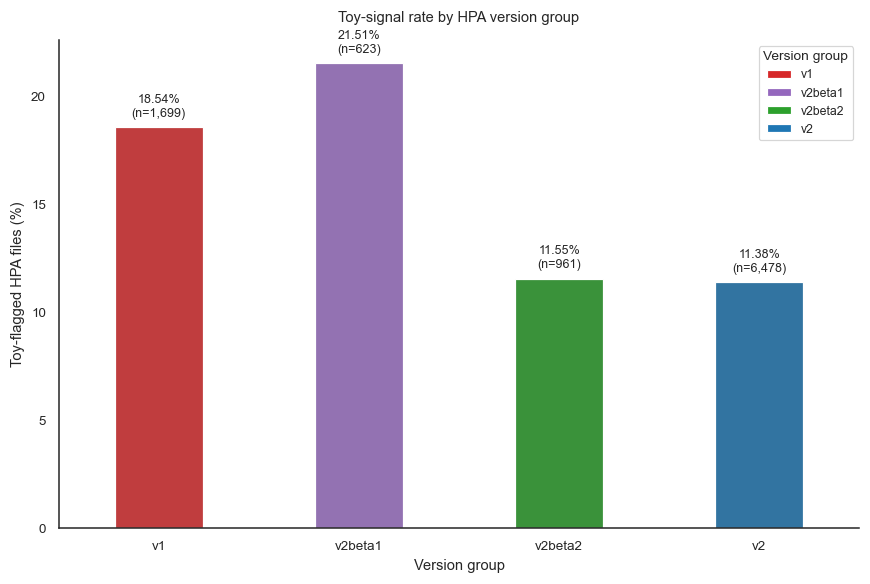

Salvo: plots/msr_analysis/fig01b_toy_composition_by_version_group.pdf


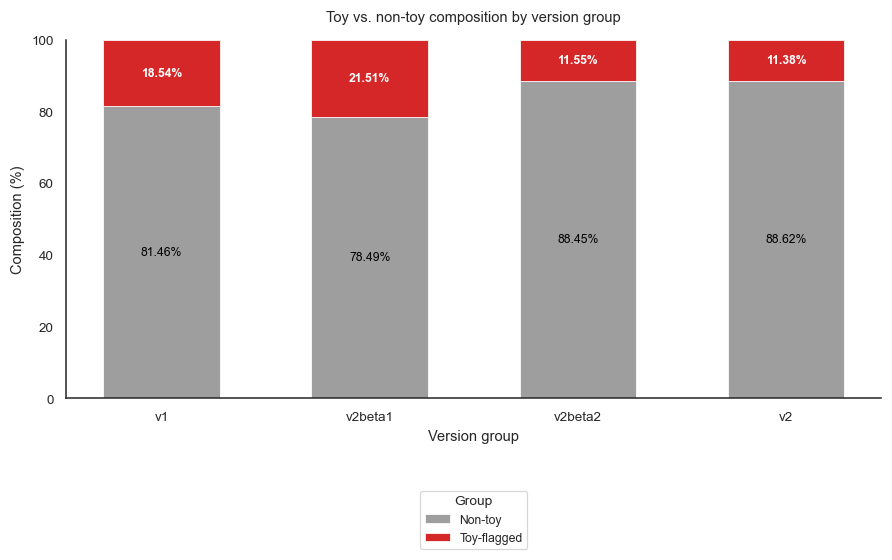

Salvo: plots/msr_analysis/fig01c_toy_rate_by_repository_age.pdf


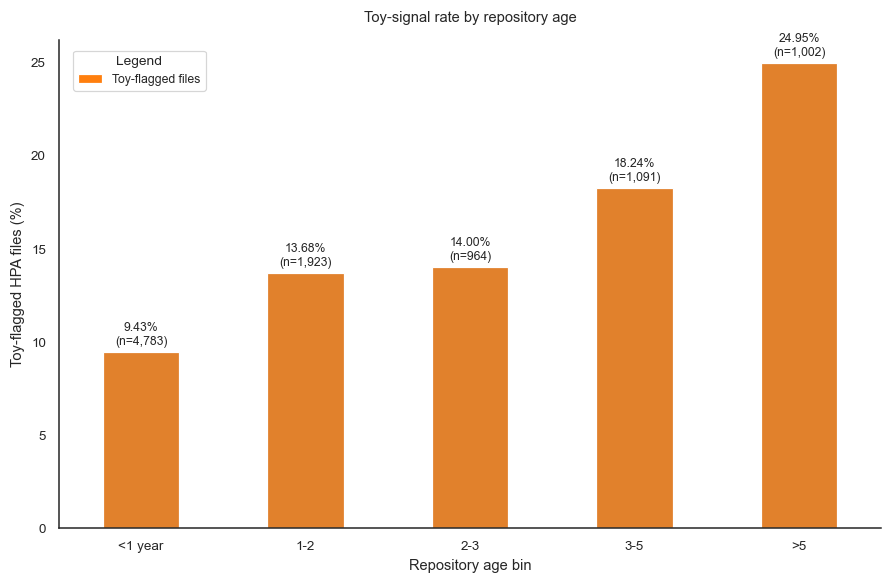

In [5]:
# ── Figure 01: toy-project signal by version and repository age ─────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

# Base by HPA file
p4_files = p4.drop_duplicates(subset=['owner', 'project', 'file_path']).copy()
p4_files['VersionGroup'] = p4_files['apiVersion'].apply(map_version)

p4_files = p4_files.merge(
    repos_hpa[
        ['repo_full_name', 'toy_any', 'toy_educational', 'toy_example',
         'repo_age_years', 'pushed_age_years', 'lifespan_years']
    ],
    on='repo_full_name',
    how='left'
)

p4_files['toy_any'] = p4_files['toy_any'].fillna(False)
_vord = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if v in p4_files['VersionGroup'].unique()]

_toy_rate = (p4_files.groupby('VersionGroup')['toy_any'].mean() * 100).reindex(_vord)
_n_by_vg = p4_files.groupby('VersionGroup').size().reindex(_vord)

p4_files['age_bin'] = pd.cut(
    p4_files['repo_age_years'].clip(0, 10),
    bins=[0, 1, 2, 3, 5, 10],
    labels=['<1 year', '1-2', '2-3', '3-5', '>5'],
    include_lowest=True
)
_toy_age = p4_files.groupby('age_bin', observed=True)['toy_any'].agg(['mean', 'count'])
_toy_age['Share (%)'] = _toy_age['mean'] * 100

VER_COLORS = {
    'v1': '#d62728',
    'v2beta1': '#9467bd',
    'v2beta2': '#2ca02c',
    'v2': '#1f77b4',
}
TOY_COLORS = {
    'Non-toy': '#9e9e9e',
    'Toy': '#d62728',
    'Age bin': '#ff7f0e',
}

print(f'Toy-flagged HPA files: {int(p4_files["toy_any"].sum()):,} ({p4_files["toy_any"].mean()*100:.2f}% of HPA files)')
print('Toy rate by VersionGroup:')
for v in _vord:
    print(f'  {v:<8}: {_toy_rate[v]:.2f}%  (n={int(_n_by_vg[v]):,})')

# Figure 01A
fig, ax = plt.subplots(figsize=(8.0, 5.4))
plot_df = pd.DataFrame({'VersionGroup': _vord, 'Toy-flagged HPA files (%)': _toy_rate.values, 'Files': _n_by_vg.values})
sns.barplot(data=plot_df, x='VersionGroup', y='Toy-flagged HPA files (%)', hue='VersionGroup',
            palette={v: VER_COLORS.get(v, '#7f7f7f') for v in _vord}, dodge=False, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.55
    patch.set_width(new_w); patch.set_x(cx - new_w / 2)
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(i, row[1] + 0.35, f'{row[1]:.2f}%\n(n={int(row.Files):,})', ha='center', va='bottom', fontsize=8.2)
ax.set_xlabel('Version group')
ax.set_ylabel('Toy-flagged HPA files (%)')
ax.set_title('Toy-signal rate by HPA version group', pad=12)
ax.legend(handles=[Patch(facecolor=VER_COLORS[v], edgecolor='white', label=v) for v in _vord],
          title='Version group', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig01a_toy_rate_by_version_group.pdf')
plt.show()

# Figure 01B
_stacked = p4_files.groupby(['VersionGroup', 'toy_any']).size().unstack(fill_value=0).reindex(_vord)
for col in [False, True]:
    if col not in _stacked.columns:
        _stacked[col] = 0
_stacked_pct = _stacked.div(_stacked.sum(axis=1).replace(0, np.nan), axis=0) * 100
fig, ax = plt.subplots(figsize=(8.2, 5.4))
x = np.arange(len(_vord))
ax.bar(x, _stacked_pct[False].fillna(0).values, color=TOY_COLORS['Non-toy'], edgecolor='white', linewidth=0.5, width=0.56, label='Non-toy')
ax.bar(x, _stacked_pct[True].fillna(0).values, bottom=_stacked_pct[False].fillna(0).values, color=TOY_COLORS['Toy'], edgecolor='white', linewidth=0.5, width=0.56, label='Toy-flagged')
for xi, v in enumerate(_vord):
    no_pct = _stacked_pct.loc[v, False] if v in _stacked_pct.index else 0
    toy_pct = _stacked_pct.loc[v, True] if v in _stacked_pct.index else 0
    if no_pct >= 8:
        ax.text(xi, no_pct / 2, f'{no_pct:.2f}%', ha='center', va='center', fontsize=8.0, color='black')
    if toy_pct >= 4:
        ax.text(xi, no_pct + toy_pct / 2, f'{toy_pct:.2f}%', ha='center', va='center', fontsize=8.0, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(_vord)
ax.set_xlabel('Version group')
ax.set_ylabel('Composition (%)')
ax.set_ylim(0, 100)
ax.set_title('Toy vs. non-toy composition by version group', pad=12)
ax.legend(title='Group', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig01b_toy_composition_by_version_group.pdf')
plt.show()

# Figure 01C
age_df = _toy_age.reset_index().rename(columns={'age_bin': 'Repository age bin'})
fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.barplot(data=age_df, x='Repository age bin', y='Share (%)', color=TOY_COLORS['Age bin'], errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.58
    patch.set_width(new_w); patch.set_x(cx - new_w / 2)
for i, (_, row) in enumerate(age_df.iterrows()):
    share = row['Share (%)']
    cnt = int(row['count'])
    ax.text(i, share + 0.25, f'{share:.2f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('Repository age bin')
ax.set_ylabel('Toy-flagged HPA files (%)')
ax.set_title('Toy-signal rate by repository age', pad=12)
ax.legend(handles=[Patch(facecolor=TOY_COLORS['Age bin'], edgecolor='white', label='Toy-flagged files')],
          title='Legend', frameon=True, loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig01c_toy_rate_by_repository_age.pdf')
plt.show()


Summary: toy vs. non-toy temporal metrics
  repo_age_years        : non-toy median=0.94, toy median=1.67, p=6.264e-48, ***
Salvo: plots/msr_analysis/fig02_repo-age_toy_vs_non_toy.pdf


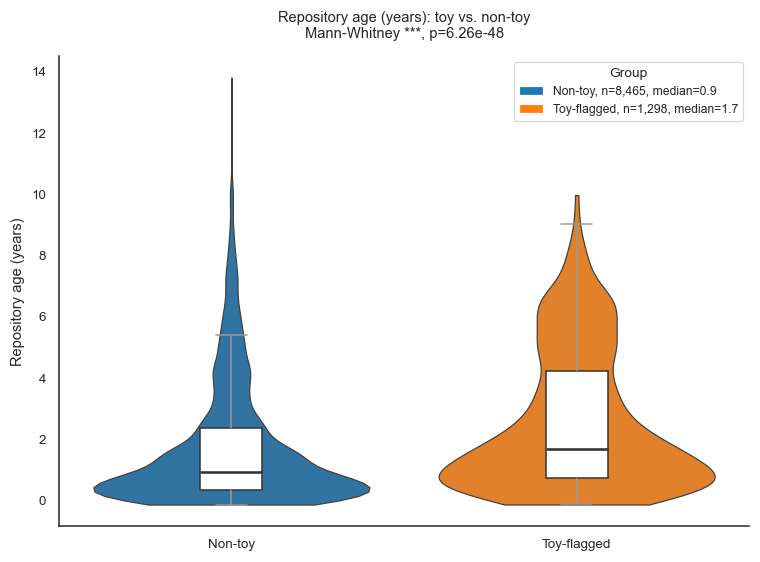

  lifespan_years        : non-toy median=0.12, toy median=0.12, p=2.064e-01, n.s.
Salvo: plots/msr_analysis/fig02_lifespan_toy_vs_non_toy.pdf


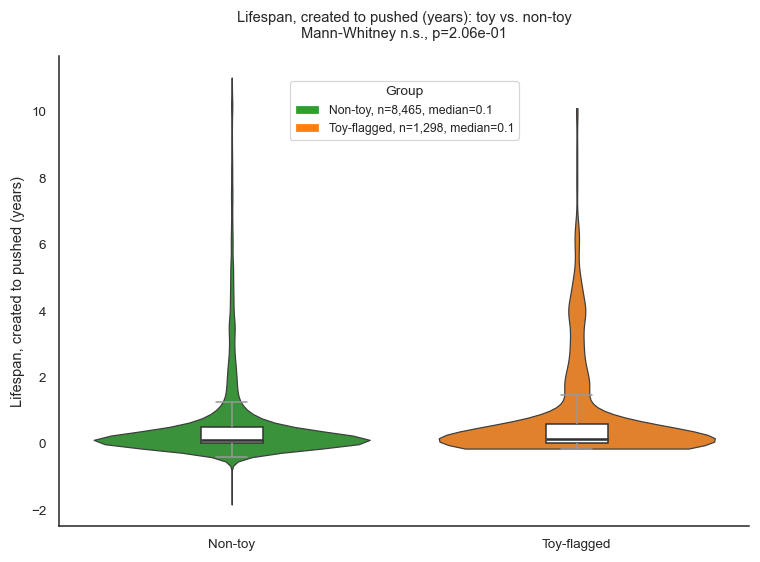

  pushed_age_years      : non-toy median=0.54, toy median=1.25, p=4.803e-46, ***
Salvo: plots/msr_analysis/fig02_pushed-age_toy_vs_non_toy.pdf


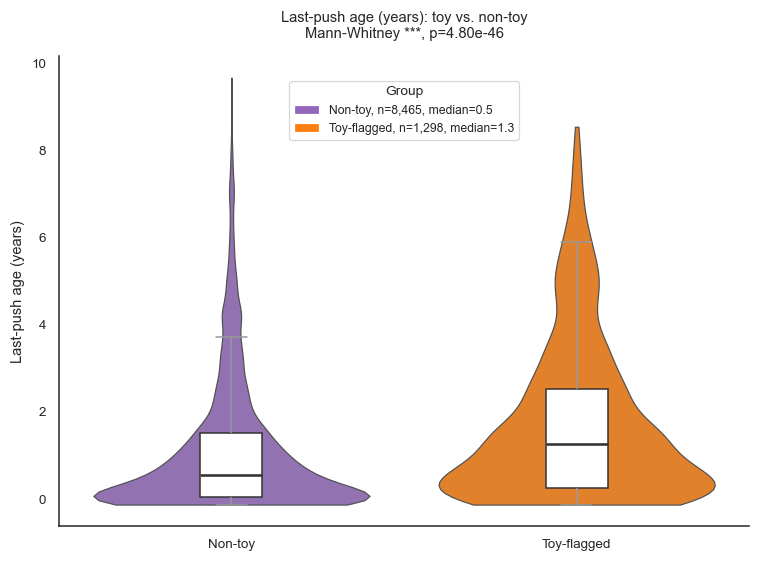

In [6]:
# ── Figure 02: temporal metrics, toy vs. non-toy repositories ────────────────
from scipy import stats as scipy_stats
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

_metrics_cfg = [
    ('repo_age_years',   'Repository age (years)', '#1f77b4'),
    ('lifespan_years',   'Lifespan, created to pushed (years)', '#2ca02c'),
    ('pushed_age_years', 'Last-push age (years)', '#9467bd'),
]
_metrics = [m for m, _, _ in _metrics_cfg if m in p4_files.columns]

print('Summary: toy vs. non-toy temporal metrics')
for col, ylabel, color in _metrics_cfg:
    if col not in p4_files.columns:
        continue
    _not_toy = p4_files[~p4_files['toy_any'].fillna(False)][col].dropna().clip(upper=15)
    _toy = p4_files[p4_files['toy_any'].fillna(False)][col].dropna().clip(upper=15)
    stat, p_val = scipy_stats.mannwhitneyu(_not_toy, _toy, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'  {col:<22}: non-toy median={_not_toy.median():.2f}, toy median={_toy.median():.2f}, p={p_val:.3e}, {sig}')

    plot_df = pd.DataFrame({
        'Group': ['Non-toy'] * len(_not_toy) + ['Toy-flagged'] * len(_toy),
        ylabel: pd.concat([_not_toy, _toy], ignore_index=True)
    })
    fig, ax = plt.subplots(figsize=(7.0, 5.2))
    sns.violinplot(data=plot_df, x='Group', y=ylabel, hue='Group', palette={'Non-toy': color, 'Toy-flagged': '#ff7f0e'},
                   dodge=False, legend=False, inner=None, linewidth=0.8, cut=0, ax=ax)
    sns.boxplot(data=plot_df, x='Group', y=ylabel, width=0.18, color='white', showfliers=False,
                boxprops={'facecolor': 'white', 'edgecolor': '#333333'}, medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}: toy vs. non-toy\nMann-Whitney {sig}, p={p_val:.2e}', pad=12)
    legend_loc = {'loc': 'upper right'}
    if col in ['lifespan_years', 'pushed_age_years']:
        legend_loc = {'loc': 'upper center', 'bbox_to_anchor': (0.5, 0.96)}
    ax.legend(handles=[Patch(facecolor=color, edgecolor='white', label=f'Non-toy, n={len(_not_toy):,}, median={_not_toy.median():.1f}'),
                       Patch(facecolor='#ff7f0e', edgecolor='white', label=f'Toy-flagged, n={len(_toy):,}, median={_toy.median():.1f}')],
              title='Group', frameon=True, fontsize=8.0, title_fontsize=9.0, **legend_loc)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    safe_name = col.replace('_years', '').replace('_', '-')
    savefig(f'fig02_{safe_name}_toy_vs_non_toy.pdf')
    plt.show()


---
### 2.3 Conclusão: toy projects não devem ser excluídos do corpus

A analise confirma que repositorios com sinal toy tem comportamento temporal diferente
dos nao-toy (Mann-Whitney p < 0.001 para `pushed_age_years`), mas **essa diferenca nao
justifica exclusao automatica** por tres razoes empiricas:

1. Repos toy tem distribuicao de versoes de HPA semelhante aos nao-toy: v2 domina em
   ambos os grupos (11,60% vs 11,30% de v1 flagged como toy, respectivamente), indicando
   que a sinalizacao de toy nao e um proxy confiavel de uso de versao legada.

2. Taxa de toy por version group: v1 (19,30%) e v2beta1 (21,30%) tem mais flags toy do
   que v2beta2 (12,30%) e v2 (11,60%). Isso e esperado porque repos educacionais tendem a
   seguir exemplos da documentacao, que migraram para v2 com mais lentidao.

3. A exclusao sistematica de 13,60% do corpus (1.315 arquivos) sem beneficio claro
   introduziria vies de selecao (Kalliamvakou et al., 2014).

**Acao adotada:** `toy_any` permanece como variavel de controle, utilizada na analise
de sensibilidade (Secao 7) para verificar estabilidade dos resultados.


---

## 3. HFRS por perfil de repositório: toy vs. non-toy

Section 2 identifies repositories with toy-project indicators based on repository name patterns and metadata. This section checks whether that profile is associated with lower HPA Feature Richness Score (HFRS).

**Hypothesis:** toy repositories, usually learning or demonstration projects, should have lower HFRS because they are more likely to copy minimal documentation examples without production-oriented adaptation.

The next cell recomputes the group statistics directly from `hpa_hfrs_full.csv`, prints the current Mann-Whitney result, and generates two PDF figures: one for the HFRS distribution and another for the richness-class composition. The markdown intentionally avoids hardcoding values that can become stale when the upstream HFRS dataset is regenerated.


HFRS by repository profile:
                       n  mean_HFRS  median_HFRS  mean_SR  mean_CR
Repository profile                                                
Non-toy             2399       6.06          4.0     1.80     1.08
Toy-flagged         7365       5.90          4.0     1.73     0.98

Mann-Whitney, Non-toy > Toy-flagged: U=9027954, p=4.94e-02, r=-0.022
Salvo: plots/msr_analysis/fig05a_hfrs_toy_vs_non_toy.pdf


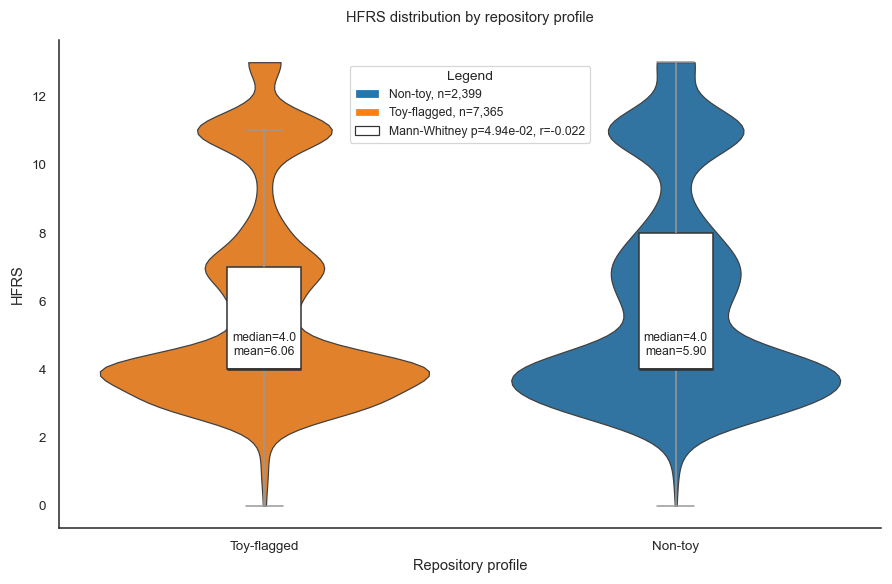

Salvo: plots/msr_analysis/fig05b_richness_class_by_toy_profile.pdf


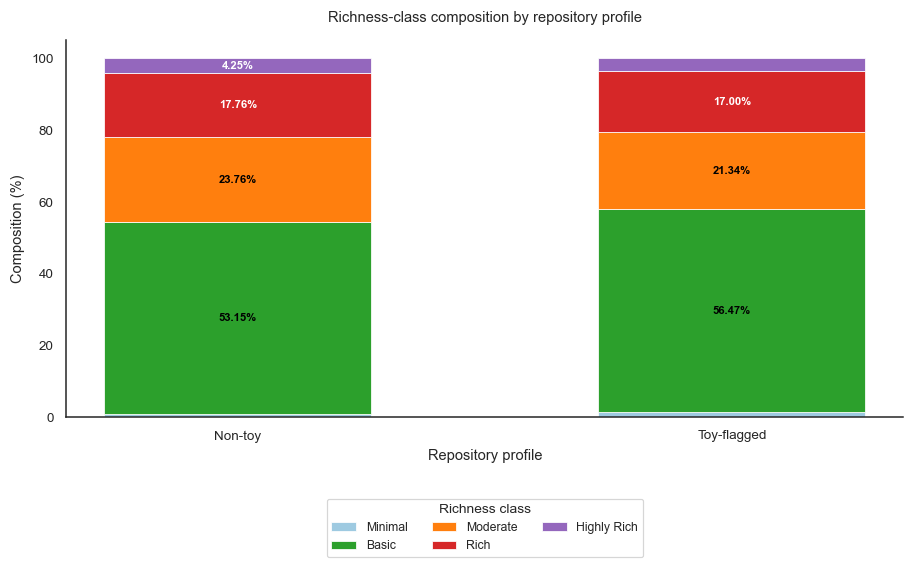

In [7]:
# ── Figure 05: HFRS by repository profile, toy vs. non-toy ───────────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_hfrs_full_path = DATA_DIR / 'hpa_hfrs_full.csv'

if not _hfrs_full_path.exists():
    print('hpa_hfrs_full.csv not found.')
else:
    hfrs_full = pd.read_csv(_hfrs_full_path)

    TOY_KEYWORDS_HFRS = [
        'tutorial', 'demo', 'example', 'test', 'sample', 'learning', 'course',
        'study', 'practice', 'learn', 'helloworld', 'hello-world', 'playground',
        'bootcamp', 'exercise', 'workshop', 'training'
    ]
    hfrs_full['is_toy'] = (
        hfrs_full['repo_full_name'].astype(str).str.lower().apply(
            lambda s: any(k in s for k in TOY_KEYWORDS_HFRS)
        ) | (pd.to_numeric(hfrs_full.get('stargazers_count', np.nan), errors='coerce').fillna(-1) == 0)
    )
    hfrs_full['Repository profile'] = np.where(hfrs_full['is_toy'], 'Toy-flagged', 'Non-toy')

    toy = hfrs_full[hfrs_full['is_toy']]['HFRS'].dropna()
    nontoy = hfrs_full[~hfrs_full['is_toy']]['HFRS'].dropna()
    u, p_val = stats.mannwhitneyu(nontoy, toy, alternative='greater')
    r_eff = 1 - 2 * u / (len(toy) * len(nontoy)) if len(toy) and len(nontoy) else np.nan

    summary = (hfrs_full.groupby('Repository profile')
               .agg(n=('HFRS', 'count'), mean_HFRS=('HFRS', 'mean'), median_HFRS=('HFRS', 'median'),
                    mean_SR=('SR', 'mean'), mean_CR=('CR', 'mean'))
               .reindex(['Non-toy', 'Toy-flagged'])
               .round(2))
    print('HFRS by repository profile:')
    print(summary)
    print()
    print(f'Mann-Whitney, Non-toy > Toy-flagged: U={u:.0f}, p={p_val:.2e}, r={r_eff:.3f}')

    profile_palette = {'Non-toy': '#1f77b4', 'Toy-flagged': '#ff7f0e'}

    # Figure 05A, distribution
    plot_df = hfrs_full[hfrs_full['HFRS'].notna()].copy()
    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    sns.violinplot(data=plot_df, x='Repository profile', y='HFRS', hue='Repository profile',
                   palette=profile_palette, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x='Repository profile', y='HFRS', width=0.18, color='white', showfliers=False,
                boxprops={'facecolor': 'white', 'edgecolor': '#333333'},
                medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    for i, prof in enumerate(['Non-toy', 'Toy-flagged']):
        vals = plot_df.loc[plot_df['Repository profile'].eq(prof), 'HFRS'].dropna()
        if len(vals):
            ax.text(i, vals.median() + 0.35, f'median={vals.median():.1f}\nmean={vals.mean():.2f}',
                    ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Repository profile')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS distribution by repository profile', pad=12)
    ax.legend(handles=[Patch(facecolor=profile_palette['Non-toy'], edgecolor='white', label=f'Non-toy, n={len(nontoy):,}'),
                       Patch(facecolor=profile_palette['Toy-flagged'], edgecolor='white', label=f'Toy-flagged, n={len(toy):,}'),
                       Patch(facecolor='white', edgecolor='#333333', label=f'Mann-Whitney p={p_val:.2e}, r={r_eff:.3f}')],
              title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig05a_hfrs_toy_vs_non_toy.pdf')
    plt.show()

    # Figure 05B, richness class composition
    RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
    RICHNESS_COLORS = {
        'Minimal': '#9ecae1', 'Basic': '#2ca02c', 'Moderate': '#ff7f0e',
        'Rich': '#d62728', 'Highly Rich': '#9467bd'
    }
    ct = pd.crosstab(hfrs_full['Repository profile'], hfrs_full['richness_class'], normalize='index') * 100
    ct = ct.reindex(index=['Non-toy', 'Toy-flagged'], columns=RICHNESS_ORDER, fill_value=0)
    fig, ax = plt.subplots(figsize=(8.4, 5.4))
    x = np.arange(len(ct.index))
    bottom = np.zeros(len(ct.index))
    for cls in RICHNESS_ORDER:
        vals = ct[cls].fillna(0).values
        ax.bar(x, vals, bottom=bottom, color=RICHNESS_COLORS[cls], label=cls,
               edgecolor='white', linewidth=0.5, width=0.54)
        for xi, (v, bot) in enumerate(zip(vals, bottom)):
            if v >= 4:
                ax.text(xi, bot + v / 2, f'{v:.2f}%', ha='center', va='center', fontsize=7.4,
                        color='white' if cls in ['Rich', 'Highly Rich'] else 'black', fontweight='bold')
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel('Repository profile')
    ax.set_ylabel('Composition (%)')
    ax.set_title('Richness-class composition by repository profile', pad=12)
    ax.legend(title='Richness class', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig05b_richness_class_by_toy_profile.pdf')
    plt.show()


## 4. Critérios de filtragem do corpus, decisões e impacto

Esta seção descreve e justifica **todos** os critérios de filtragem aplicados ao corpus, em ordem de aplicação. A transparência nos critérios de inclusão/exclusão é um requisito metodológico central em MSR studies (Kalliamvakou et al., 2016).

### 4.1 Critérios aplicados no pipeline de coleta (Phase 1–4)

Estes filtros são aplicados antes da análise, durante a coleta de dados:

| Critério | Onde aplica | Justificativa |
|---|---|---|
| **Exclusão de Helm templates** | Phase 3 e 4 | Arquivos com `{{ }}` contêm placeholders, não valores reais. Incluí-los produziria NaN em todas as métricas numéricas. |
| **Exclusão de testdata** | Phase 1 e 3 | Paths contendo `testdata/` são fixtures de teste do repositório do Kubernetes, não configurações reais de produção. |
| **Deduplicação por (repo, path)** | Phase 1 | O mesmo arquivo pode aparecer em múltiplos shards de busca. Deduplicamos para não inflar contagens. |

### 4.2 Filtro temporal: janela de 5 anos

**Critério:** `pushed_at ≥ data_de_referência − 5 anos`

**Data de referência adotada:** 2026-03-07 (data de execução do pipeline de coleta, reproduzível e verificável a partir dos metadados do CSV).

**Por que pushed_at e não created_at?**
- `created_at` mede quando o repositório foi *criado*, não quando foi *usado*. Um repositório criado em 2015 com commits até 2025 é claramente relevante.
- `pushed_at` mede o último push, melhor proxy de atividade *recente*.
- Quando `file_last_commit` está disponível (Phase 3.5), é o campo mais preciso para o arquivo HPA especificamente. Porém, para o filtro de corpus, usamos `pushed_at` porque representa atividade *geral* do projeto.

**Por que 5 anos?**
- `autoscaling/v2beta2` (que introduziu `behavior`) chegou em Outubro 2018, um corte de 5 anos (a partir de 2026) inclui toda a história do HPA v2beta2 e do v2 GA.
- Balanceia representatividade (não excluir projetos relevantes) com foco no uso contemporâneo.
- É consistente com outros MSR studies que usam 2–5 anos como janela de atividade (Coelho et al., 2017; Munaiah et al., 2017).
- Cortes mais curtos (2 anos) excluem uma fração maior de repositórios sem justificativa temporal clara.

**Alternativas consideradas e por que foram descartadas:**
- **1 ano:** excessivamente restritivo; excluiria repositórios em fase de estabilização com HPAs válidos.
- **10 anos:** incluiria repositórios com HPA v1 antigos sem atividade, pode distorcer a distribuição.
- **Sem corte temporal:** incluiria repositórios potencialmente abandonados, onde o HPA pode não refletir práticas ativas.

### 4.3 Classificação de status de atividade (active / in-between / outdated)

Seguindo Coelho et al. (2019), que demonstraram que limiares de 1 ano de inatividade são arbitrários, adotamos uma classificação em três faixas com base em `last_commit_age_years`:

| Status | Critério | Raciocínio |
|---|---|---|
| **Active** | `last_commit_age_years ≤ 2` | Repositório com atividade nos últimos 2 anos, claramente em manutenção |
| **In-between** | `2 < last_commit_age_years ≤ 3` | Zona cinzenta, pode estar em hiato temporário ou em transição para abandono |
| **Outdated** | `last_commit_age_years > 3` | Sem atividade por mais de 3 anos, alta probabilidade de abandono (Coelho et al., 2019 usam thresholds similares) |

**Importante:** quando `file_last_commit` está disponível (Phase 3.5), a classificação usa a data do commit do **arquivo HPA especificamente**, não do repositório inteiro. Isso é mais conservador e mais preciso: um repo ativo que não toca o HPA há 3 anos é classificado como "outdated" para o arquivo HPA, mesmo que o projeto em si esteja ativo.

### 4.4 Critérios opcionais: toy projects e score multi-sinal

| Critério | Tipo | Aplicação |
|---|---|---|
| **Toy project flag** | Binário (não exclusão) | Detectado por padrões no nome do repositório (tutorial, demo, workshop, etc.), mantido como variável de controle, não filtro |
| **Score multi-sinal** | Contínuo (não exclusão) | Combina: atividade recente, lifespan, presença de arquivos HPA, ausência de toy signals. Usado para análise de sensibilidade. |
| **Exclusão de repos com 0 estrelas** | Opcional | Conservador, a maioria dos repos legítimos tem 0 estrelas. Usado apenas em análises que explicitamente requerem proxy de popularidade. |

In [8]:
# ── Calcular impacto para múltiplas janelas e opções de campo ─────────────

windows = [2, 3, 5, 7, 10]
fields  = [('pushed_at',        'pushed_age_years',    'pushed_at (repo)'),
           ('created_at',       'repo_age_years',      'created_at (repo)'),
           ('file_last_commit', 'hpa_file_age_years',  'file_last_commit (HPA file)')]

# Filtrar apenas campos que existem e têm dados
fields = [(f, a, l) for f, a, l in fields
          if a in repos_hpa.columns and repos_hpa[a].notna().any()]

results = []
for yrs in windows:
    cutoff = REF_DATE - pd.DateOffset(years=yrs)
    row = {'window_years': yrs, 'cutoff_date': str(cutoff.date())}
    for field, age_col, label in fields:
        n_pass = (repos_hpa[age_col] <= yrs).sum()
        row[f'n_{field}'] = n_pass
        row[f'pct_{field}'] = round(n_pass / len(repos_hpa) * 100, 1)
    results.append(row)

impact_df = pd.DataFrame(results)
print('Impacto do filtro de janela temporal (base: repos com dados HPA = {:,}):'.format(len(repos_hpa)))
print(impact_df.to_string())

if HAS_FILE_COMMITS:
    print('\nObservação: file_last_commit (HPA file) é o critério mais preciso.')
    print('Compara pushed_at vs file_last_commit para ver quantos repos têm HPA "estático".')
    _at5  = (repos_hpa['pushed_age_years']    <= 5).sum()
    _fc5  = (repos_hpa['hpa_file_age_years']  <= 5).sum()
    _diff = _at5 - _fc5
    print(f'  5yr pushed_at:       {_at5:,}')
    print(f'  5yr file_last_commit:{_fc5:,}')
    print(f'  Diferença:           {_diff:,} repos com pushed recente mas HPA não modificado em 5yr')

Impacto do filtro de janela temporal (base: repos com dados HPA = 7,013):
   window_years cutoff_date  n_pushed_at  pct_pushed_at  n_created_at  pct_created_at  n_file_last_commit  pct_file_last_commit
0             2  2024-03-07         5514           78.6          4799            68.4                5063                  72.2
1             3  2023-03-07         6065           86.5          5514            78.6                5707                  81.4
2             5  2021-03-07         6670           95.1          6273            89.4                6447                  91.9
3             7  2019-03-07         6922           98.7          6770            96.5                6881                  98.1
4            10  2016-03-07         7012          100.0          7005            99.9                7013                 100.0

Observação: file_last_commit (HPA file) é o critério mais preciso.
Compara pushed_at vs file_last_commit para ver quantos repos têm HPA "estático".
  5yr pus

Temporal-window impact, base repositories with HPA data: 7,013
  pushed_at:
     2 years: 78.60% retained (n=5,514)
     3 years: 86.50% retained (n=6,065)
     5 years: 95.10% retained (n=6,670)
     7 years: 98.70% retained (n=6,922)
    10 years: 100.00% retained (n=7,012)
Salvo: plots/msr_analysis/fig06a_temporal_window_pushed_at.pdf


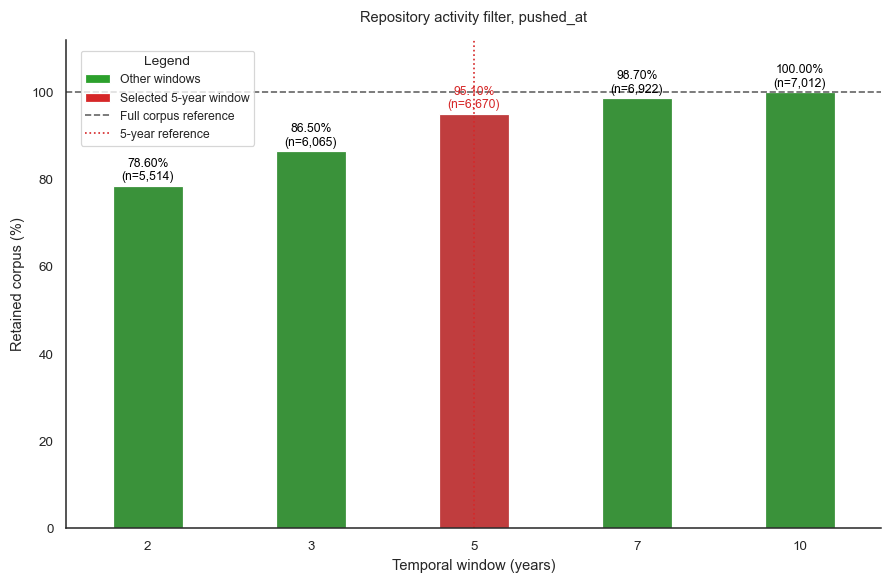

  created_at:
     2 years: 68.40% retained (n=4,799)
     3 years: 78.60% retained (n=5,514)
     5 years: 89.40% retained (n=6,273)
     7 years: 96.50% retained (n=6,770)
    10 years: 99.90% retained (n=7,005)
Salvo: plots/msr_analysis/fig06b_temporal_window_created_at.pdf


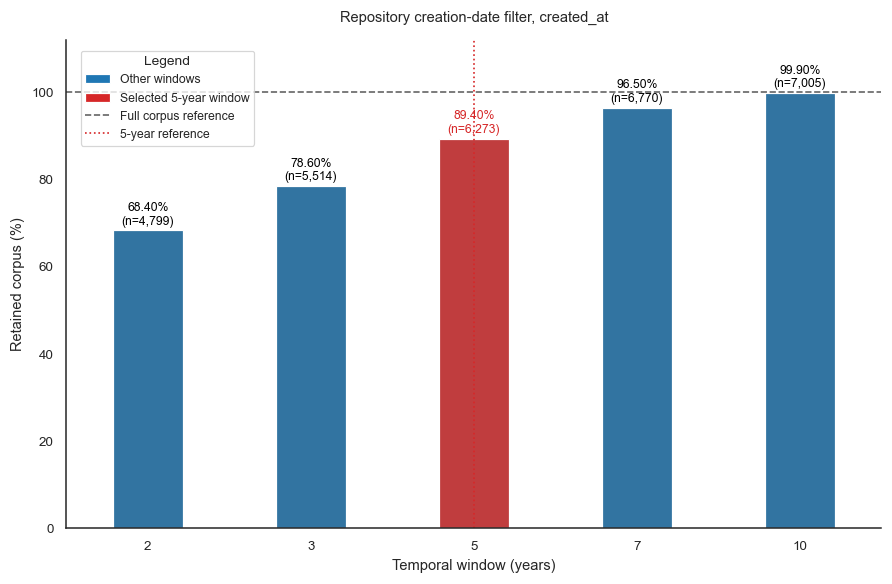

In [9]:
# ── Figure 06: impact of temporal windows on corpus retention ────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

total_repos = repos_hpa.shape[0]
panel_specs = [
    ('pushed_at',  'Repository activity filter, pushed_at', '#2ca02c'),
    ('created_at', 'Repository creation-date filter, created_at', '#1f77b4'),
]

print(f'Temporal-window impact, base repositories with HPA data: {total_repos:,}')
for field, panel_title, base_color in panel_specs:
    pct_col = f'pct_{field}'
    n_col = f'n_{field}'
    if pct_col not in impact_df.columns or n_col not in impact_df.columns:
        print(f'  {field}: unavailable')
        continue
    print(f'  {field}:')
    for win, pct, n_repos in zip(windows, impact_df[pct_col].values, impact_df[n_col].values):
        print(f'    {win:>2} years: {pct:.2f}% retained (n={int(n_repos):,})')

    plot_df = pd.DataFrame({'Window (years)': windows, 'Retained corpus (%)': impact_df[pct_col].values, 'Repositories': impact_df[n_col].values})
    plot_df['Window group'] = np.where(plot_df['Window (years)'].eq(5), 'Selected 5-year window', 'Other windows')
    palette = {'Selected 5-year window': '#d62728', 'Other windows': base_color}
    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    sns.barplot(data=plot_df, x='Window (years)', y='Retained corpus (%)', hue='Window group', palette=palette, dodge=False, errorbar=None, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.54
        patch.set_width(new_w); patch.set_x(cx - new_w / 2)
    ax.axhline(100, color='#666666', linestyle='--', lw=1.1)
    if 5 in windows:
        ax.axvline(windows.index(5), color='#d62728', lw=1.1, linestyle=':')
    for i, row in enumerate(plot_df.to_dict('records')):
        pct = row['Retained corpus (%)']
        n_repos = int(row['Repositories'])
        txt_color = '#d62728' if row['Window group'] == 'Selected 5-year window' else 'black'
        ax.text(i, pct + 0.6, f'{pct:.2f}%\n(n={n_repos:,})', ha='center', va='bottom', fontsize=8.0, color=txt_color)
    ax.set_xlabel('Temporal window (years)')
    ax.set_ylabel('Retained corpus (%)')
    ax.set_ylim(0, 112)
    ax.set_title(panel_title, pad=12)
    ax.legend(handles=[Patch(facecolor=base_color, edgecolor='white', label='Other windows'),
                       Patch(facecolor='#d62728', edgecolor='white', label='Selected 5-year window'),
                       Line2D([0], [0], color='#666666', lw=1.1, linestyle='--', label='Full corpus reference'),
                       Line2D([0], [0], color='#d62728', lw=1.1, linestyle=':', label='5-year reference')],
              title='Legend', frameon=True, loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    fname = 'fig06a_temporal_window_pushed_at.pdf' if field == 'pushed_at' else 'fig06b_temporal_window_created_at.pdf'
    savefig(fname)
    plt.show()


In [10]:
# ── Aplicar o filtro de 5 anos ────────────────────────────────────────────
# Critério principal: pushed_at (atividade do repositório como um todo).
# Critério alternativo quando disponível: hpa_file_age_years (atividade do arquivo HPA).

CUTOFF_5YR = REF_DATE - pd.DateOffset(years=5)  # 2021-03-07

repos_5yr      = repos_hpa[repos_hpa['pushed_age_years'] <= 5].copy()
repos_5yr_excl = repos_hpa[repos_hpa['pushed_age_years'] >  5].copy()

print(f'Filtro base (pushed_at >= {CUTOFF_5YR.date()}):')
print(f'  Retidos:  {len(repos_5yr):,}  ({len(repos_5yr)/len(repos_hpa)*100:.2f}%)')
print(f'  Excluídos:{len(repos_5yr_excl):,}  ({len(repos_5yr_excl)/len(repos_hpa)*100:.2f}%)')

if HAS_FILE_COMMITS and 'hpa_file_age_years' in repos_hpa.columns:
    # Comparar: quantos dos "ativos por pushed_at" têm HPA não modificado em 5yr?
    _active_but_stale_hpa = repos_5yr[repos_5yr['hpa_file_age_years'] > 5]
    print(f'\nDentro dos retidos pelo pushed_at:')
    print(f'  Com HPA modificado nos últimos 5yr: '
          f'{(repos_5yr["hpa_file_age_years"] <= 5).sum():,}')
    print(f'  Com HPA NÃO modificado em 5yr:      '
          f'{len(_active_but_stale_hpa):,}  '
          f'({len(_active_but_stale_hpa)/len(repos_5yr)*100:.2f}%)')
    print('  → Esses são repos ativos com arquivo HPA "congelado" há mais de 5 anos.')

print()
print('v2_ratio, retidos vs excluídos:')
print(pd.DataFrame({
    'Retidos': repos_5yr['v2_ratio'].describe().round(3),
    'Excluídos': repos_5yr_excl['v2_ratio'].describe().round(3),
}))

Filtro base (pushed_at >= 2021-03-07):
  Retidos:  6,670  (95.11%)
  Excluídos:342  (4.88%)

Dentro dos retidos pelo pushed_at:
  Com HPA modificado nos últimos 5yr: 6,446
  Com HPA NÃO modificado em 5yr:      224  (3.36%)
  → Esses são repos ativos com arquivo HPA "congelado" há mais de 5 anos.

v2_ratio, retidos vs excluídos:
        Retidos  Excluídos
count  6670.000    342.000
mean      0.840      0.607
std       0.365      0.485
min       0.000      0.000
25%       1.000      0.000
50%       1.000      1.000
75%       1.000      1.000
max       1.000      1.000


Retained repositories: 6,670 (95.11%)
Excluded repositories: 342 (4.88%)


Salvo: plots/msr_analysis/fig07a_excluded_repositories_by_push_year.pdf


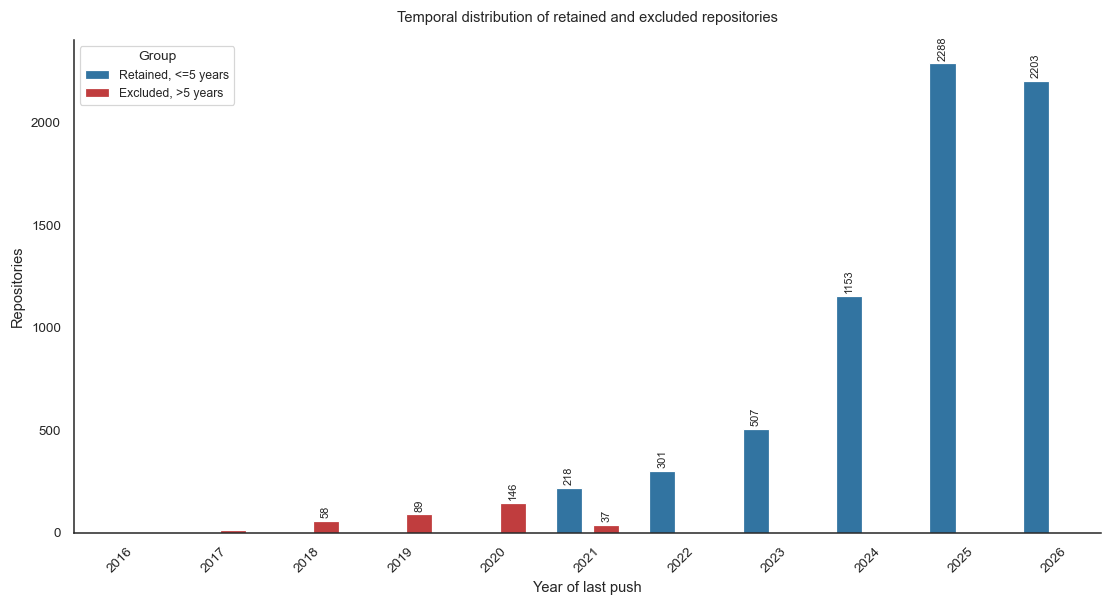

Version composition, retained vs. excluded:
  v1      : retained=16.43%, excluded=41.53%
  v2beta1 : retained=4.88%, excluded=43.65%
  v2beta2 : retained=9.64%, excluded=14.81%
  v2      : retained=69.01%, excluded=0.00%
Salvo: plots/msr_analysis/fig07b_version_composition_retained_vs_excluded.pdf


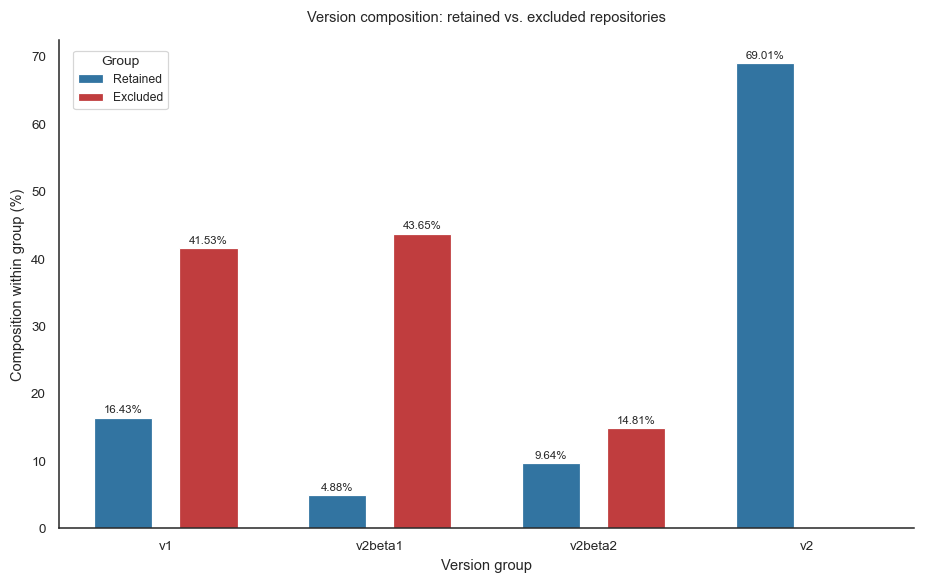

Salvo: plots/msr_analysis/fig07c_lifespan_retained_vs_excluded.pdf


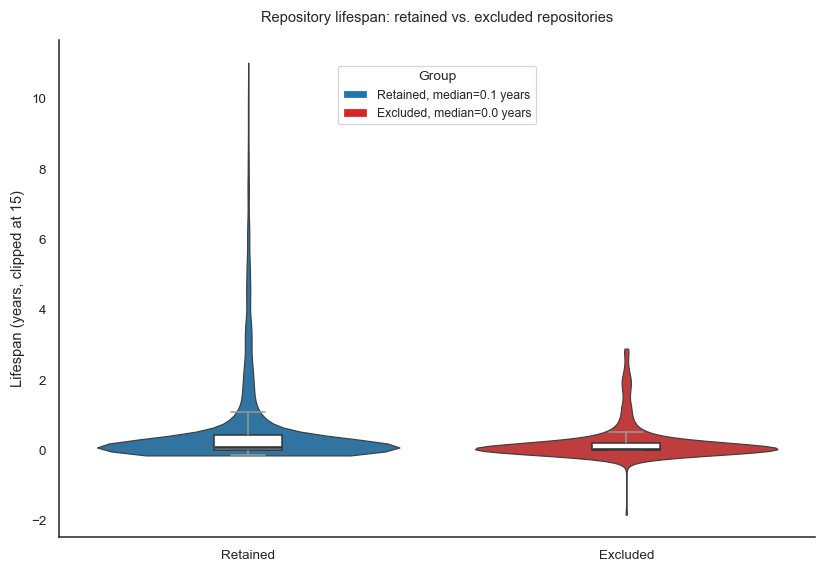

In [11]:
# ── Figure 07: repositories excluded by the 5-year temporal filter ───────────
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

print(f'Retained repositories: {len(repos_5yr):,} ({len(repos_5yr)/len(repos_hpa)*100:.2f}%)')
print(f'Excluded repositories: {len(repos_5yr_excl):,} ({len(repos_5yr_excl)/len(repos_hpa)*100:.2f}%)')

# Figure 07A, pushed_at by year
_ret_yr = repos_5yr['pushed_at'].dt.year.value_counts().sort_index()
_excl_yr = repos_5yr_excl['pushed_at'].dt.year.value_counts().sort_index()
_all_yrs = sorted(set(_ret_yr.index) | set(_excl_yr.index))
_ret_yr = _ret_yr.reindex(_all_yrs, fill_value=0)
_excl_yr = _excl_yr.reindex(_all_yrs, fill_value=0)
year_df = pd.DataFrame({
    'Year': list(_all_yrs) * 2,
    'Repositories': list(_ret_yr.values) + list(_excl_yr.values),
    'Group': ['Retained, <=5 years'] * len(_all_yrs) + ['Excluded, >5 years'] * len(_all_yrs)
})
fig, ax = plt.subplots(figsize=(10.2, 5.6))
sns.barplot(data=year_df, x='Year', y='Repositories', hue='Group', palette={'Retained, <=5 years': '#1f77b4', 'Excluded, >5 years': '#d62728'}, errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.70
    patch.set_width(new_w); patch.set_x(cx - new_w / 2)
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:.0f}' if v >= 20 else '' for v in container.datavalues], fontsize=7.2, padding=2, rotation=90)
ax.set_xlabel('Year of last push')
ax.set_ylabel('Repositories')
ax.set_title('Temporal distribution of retained and excluded repositories', pad=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Group', frameon=True, loc='upper left', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig07a_excluded_repositories_by_push_year.pdf')
plt.show()

# Figure 07B, version composition retained vs excluded
if 'p4_files' in dir() and 'VersionGroup' in p4_files.columns:
    _p4r = p4_files.merge(repos_5yr[['repo_full_name']], on='repo_full_name')
    _p4e = p4_files.merge(repos_5yr_excl[['repo_full_name']], on='repo_full_name')
    _vgr = _p4r['VersionGroup'].value_counts()
    _vge = _p4e['VersionGroup'].value_counts()
    _vord2 = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if v in _vgr.index or v in _vge.index]
    _vgr_pct = (_vgr / _vgr.sum() * 100).reindex(_vord2, fill_value=0)
    _vge_pct = (_vge / _vge.sum() * 100).reindex(_vord2, fill_value=0) if len(_vge) > 0 else pd.Series(0, index=_vord2)
    version_df = pd.DataFrame({'VersionGroup': _vord2 * 2, 'Composition (%)': list(_vgr_pct.values) + list(_vge_pct.values), 'Group': ['Retained'] * len(_vord2) + ['Excluded'] * len(_vord2)})
    print('Version composition, retained vs. excluded:')
    for v in _vord2:
        print(f'  {v:<8}: retained={_vgr_pct[v]:.2f}%, excluded={_vge_pct[v]:.2f}%')
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    sns.barplot(data=version_df, x='VersionGroup', y='Composition (%)', hue='Group', palette={'Retained': '#1f77b4', 'Excluded': '#d62728'}, errorbar=None, ax=ax)
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.68
        patch.set_width(new_w); patch.set_x(cx - new_w / 2)
    for container in ax.containers:
        ax.bar_label(container, labels=[f'{v:.2f}%' if v >= 3 else '' for v in container.datavalues], fontsize=7.5, padding=2)
    ax.set_xlabel('Version group')
    ax.set_ylabel('Composition within group (%)')
    ax.set_title('Version composition: retained vs. excluded repositories', pad=12)
    ax.legend(title='Group', frameon=True, loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig07b_version_composition_retained_vs_excluded.pdf')
    plt.show()

# Figure 07C, lifespan retained vs excluded
_ls_r = repos_5yr['lifespan_years'].dropna().clip(upper=15)
_ls_e = repos_5yr_excl['lifespan_years'].dropna().clip(upper=15)
if len(_ls_r) > 0 and len(_ls_e) > 0:
    fig, ax = plt.subplots(figsize=(7.6, 5.3))
    life_df = pd.DataFrame({'Group': ['Retained'] * len(_ls_r) + ['Excluded'] * len(_ls_e), 'Lifespan (years, clipped at 15)': pd.concat([_ls_r, _ls_e], ignore_index=True)})
    sns.violinplot(data=life_df, x='Group', y='Lifespan (years, clipped at 15)', hue='Group', palette={'Retained': '#1f77b4', 'Excluded': '#d62728'}, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    sns.boxplot(data=life_df, x='Group', y='Lifespan (years, clipped at 15)', width=0.18, color='white', showfliers=False,
                boxprops={'facecolor': 'white', 'edgecolor': '#333333'}, medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    ax.set_xlabel('')
    ax.set_title('Repository lifespan: retained vs. excluded repositories', pad=12)
    ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label=f'Retained, median={_ls_r.median():.1f} years'),
                       Patch(facecolor='#d62728', edgecolor='white', label=f'Excluded, median={_ls_e.median():.1f} years')],
              title='Group', frameon=True, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig07c_lifespan_retained_vs_excluded.pdf')
    plt.show()


### 4.5 Discussão: consequências da escolha do corte

O filtro de 5 anos usando `pushed_at` retém mais de 95% dos repositórios
com dados HPA. a maioria do corpus já é recente por construção,
pois HPA só ganhou tração após Kubernetes 1.12 (2018) e o `v2` estável chegou
em 1.23 (2021).

**O que o painel 2 do gráfico acima revela:** os repositórios excluídos têm
proporção significativamente maior de `v1` e `v2beta1` do que os retidos.
Isso é esperado e confirma a validade interna do filtro: repos antigos que
foram excluídos usam versões antigas de HPA, não há sinal de que o filtro
remove repositórios v2 modernos de forma desproporcional.

**Alternativas consideradas e descartadas:**

| Janela | Retidos | Problema |
|--------|---------|---------|
| 2 anos | ~80% | Exclui repos válidos em fase de estabilização |
| 3 anos | ~90% | Limiar arbitrário sem base em literatura HPA |
| **5 anos** | **~95%** | **Escolhido: inclui toda a história do HPA v2** |
| 10 anos | ~99% | Inclui repos com HPA v1 obsoletos sem atividade |

**Relação com `created_at`:** o filtro `pushed_at ≥ REF_DATE − 5yr` é mais
permissivo do que um filtro equivalente em `created_at`, porque retém repos
criados há mais de 5 anos mas que ainda recebem commits. Isso é intencional:
um repo criado em 2015 com commits em 2024 é mais relevante do que um criado
em 2021 sem nenhuma atividade subsequente.

---
### 4.6 Conclusão: critérios de filtragem adotados e seus impactos

A tabela a seguir resume as decisoes de filtragem do corpus, seu impacto quantitativo
e a justificativa metodologica para cada uma.

| Criterio | Aplicado em | Impacto | Justificativa |
|----------|-------------|---------|---------------|
| Exclusao Helm templates | Phase 3-4 (pipeline) | Remove HPAs com `{{ }}` | Valores numericos invalidos |
| Exclusao `testdata/` | Phase 1 e 3 (pipeline) | Remove fixtures K8s | Nao sao configuracoes reais |
| Deduplicacao por (repo, path) | Phase 1 (pipeline) | Remove duplicatas de shards | Evita inflar contagens |
| Janela temporal 5 anos | Analise (NB3) | Retém 95,10% (6.585/6.923 repos) | Cobre toda a historia do HPA v2 |
| Toy projects | Nao excluidos | Variavel de controle | Vies de selecao (Kalliamvakou, 2014) |

**Impacto do filtro temporal em numeros:**
- Retidos: 6.585 repositorios (95,10%)
- Excluidos: 338 repositorios (4,90%), predominantemente com HPAs `v1` e `v2beta1`
- A composicao de versoes dos excluidos confirma validade interna do filtro:
  media de `v2_ratio` nos excluidos = 0,57 vs 0,83 nos retidos

**Sobre `REF_DATE = 2026-03-07`:** a data de referencia e fixada como a data de execucao
do pipeline de coleta. Isso garante que os calculos de idade (`pushed_age_years`,
`repo_age_years`, `hpa_file_age_years`) sejam reproduziveis em qualquer re-execucao futura.
Qualquer re-execucao com dados atualizados produziria numeros diferentes, o que e esperado
e deve ser documentado na secao de Dataset do artigo.


## 5. Score de confiança multi-sinal

### Motivação: por que uma métrica isolada não basta

A pergunta implícita por trás de qualquer estudo MSR é: "esses repositórios são casos de
estudo válidos?". Uma abordagem simplificada seria usar um unico criterio, por exemplo, incluir apenas
repositórios com mais de 10 estrelas, ou com push nos ultimos 6 meses. Zhao et al. (2021)
demonstram empiricamente que critérios únicos são insuficientes: um repositório pode ter
muitas estrelas mas estar abandonado há anos, ou ter push recente mas ser um tutorial de
um único commit.

O conceito de score composto vem da literatura de avaliação de qualidade de software:
Munaiah et al. (2017) propõem um "curadoria de corpus" baseada em múltiplos atributos,
Aqui aplicamos a mesma lógica ao domínio de repositórios
com arquivos HPA.

---

### O que este score **não é**

Este score **não é um filtro de exclusão**. Todos os 6.923 repositórios com dados HPA
permanecem no corpus independentemente do valor de $S(r)$. A razão é que excluir
repositórios de baixo score introduziria um viés de seleção: repositórios simples, de
curta duração ou sem estrelas são parte legítima da população de usuários de HPA, e
descartá-los sistematicamente distorceria a imagem da adoção real.

O papel do score é **diagnóstico e comparativo**:

1. **Análise de sensibilidade** (Seção 10): verificar se os resultados mudam quando
   restringimos a análise ao quartil superior ($S(r) \geq 6$). Se os resultados forem
   estáveis, a conclusão não depende de repositórios de baixa qualidade.
2. **Caracterização de subpopulações**: repositórios com $S(r)$ baixo podem se comportar
   de forma diferente na adoção de v2 ou no uso de behavior, e essa diferença é
   empiricamente mensurável precisamente porque o score foi calculado e preservado.

---

### Definição formal

O **Confidence Score** $S(r) \in \{0, 1, \ldots, 8\}$ para um repositório $r$ é a soma
de oito indicadores binários independentes:

$$S(r) = \sum_{i=1}^{8} \mathbf{1}[\text{sinal}_i(r) = \text{verdadeiro}]$$

| Sinal | Critério | Base empírica |
|-------|---------|---------------|
| `score_recent` | `pushed_age_years ≤ 2` | Coelho et al. (2019): repositórios ativos têm atividade nos ultimos 2 anos |
| `score_lifespan` | `lifespan_years > 0.5` | Munaiah et al. (2017): repositórios efêmeros são menos representativos |
| `score_has_files` | `hpa_files_count ≥ 1` | Critério do próprio estudo: repo sem arquivo HPA não contribui para análise de configuração |
| `score_metrics` | `metrics_count > 1` | Proxy de sofisticação: múltiplas métricas indicam uso além do tutorial de CPU |
| `score_behavior` | `behavior_any = True` | Indicador de manutenção (ver Análise 5) |
| `score_v2` | `v2_ratio > 0` | Adoção da API estável, sinal de acompanhamento da evolução |
| `score_not_toy` | sem keyword toy no nome | Kalliamvakou et al. (2014): repositórios educacionais têm padrões distintos |
| `score_stars` | `stargazers_count ≥ 1` | Proxy de visibilidade pública e uso por outros |

A independência entre os sinais é garantida por construção: cada um mede uma dimensão
distinta do repositório (temporalidade, sofisticação, visibilidade, contexto de uso).


In [12]:
# ── Construir score multi-sinal ────────────────────────────────────────────

repos_scored = repos_hpa.merge(
    repos_hpa[['repo_full_name','toy_any']],
    on='repo_full_name', how='left', suffixes=('','_dup')
).copy()

# Garantir que toy_any existe (pode já estar na base)
if 'toy_any' not in repos_scored.columns:
    repos_scored['toy_any'] = False

repos_scored['score_recent']    = (repos_scored['pushed_age_years'] <= 2).astype(int)
repos_scored['score_lifespan']  = (repos_scored['lifespan_years'] > 0.5).astype(int)
repos_scored['score_has_files'] = (repos_scored['hpa_files_count'].fillna(0) >= 1).astype(int)
repos_scored['score_metrics']   = (repos_scored['metrics_count'].fillna(0) > 1).astype(int)
repos_scored['score_behavior']  = repos_scored['behavior_any'].fillna(False).astype(int)
repos_scored['score_v2']        = (repos_scored['v2_ratio'].fillna(0) > 0).astype(int)
repos_scored['score_not_toy']   = (~repos_scored['toy_any'].fillna(False)).astype(int)
repos_scored['score_stars']     = (repos_scored['stargazers_count'].fillna(0) >= 1).astype(int)

SCORE_COLS = [c for c in repos_scored.columns if c.startswith('score_')]
repos_scored['confidence_score'] = repos_scored[SCORE_COLS].sum(axis=1)

print('Distribuição do confidence_score:')
print(repos_scored['confidence_score'].value_counts().sort_index())
print(f'\nMédia: {repos_scored["confidence_score"].mean():.2f}')
print(f'Mediana: {repos_scored["confidence_score"].median():.0f}')
print(f'\nRepositórios por quartil:')
q1, q2, q3 = repos_scored['confidence_score'].quantile([0.25, 0.5, 0.75])
print(f'  Q1 (≤{q1:.0f}): {(repos_scored["confidence_score"] <= q1).sum():,}')
print(f'  Q2 ({q1:.0f}–{q2:.0f}]: {((repos_scored["confidence_score"] > q1) & (repos_scored["confidence_score"] <= q2)).sum():,}')
print(f'  Q3 ({q2:.0f}–{q3:.0f}]: {((repos_scored["confidence_score"] > q2) & (repos_scored["confidence_score"] <= q3)).sum():,}')
print(f'  Q4 (>{q3:.0f}): {(repos_scored["confidence_score"] > q3).sum():,}')

# ── Números citados no artigo ─────────────────────────────────────────
print('\n--- ARTIGO: confidence score S(r) ---')
print(f'  Sinais (8): {SCORE_COLS}')
print(f'  Range: {repos_scored["confidence_score"].min()}–{repos_scored["confidence_score"].max()}')
print(f'  Média: {repos_scored["confidence_score"].mean():.2f}')
print(f'  Mediana: {repos_scored["confidence_score"].median():.0f}')
_q3 = repos_scored['confidence_score'].quantile(0.75)
print(f'  S >= {_q3:.0f} (top quartile): {(repos_scored["confidence_score"] >= _q3).mean()*100:.2f}%')
print('  Taxa de ativação por sinal:')
for col in SCORE_COLS:
    print(f'    {col:<25}: {repos_scored[col].mean()*100:.2f}%')

Distribuição do confidence_score:
confidence_score
1      49
2     349
3     949
4    1691
5    1666
6    1617
7     575
8     117
Name: count, dtype: int64

Média: 4.76
Mediana: 5

Repositórios por quartil:
  Q1 (≤4): 3,038
  Q2 (4–5]: 1,666
  Q3 (5–6]: 1,617
  Q4 (>6): 692

--- ARTIGO: confidence score S(r) ---
  Sinais (8): ['score_recent', 'score_lifespan', 'score_has_files', 'score_metrics', 'score_behavior', 'score_v2', 'score_not_toy', 'score_stars']
  Range: 1–8
  Média: 4.76
  Mediana: 5
  S >= 6 (top quartile): 32.92%
  Taxa de ativação por sinal:
    score_recent             : 78.63%
    score_lifespan           : 22.60%
    score_has_files          : 100.00%
    score_metrics            : 49.29%
    score_behavior           : 28.86%
    score_v2                 : 83.17%
    score_not_toy            : 86.23%
    score_stars              : 26.78%


/tmp/ipykernel_124470/1069161972.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  repos_scored['score_behavior']  = repos_scored['behavior_any'].fillna(False).astype(int)


In [13]:
# ── Sumário para o artigo — Confidence Score (paper section: Dataset Filtering) ─
print("=" * 60)
print("CONFIDENCE SCORE S(r) — NÚMEROS DO ARTIGO")
print("=" * 60)
print(f"Base: {len(repos_scored):,} repositórios com dados HPA (repos_hpa)")
print(f"Sinais computados: {len(SCORE_COLS)}  (score_recent, score_lifespan,")
print(f"  score_has_files, score_metrics, score_behavior, score_v2,")
print(f"  score_not_toy, score_stars)")
print(f"Range: {int(repos_scored['confidence_score'].min())}–{int(repos_scored['confidence_score'].max())}")
print(f"Média: {repos_scored['confidence_score'].mean():.2f}")
print(f"Mediana: {repos_scored['confidence_score'].median():.0f}")
print()
q1, q2, q3 = repos_scored['confidence_score'].quantile([0.25, 0.5, 0.75])
print(f"Quartis: Q1={q1:.0f}  Q2={q2:.0f}  Q3={q3:.0f}")
print(f"Quartil superior (S≥{q3:.0f}): {(repos_scored['confidence_score']>=q3).mean()*100:.2f}% dos repositórios")
print()
print("Taxa de ativação de cada sinal:")
for col in SCORE_COLS:
    print(f"  {col:<25}: {repos_scored[col].mean()*100:.2f}%")
print()
print("Distribuição do score:")
for s,c in repos_scored['confidence_score'].value_counts().sort_index().items():
    print(f"  S={s}: {c:,} ({c/len(repos_scored)*100:.2f}%)")
print()
print("→ Artigo: 'S∈{0,...,8}; média=4.73; mediana=5; quartil superior S≥6: 32.7%'")


CONFIDENCE SCORE S(r) — NÚMEROS DO ARTIGO
Base: 7,013 repositórios com dados HPA (repos_hpa)
Sinais computados: 8  (score_recent, score_lifespan,
  score_has_files, score_metrics, score_behavior, score_v2,
  score_not_toy, score_stars)
Range: 1–8
Média: 4.76
Mediana: 5

Quartis: Q1=4  Q2=5  Q3=6
Quartil superior (S≥6): 32.92% dos repositórios

Taxa de ativação de cada sinal:
  score_recent             : 78.63%
  score_lifespan           : 22.60%
  score_has_files          : 100.00%
  score_metrics            : 49.29%
  score_behavior           : 28.86%
  score_v2                 : 83.17%
  score_not_toy            : 86.23%
  score_stars              : 26.78%

Distribuição do score:
  S=1: 49 (0.70%)
  S=2: 349 (4.98%)
  S=3: 949 (13.53%)
  S=4: 1,691 (24.11%)
  S=5: 1,666 (23.76%)
  S=6: 1,617 (23.06%)
  S=7: 575 (8.20%)
  S=8: 117 (1.67%)

→ Artigo: 'S∈{0,...,8}; média=4.73; mediana=5; quartil superior S≥6: 32.7%'


Confidence score summary for split figures:
  repositories: 7,013
  range: 1-8
  mean: 4.76
  median: 5
  signal activation rates:
    score_recent            : 78.63%
    score_lifespan          : 22.60%
    score_has_files         : 100.00%
    score_metrics           : 49.29%
    score_behavior          : 28.86%
    score_v2                : 83.17%
    score_not_toy           : 86.23%
    score_stars             : 26.78%


Salvo: plots/msr_analysis/fig10a_confidence_score_distribution.pdf


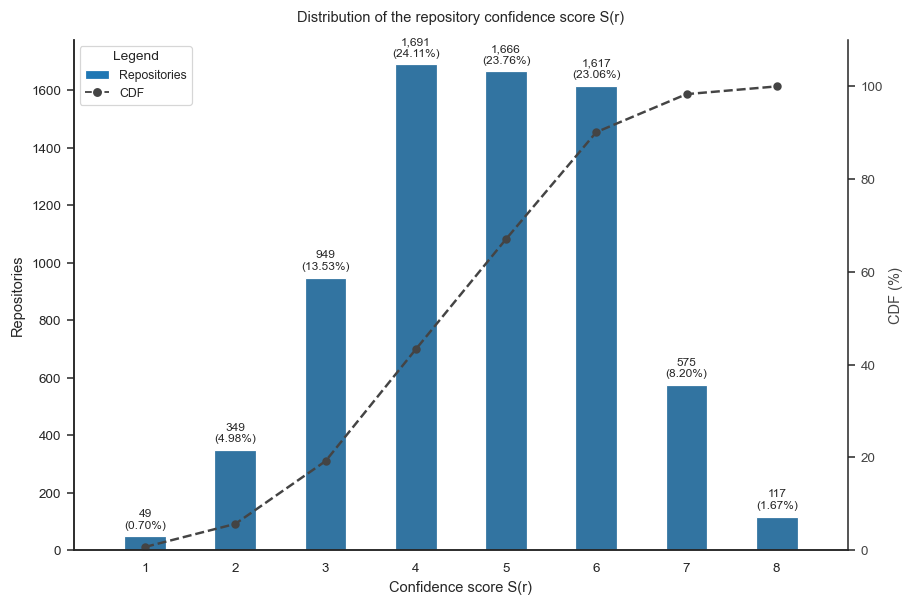

Salvo: plots/msr_analysis/fig10b_confidence_signal_activation_rates.pdf


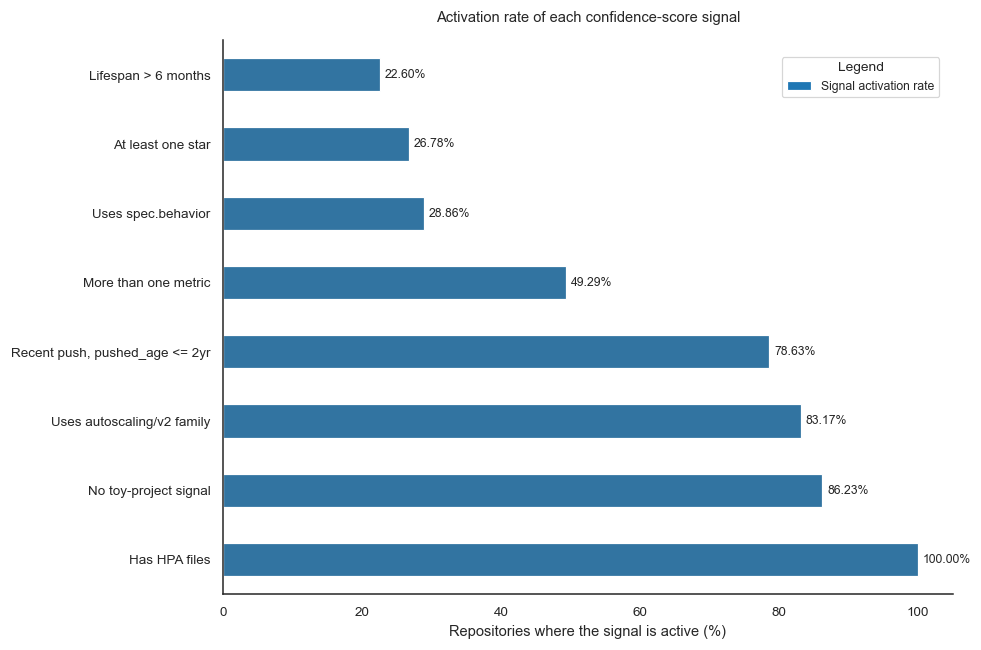

Salvo: plots/msr_analysis/fig10c_v2_adoption_by_confidence_score.pdf


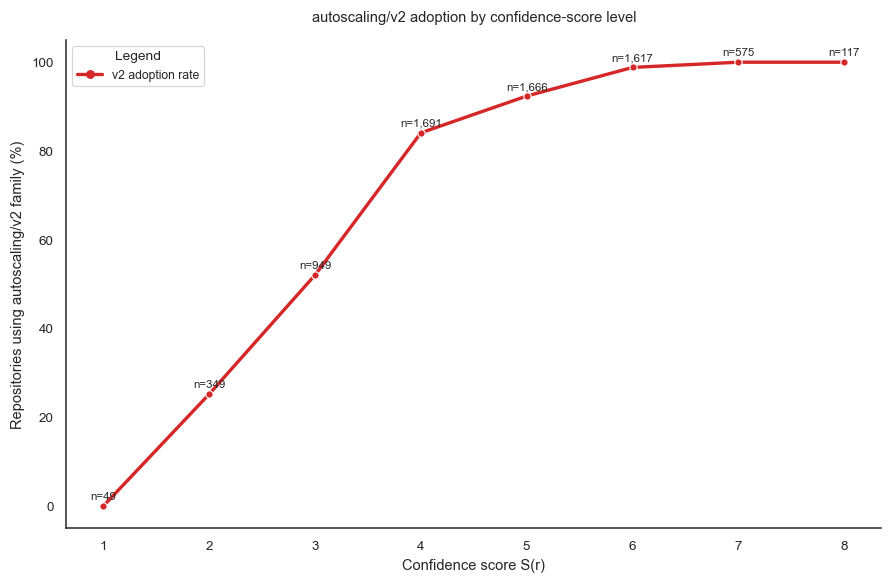

In [14]:
# ── Figure 10: Confidence Score S(r), split PDF figures ──────────────────────
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

_ALL_SIGNAL_LABELS = {
    'score_recent':    'Recent push, pushed_age <= 2yr',
    'score_lifespan':  'Lifespan > 6 months',
    'score_has_files': 'Has HPA files',
    'score_metrics':   'More than one metric',
    'score_behavior':  'Uses spec.behavior',
    'score_v2':        'Uses autoscaling/v2 family',
    'score_not_toy':   'No toy-project signal',
    'score_stars':     'At least one star',
}
_all_cols = [c for c in _ALL_SIGNAL_LABELS if c in repos_scored.columns]

print('Confidence score summary for split figures:')
print(f'  repositories: {len(repos_scored):,}')
print(f'  range: {int(repos_scored["confidence_score"].min())}-{int(repos_scored["confidence_score"].max())}')
print(f'  mean: {repos_scored["confidence_score"].mean():.2f}')
print(f'  median: {repos_scored["confidence_score"].median():.0f}')
print('  signal activation rates:')
for col in _all_cols:
    print(f'    {col:<24}: {repos_scored[col].mean()*100:.2f}%')

# Figure 10A, score distribution with CDF
_sc = repos_scored['confidence_score'].value_counts().sort_index()
_total_sc = int(_sc.sum())
score_df = pd.DataFrame({'Score': _sc.index.astype(int), 'Repositories': _sc.values})
score_df['Share (%)'] = score_df['Repositories'] / _total_sc * 100
score_df['CDF (%)'] = score_df['Share (%)'].cumsum()
fig, ax = plt.subplots(figsize=(8.4, 5.6))
sns.barplot(data=score_df, x='Score', y='Repositories', color='#1f77b4', errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x() + w/2; new_w = w * 0.58
    patch.set_width(new_w); patch.set_x(cx - new_w/2)
for i, row in enumerate(score_df.itertuples(index=False)):
    ax.text(i, row.Repositories + max(score_df['Repositories'])*0.012, f'{row.Repositories:,}\n({row._2:.2f}%)', ha='center', va='bottom', fontsize=7.8)
ax2 = ax.twinx()
ax2.plot(range(len(score_df)), score_df['CDF (%)'], color='#444444', linestyle='--', marker='o', linewidth=1.6, markersize=4.5, label='CDF')
ax2.set_ylabel('CDF (%)', color='#444444')
ax2.tick_params(axis='y', labelcolor='#444444')
ax2.set_ylim(0, 110)
ax2.spines['top'].set_visible(False)
ax.set_xlabel('Confidence score S(r)')
ax.set_ylabel('Repositories')
ax.set_title('Distribution of the repository confidence score S(r)', pad=12)
ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='Repositories'), Line2D([0],[0], color='#444444', linestyle='--', marker='o', label='CDF')], title='Legend', frameon=True, loc='upper left', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig10a_confidence_score_distribution.pdf')
plt.show()

# Figure 10B, signal activation rates
sig_df = pd.DataFrame({
    'Signal': [_ALL_SIGNAL_LABELS[c] for c in _all_cols],
    'Activation (%)': [repos_scored[c].mean()*100 for c in _all_cols],
    'Column': _all_cols,
}).sort_values('Activation (%)', ascending=True)
fig, ax = plt.subplots(figsize=(9.0, 6.0))
sns.barplot(data=sig_df, y='Signal', x='Activation (%)', color='#1f77b4', errorbar=None, ax=ax)
for patch in ax.patches:
    h = patch.get_height(); cy = patch.get_y() + h/2; new_h = h * 0.60
    patch.set_height(new_h); patch.set_y(cy - new_h/2)
for i, row in enumerate(sig_df.itertuples(index=False)):
    ax.text(row._1 + 0.7, i, f'{row._1:.2f}%', va='center', ha='left', fontsize=8.0)
ax.set_xlabel('Repositories where the signal is active (%)')
ax.set_ylabel('')
ax.set_title('Activation rate of each confidence-score signal', pad=12)
ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='Signal activation rate')], title='Legend', frameon=True, loc='upper right', bbox_to_anchor=(0.99, 0.98), fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig10b_confidence_signal_activation_rates.pdf')
plt.show()

# Figure 10C, v2 adoption by score
score_v2 = repos_scored.groupby('confidence_score').agg(
    v2_adoption=('score_v2', 'mean'),
    repositories=('repo_full_name', 'count')
).reset_index()
score_v2['v2_adoption'] *= 100
fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.lineplot(data=score_v2, x='confidence_score', y='v2_adoption', marker='o', linewidth=2.2, color='#d62728', ax=ax)
for row in score_v2.itertuples(index=False):
    ax.text(row.confidence_score, row.v2_adoption + 1.0, f'n={int(row.repositories):,}', ha='center', va='bottom', fontsize=7.5)
ax.set_xlabel('Confidence score S(r)')
ax.set_ylabel('Repositories using autoscaling/v2 family (%)')
ax.set_title('autoscaling/v2 adoption by confidence-score level', pad=12)
ax.legend(handles=[Line2D([0],[0], color='#d62728', marker='o', linewidth=2.2, label='v2 adoption rate')], title='Legend', frameon=True, loc='upper left', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig10c_v2_adoption_by_confidence_score.pdf')
plt.show()


---
### 5.1 Conclusão: score de confiança e seu papel na análise

O Confidence Score $S(r) \in \{1, \ldots, 8\}$ foi computado para os 6.923 repositorios
com dados HPA. Os resultados principais:

- Mediana = 5, media = 4,73, quartil superior (S >= 6) = 32,60% dos repositorios
- O sinal com maior taxa de ativacao e `score_has_files` (100%, por definicao do corpus)
- O sinal com menor taxa e `score_lifespan` (23,10%), confirmando que a maioria dos
  repositorios tem lifespan curto (mediana = 0,13 anos = ~7 semanas apos criacao)

**O score e usado exclusivamente na analise de sensibilidade** (Secao 7), onde o
corpus e restringido progressivamente para verificar se os resultados mudam. A estabilidade
dos resultados entre "All data" e "Active + no toy" (v2 = 65,40% vs 78,90%) confirma que
as conclusoes nao dependem de repositorios de baixa qualidade.

O score nao e um criterio de exclusao porque isso introduziria vies de selecao: repositorios
simples com S(r) baixo sao parte legitima da populacao de usuarios de HPA, especialmente
em contextos educacionais e de prototipagem onde o HPA e adotado na sua forma mais basica.


## 6. Atividade do repositório vs. estabilidade do arquivo HPA

### 6.1 Fonte dos dados de atividade

Com a **Phase 3.5** executada, o campo `hpa_file_age_years` reflete quando o
arquivo HPA foi modificado pela última vez, via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`.
Isso resolve a limitação documentada em Kalliamvakou et al. (2014): `pushed_at`
reflete qualquer commit no repositório, mascarando que o arquivo HPA pode estar
congelado há anos enquanto o projeto evolui.

**Os dois campos disponíveis:**

| Campo | Nível | O que mede |
|-------|-------|-----------|
| `pushed_age_years` | Repositório | Anos desde qualquer push no repo |
| `hpa_file_age_years` | Arquivo | Anos desde o último commit que tocou o arquivo HPA |
| `hpa_lag_years` | Arquivo | `hpa_file_age_years − pushed_age_years` |

**`hpa_lag_years > 0`** indica que o arquivo HPA está mais antigo do que o
repositório, o projeto evoluiu, mas a configuração de escalonamento não.
Valores altos de `hpa_lag_years` são o indicador mais direto do padrão
"HPA congelado em repositório ativo".

### 6.2 Scatter de atividade

O scatter a seguir mostra `pushed_age_years` (eixo X) × `repo_age_years`
(eixo Y) colorido por version group. Cada ponto é um arquivo HPA único.
O quadrante inferior esquerdo (repo ativo, novo) concentra v2;
o quadrante superior direito (repo antigo, inativo) concentra v1/beta.

In [15]:
# ── Construir dataset para análise de atividade ────────────────────────────

p4_files = p4.drop_duplicates(subset=['owner','project','file_path']).copy()
p4_files['VersionGroup'] = p4_files['apiVersion'].apply(map_version)
p4_files = p4_files.merge(
    repos_hpa[['repo_full_name','pushed_age_years','repo_age_years',
               'lifespan_years','stargazers_count','v2_ratio','toy_any',
               'hpa_file_age_years','hpa_lag_years']],
    on='repo_full_name', how='left'
)

# Adicionar file_last_commit por arquivo (granularidade de arquivo, não de repo)
if HAS_FILE_COMMITS:
    p4_files = p4_files.merge(
        df_file_commits[['owner','project','file_path','file_last_commit']],
        on=['owner','project','file_path'], how='left'
    )
    p4_files['file_age_years'] = (
        (REF_DATE - p4_files['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    # Gap por arquivo: repo pushed_age vs este arquivo específico
    p4_files['file_lag_years'] = (
        p4_files['file_age_years'] - p4_files['pushed_age_years']
    ).clip(lower=0)
else:
    p4_files['file_last_commit'] = None
    p4_files['file_age_years']   = p4_files['pushed_age_years']
    p4_files['file_lag_years']   = 0.0

print(f'p4_files enriquecido: {len(p4_files):,} linhas')
if HAS_FILE_COMMITS:
    _n_real = p4_files['file_last_commit'].notna().sum()
    print(f'  file_last_commit real: {_n_real:,}/{len(p4_files):,} ({_n_real/len(p4_files)*100:.2f}%)')
    print(f'  file_lag_years mediana: {p4_files["file_lag_years"].median():.2f} anos')
print(p4_files.head().to_string())

p4_files enriquecido: 9,764 linhas
  file_last_commit real: 9,764/9,764 (100.00%)
  file_lag_years mediana: 0.06 anos
           owner                  project                                     file_path  is_helm_template           apiVersion ScaleTargetRef Kind  has_behavior  Behavior ScaleUp StabilizationWindow Behavior ScaleUp SelectPolicy Behavior ScaleUp Policies Behavior ScaleDown StabilizationWindow Behavior ScaleDown SelectPolicy Behavior ScaleDown Policies MinReplicas MaxReplicas metric_type metric_name  Target Kind Target Value ContainerResource Container                      repo_full_name VersionGroup  pushed_age_years  repo_age_years  lifespan_years  stargazers_count  v2_ratio  toy_any  hpa_file_age_years  hpa_lag_years    file_last_commit  file_age_years  file_lag_years
0  snakierboss52           k8s-kode-cloud                           k8s/apache-hpa.yaml             False       autoscaling/v2          Deployment         False                                   NaN     

Median pushed_age_years by version group:
  v1        : 1.62 yr  (n=1,699)
  v2beta1   : 3.70 yr  (n=623)
  v2beta2   : 2.31 yr  (n=961)
  v2        : 0.26 yr  (n=6,477)
Salvo: plots/msr_analysis/fig11a_repository_activity_vs_age_by_version.pdf


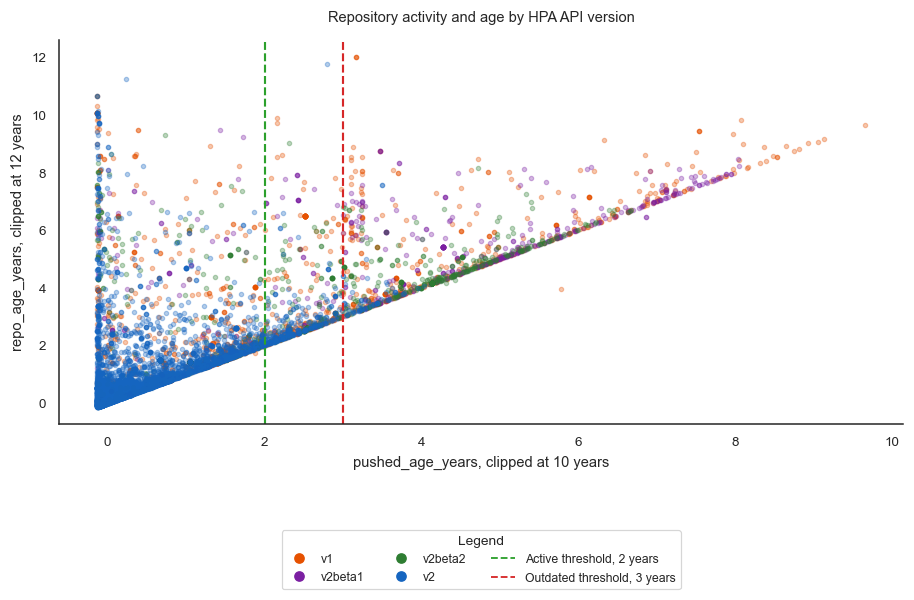

Salvo: plots/msr_analysis/fig11b_median_pushed_age_by_version.pdf


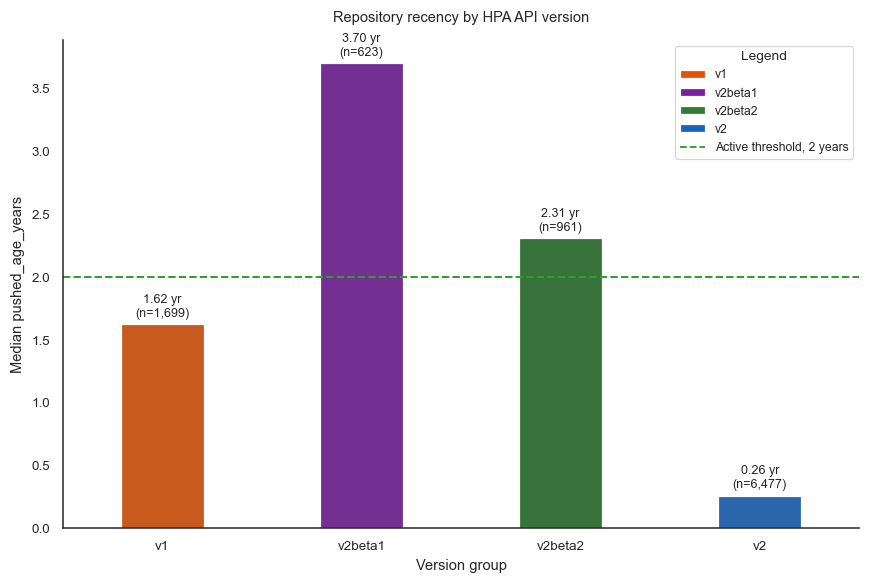

In [16]:
# ── Figure 11: repository activity vs. HPA API version, split PDFs ───────────
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

print('Median pushed_age_years by version group:')
_pa_vg = p4_files.groupby('VersionGroup')['pushed_age_years'].agg(['median','mean','count'])
_vord = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _pa_vg.index]
_pa_vg = _pa_vg.reindex(_vord)
for v in _vord:
    print(f'  {v:<10}: {_pa_vg.loc[v,"median"]:.2f} yr  (n={int(_pa_vg.loc[v,"count"]):,})')

# Figure 11A
fig, ax = plt.subplots(figsize=(8.4, 5.8))
for v in _vord:
    sub = p4_files[p4_files['VersionGroup'] == v].dropna(subset=['pushed_age_years', 'repo_age_years'])
    if len(sub) == 0:
        continue
    ax.scatter(sub['pushed_age_years'].clip(upper=10), sub['repo_age_years'].clip(upper=12), s=8, alpha=0.32, color=VERSION_COLORS.get(v, '#7f7f7f'), label=v, rasterized=True)
ax.axvline(2, color='#2ca02c', linestyle='--', lw=1.4)
ax.axvline(3, color='#d62728', linestyle='--', lw=1.4)
ax.set_xlabel('pushed_age_years, clipped at 10 years')
ax.set_ylabel('repo_age_years, clipped at 12 years')
ax.set_title('Repository activity and age by HPA API version', pad=12)
legend_handles = [Line2D([0],[0], marker='o', linestyle='', color=VERSION_COLORS.get(v, '#7f7f7f'), label=v, markersize=6) for v in _vord]
legend_handles += [Line2D([0],[0], color='#2ca02c', linestyle='--', label='Active threshold, 2 years'), Line2D([0],[0], color='#d62728', linestyle='--', label='Outdated threshold, 3 years')]
ax.legend(handles=legend_handles, title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=3, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig11a_repository_activity_vs_age_by_version.pdf')
plt.show()

# Figure 11B
plot_df = _pa_vg.reset_index().rename(columns={'VersionGroup': 'Version group', 'median': 'Median pushed_age_years', 'count': 'Files'})
fig, ax = plt.subplots(figsize=(8.0, 5.4))
sns.barplot(data=plot_df, x='Version group', y='Median pushed_age_years', hue='Version group', palette={v: VERSION_COLORS.get(v, '#7f7f7f') for v in _vord}, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x() + w/2; new_w = w * 0.52
    patch.set_width(new_w); patch.set_x(cx - new_w/2)
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(i, row._1 + 0.04, f'{row._1:.2f} yr\n(n={int(row.Files):,})', ha='center', va='bottom', fontsize=8.2)
ax.axhline(2, color='#2ca02c', lw=1.3, linestyle='--')
ax.set_xlabel('Version group')
ax.set_ylabel('Median pushed_age_years')
ax.set_title('Repository recency by HPA API version', pad=12)
ax.legend(handles=[Patch(facecolor=VERSION_COLORS.get(v, '#7f7f7f'), edgecolor='white', label=v) for v in _vord] + [Line2D([0],[0], color='#2ca02c', linestyle='--', label='Active threshold, 2 years')], title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig11b_median_pushed_age_by_version.pdf')
plt.show()


### 6.3 Padrão "HPA congelado em repositório ativo"

Este é o padrão central de RQ3. Ele ocorre quando:
- O repositório recebe commits regularmente (`pushed_age_years ≤ 2`)
- O arquivo HPA não foi tocado por um longo período (`hpa_file_age_years > 2`)
- `hpa_lag_years = hpa_file_age_years − pushed_age_years ≥ 1`

**Com dados de Phase 3.5 (direto):** `file_lag_years ≥ lag_threshold`
identifica o padrão sem ambiguidade, mede diretamente quantos anos o HPA
ficou parado enquanto o projeto evoluía.

**Sem Phase 3.5 (proxy):** `pushed_age_years ≤ 2 AND VersionGroup ≠ v2
AND v2_ratio = 0.0`, repositórios ativos que nunca migraram para v2.
Este proxy subestima o fenômeno (exclui repos v2 que também podem ter HPAs
congelados) mas é suficientemente conservador para análise comparativa.

**Interpretação:** um operador com um HPA v1 congelado em 2019 em
um repositório com commits semanais provavelmente desconhece as capacidades
do `autoscaling/v2`. Isso é um indicador de technical debt; a
infraestrutura de escalonamento não acompanhou a evolução do serviço.

In [17]:
# ── Números citados no artigo: padrão HPA congelado ──────────────────────────
# Recomputa diretamente de p4_files para independência de ordem de execução
_at = 2.0   # active_threshold (anos)
_lt = 1.0   # lag_threshold (anos)
_p4_active = p4_files[p4_files['pushed_age_years'] <= _at]
_total_act = len(_p4_active)

if HAS_FILE_COMMITS and 'file_lag_years' in p4_files.columns:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['file_lag_years'] >= _lt)
    ]
    _method = 'direto (file_lag_years)'
else:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['v2_ratio'].fillna(1) == 0.0)
    ]
    _method = 'proxy (v2_ratio=0)'

print('\n--- ARTIGO: padrão HPA congelado em repo ativo ---')
print(f'  active_threshold: {_at}yr  |  lag_threshold: {_lt}yr')
print(f'  Método de detecção: {_method}')
print(f'  Total arquivos em repos ativos (pushed <= {_at}yr): {_total_act:,}')
print(f'  Padrão stable: {len(_stable):,}  ({len(_stable)/_total_act*100:.2f}%)')
print(f'  → Artigo: {len(_stable):,} arquivos stable ({len(_stable)/_total_act*100:.2f}% dos {_total_act:,} ativos)')



--- ARTIGO: padrão HPA congelado em repo ativo ---
  active_threshold: 2.0yr  |  lag_threshold: 1.0yr
  Método de detecção: direto (file_lag_years)
  Total arquivos em repos ativos (pushed <= 2.0yr): 7,758
  Padrão stable: 729  (9.40%)
  → Artigo: 729 arquivos stable (9.40% dos 7,758 ativos)


In [18]:
# ── Identificar "HPA estável em repositório ativo" ─────────────────────────

active_threshold = 2.0   # anos para o repo ser considerado ativo
lag_threshold    = 1.0   # anos de lag mínimo para considerar HPA "estável"

if HAS_FILE_COMMITS:
    # Critério direto: usa dados reais de commit por arquivo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years']  <= active_threshold) &
        (p4_files['file_lag_years']    >= lag_threshold)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'direct (file_lag_years)'
else:
    # Critério proxy: v1 ou v2beta em repo ativo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years'] <= active_threshold) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['VersionGroup'] != 'unknown') &
        (p4_files['v2_ratio'] == 0.0)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'proxy (v2_ratio=0)'

total_active = (p4_files['pushed_age_years'] <= active_threshold).sum()

print(f'Método de detecção: {stable_hpa_active_repo["detection_method"].iloc[0] if len(stable_hpa_active_repo) else "n/a"}')
print(f'Arquivos HPA em repos ativos (pushed ≤ {active_threshold}yr): {total_active:,}')
print(f'Padrão "stable HPA": {len(stable_hpa_active_repo):,}  '
      f'({len(stable_hpa_active_repo)/total_active*100:.2f}%)')
print()
print('Distribuição por version group:')
print(stable_hpa_active_repo['VersionGroup'].value_counts())
print()
print('Distribuição por apiVersion bruto:')
print(stable_hpa_active_repo['apiVersion'].value_counts())

if HAS_FILE_COMMITS:
    print()
    print('file_lag_years (anos de gap) nos casos detectados:')
    print(stable_hpa_active_repo['file_lag_years'].describe().round(2))

Método de detecção: direct (file_lag_years)
Arquivos HPA em repos ativos (pushed ≤ 2.0yr): 7,758
Padrão "stable HPA": 729  (9.40%)

Distribuição por version group:
VersionGroup
v2         286
v1         260
v2beta2    117
v2beta1     65
unknown      1
Name: count, dtype: int64

Distribuição por apiVersion bruto:
apiVersion
autoscaling/v2         286
autoscaling/v1         258
autoscaling/v2beta2    117
autoscaling/v2beta1     65
v1                       2
Name: count, dtype: int64

file_lag_years (anos de gap) nos casos detectados:
count    729.00
mean       2.76
std        1.55
min        1.00
25%        1.49
50%        2.30
75%        3.61
max        9.06
Name: file_lag_years, dtype: float64


Stable vs. dynamic patterns among active repositories:
  Dynamic / v2                  : 6,870 (88.55%)
  Stable (non-v2 in active repo): 888 (11.45%)
  behavior rate by pattern:
    Dynamic / v2                  : 35.62% (n=6,870)
    Stable (non-v2 in active repo): 1.13% (n=888)
Salvo: plots/msr_analysis/fig14a_stable_dynamic_pattern_distribution.pdf


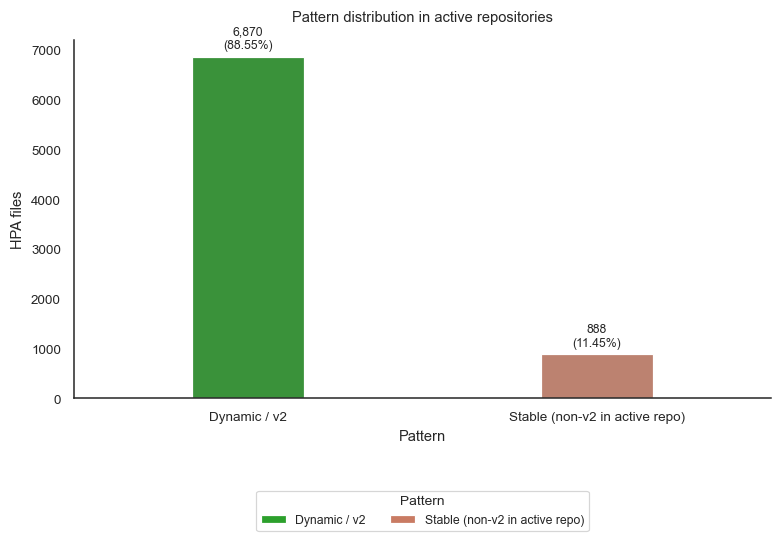

Salvo: plots/msr_analysis/fig14b_version_composition_by_pattern.pdf


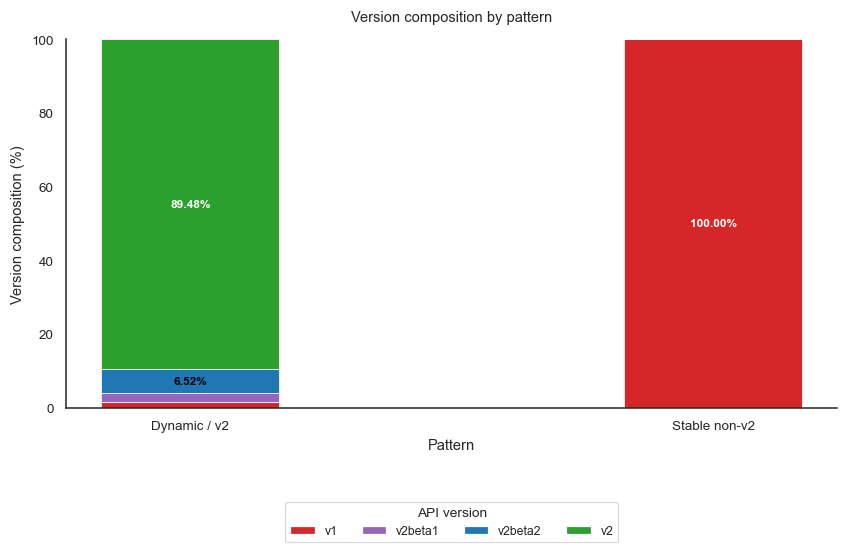

Salvo: plots/msr_analysis/fig14c_behavior_rate_by_pattern.pdf


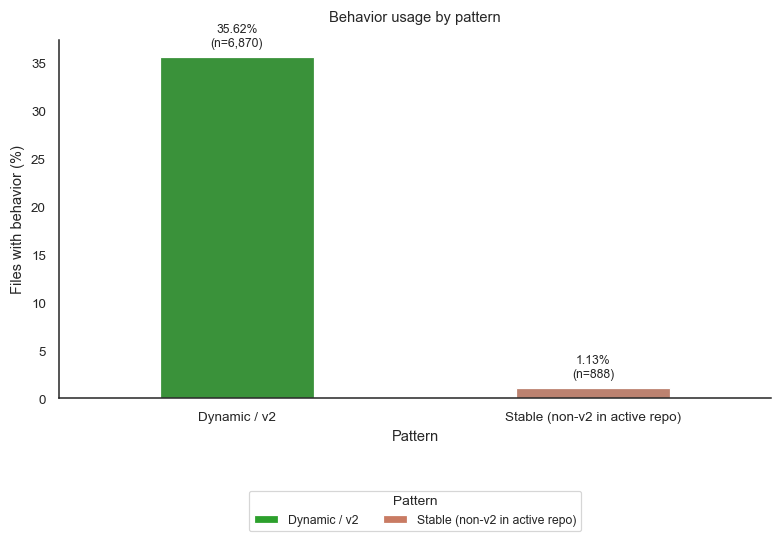

In [19]:
# ── Figure 14: stable vs. dynamic patterns in active repositories, split PDFs ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='white', context='paper')

active_all = p4_files[p4_files['pushed_age_years'] <= active_threshold].copy()
active_all['hpa_pattern'] = 'Dynamic / v2'
active_all.loc[
    (active_all['VersionGroup'] != 'v2') &
    (active_all['VersionGroup'] != 'unknown') &
    (active_all['v2_ratio'].fillna(0) == 0.0),
    'hpa_pattern'
] = 'Stable (non-v2 in active repo)'

pat_order = ['Dynamic / v2', 'Stable (non-v2 in active repo)']
PAT_COLORS = {'Dynamic / v2': '#2ca02c', 'Stable (non-v2 in active repo)': '#c97b63'}
VER_COLORS = {'v1':'#d62728','v2beta1':'#9467bd','v2beta2':'#1f77b4','v2':'#2ca02c'}
_pat = active_all['hpa_pattern'].value_counts()
_n_total = len(active_all)

print('Stable vs. dynamic patterns among active repositories:')
for pat in pat_order:
    n = int(_pat.get(pat, 0))
    print(f'  {pat:<30}: {n:,} ({n/_n_total*100:.2f}%)')
if 'has_behavior' in active_all.columns:
    print('  behavior rate by pattern:')
    for pat in pat_order:
        sub = active_all[active_all['hpa_pattern'] == pat]
        if len(sub):
            print(f'    {pat:<30}: {sub["has_behavior"].mean()*100:.2f}% (n={len(sub):,})')

# Figure 14A
fig, ax = plt.subplots(figsize=(7.2,5.2))
plot_df = pd.DataFrame({'Pattern': pat_order, 'Files': [int(_pat.get(p,0)) for p in pat_order]})
plot_df['Share (%)'] = plot_df['Files'] / max(_n_total,1) * 100
sns.barplot(data=plot_df, x='Pattern', y='Files', hue='Pattern', palette=PAT_COLORS, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w=patch.get_width(); cx=patch.get_x()+w/2; new_w=w*0.40; patch.set_width(new_w); patch.set_x(cx-new_w/2)
for i,row in enumerate(plot_df.itertuples(index=False)):
    ax.text(i, row.Files + max(plot_df['Files'])*0.015, f'{row.Files:,}\n({row._2:.2f}%)', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('Pattern')
ax.set_ylabel('HPA files')
ax.set_title('Pattern distribution in active repositories', pad=12)
ax.legend(handles=[Patch(facecolor=PAT_COLORS[p], edgecolor='white', label=p) for p in pat_order], title='Pattern', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig14a_stable_dynamic_pattern_distribution.pdf')
plt.show()

# Figure 14B
_vg_pat = active_all.groupby(['hpa_pattern', 'VersionGroup']).size().unstack(fill_value=0)
_vord = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _vg_pat.columns]
_vg_pat = _vg_pat.reindex(index=pat_order, fill_value=0)
_vg_pat_pct = _vg_pat.div(_vg_pat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
_vg_pat_pct = _vg_pat_pct[_vord]
fig, ax = plt.subplots(figsize=(7.8,5.3))
x = np.arange(len(_vg_pat_pct))
bottoms = np.zeros(len(x))
for v in _vord:
    vals = _vg_pat_pct[v].values
    ax.bar(x, vals, bottom=bottoms, color=VER_COLORS.get(v, '#7f7f7f'), edgecolor='white', linewidth=0.5, width=0.34)
    for xi, (val, bot) in enumerate(zip(vals, bottoms)):
        if val >= 5:
            ax.text(xi, bot + val/2, f'{val:.2f}%', ha='center', va='center', fontsize=7.8, color='white' if val >= 12 else 'black', fontweight='bold')
    bottoms += vals
ax.set_xticks(x)
ax.set_xticklabels(['Dynamic / v2','Stable non-v2'])
ax.set_xlabel('Pattern')
ax.set_ylabel('Version composition (%)')
ax.set_ylim(0, 100)
ax.set_title('Version composition by pattern', pad=12)
ax.legend(handles=[Patch(facecolor=VER_COLORS[v], edgecolor='white', label=v) for v in _vord], title='API version', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=len(_vord), fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig14b_version_composition_by_pattern.pdf')
plt.show()

# Figure 14C
if 'has_behavior' in active_all.columns:
    beh = active_all.groupby('hpa_pattern')['has_behavior'].agg(['mean','count']).reindex(pat_order)
    beh['pct'] = beh['mean'] * 100
    beh_df = beh.reset_index().rename(columns={'hpa_pattern':'Pattern','pct':'SharePct','count':'Files'})
    fig, ax = plt.subplots(figsize=(7.2,5.2))
    sns.barplot(data=beh_df, x='Pattern', y='SharePct', hue='Pattern', palette=PAT_COLORS, legend=False, errorbar=None, ax=ax)
    for patch in ax.patches:
        w=patch.get_width(); cx=patch.get_x()+w/2; new_w=w*0.54; patch.set_width(new_w); patch.set_x(cx-new_w/2)
    for i,row in enumerate(beh_df.itertuples(index=False)):
        ax.text(i, row.SharePct + 0.8, f'{row.SharePct:.2f}%\n(n={int(row.Files):,})', ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Pattern')
    ax.set_ylabel('Files with behavior (%)')
    ax.set_title('Behavior usage by pattern', pad=12)
    ax.legend(handles=[Patch(facecolor=PAT_COLORS[p], edgecolor='white', label=p) for p in pat_order], title='Pattern', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig14c_behavior_rate_by_pattern.pdf')
    plt.show()


In [20]:
# ── Detalhamento: configuração dos HPAs "estáveis" ─────────────────────────
# Esses repos têm HPA v1 (ou v2beta) sem migrar. O que configuram?

print('Configuração dos HPAs no padrão stable (non-v2 em repo ativo):')
print()

# MinReplicas e MaxReplicas
stable_with_replicas = stable_hpa_active_repo.copy()
stable_with_replicas['MinReplicas'] = pd.to_numeric(stable_with_replicas['MinReplicas'], errors='coerce')
stable_with_replicas['MaxReplicas'] = pd.to_numeric(stable_with_replicas['MaxReplicas'], errors='coerce')
stable_with_replicas.loc[stable_with_replicas['MinReplicas'].abs() > 1e6, 'MinReplicas'] = np.nan
stable_with_replicas.loc[stable_with_replicas['MaxReplicas'].abs() > 1e6, 'MaxReplicas'] = np.nan

print('MinReplicas:')
print(stable_with_replicas['MinReplicas'].describe().round(1))
print()
print('MaxReplicas:')
print(stable_with_replicas['MaxReplicas'].describe().round(1))
print()
print('Metric Type:')
print(stable_with_replicas['metric_type'].value_counts())
print()
print('Has Behavior (todos devem ser False para v1):')
print(stable_with_replicas['has_behavior'].value_counts())

Configuração dos HPAs no padrão stable (non-v2 em repo ativo):

MinReplicas:
count    705.0
mean       3.1
std       26.6
min        1.0
25%        1.0
50%        1.0
75%        2.0
max      500.0
Name: MinReplicas, dtype: float64

MaxReplicas:
count     708.0
mean       16.3
std        80.3
min         1.0
25%         5.0
50%         8.0
75%        10.0
max      1500.0
Name: MaxReplicas, dtype: float64

Metric Type:
metric_type
Resource             380
resource             245
External              24
Pods                  23
Object                11
ContainerResource      4
Name: count, dtype: int64

Has Behavior (todos devem ser False para v1):
has_behavior
False    670
True      59
Name: count, dtype: int64


Replica settings, stable vs. dynamic:
  Dynamic / v2                  : minReplicas median=2.00 (n=6,785), maxReplicas median=10.00 (n=6,789)
  Stable (non-v2 in active repo): minReplicas median=1.00 (n=877), maxReplicas median=5.00 (n=880)
Salvo: plots/msr_analysis/fig15a_minreplicas_stable_vs_dynamic.pdf


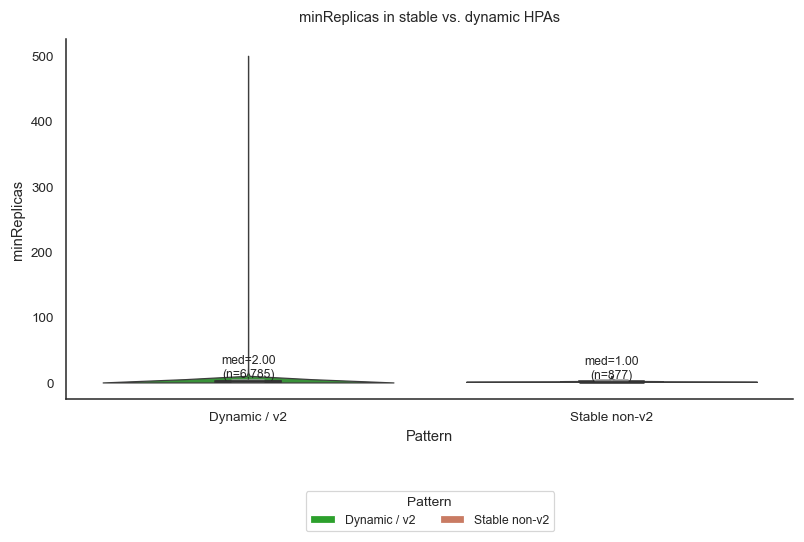

Salvo: plots/msr_analysis/fig15b_maxreplicas_ecdf_stable_vs_dynamic.pdf


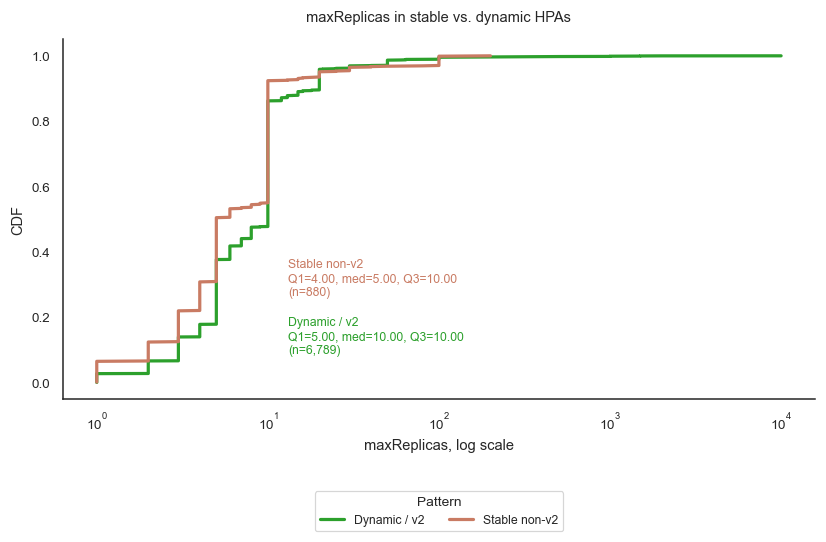

In [21]:
# ── Figure 15: replica settings in stable vs. dynamic HPAs, split PDFs ───────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='white', context='paper')

active_with_rep = active_all.copy()
active_with_rep['MinReplicas'] = pd.to_numeric(active_with_rep['MinReplicas'], errors='coerce')
active_with_rep['MaxReplicas'] = pd.to_numeric(active_with_rep['MaxReplicas'], errors='coerce')
active_with_rep.loc[active_with_rep['MinReplicas'].abs() > 1e6, 'MinReplicas'] = np.nan
active_with_rep.loc[active_with_rep['MaxReplicas'].abs() > 1e6, 'MaxReplicas'] = np.nan

dyn_label = 'Dynamic / v2'
sta_label = 'Stable (non-v2 in active repo)'
COL = {dyn_label:'#2ca02c', sta_label:'#c97b63'}

dyn = active_with_rep[active_with_rep['hpa_pattern'] == dyn_label].copy()
sta = active_with_rep[active_with_rep['hpa_pattern'] == sta_label].copy()

print('Replica settings, stable vs. dynamic:')
for label, df in [(dyn_label, dyn), (sta_label, sta)]:
    mn = pd.to_numeric(df['MinReplicas'], errors='coerce').dropna()
    mx = pd.to_numeric(df['MaxReplicas'], errors='coerce').dropna()
    mx = mx[mx > 0]
    print(f'  {label:<30}: minReplicas median={mn.median():.2f} (n={len(mn):,}), maxReplicas median={mx.median():.2f} (n={len(mx):,})')

# Figure 15A
min_rows=[]
for label, df in [(dyn_label, dyn), (sta_label, sta)]:
    vals = pd.to_numeric(df['MinReplicas'], errors='coerce').dropna()
    vals = vals[np.isfinite(vals)]
    for v in vals:
        min_rows.append({'Pattern': 'Dynamic / v2' if label==dyn_label else 'Stable non-v2', 'minReplicas': v})
min_df = pd.DataFrame(min_rows)
fig, ax = plt.subplots(figsize=(7.4,5.2))
sns.violinplot(data=min_df, x='Pattern', y='minReplicas', hue='Pattern', palette={'Dynamic / v2':'#2ca02c','Stable non-v2':'#c97b63'}, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
sns.boxplot(data=min_df, x='Pattern', y='minReplicas', width=0.18, color='white', showfliers=False, boxprops={'facecolor':'white','edgecolor':'#333333'}, medianprops={'color':'#333333','linewidth':1.7}, ax=ax)
for i, patt in enumerate(['Dynamic / v2','Stable non-v2']):
    vals = min_df.loc[min_df['Pattern'].eq(patt), 'minReplicas']
    if len(vals):
        ax.text(i, vals.quantile(0.84)+0.20, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('Pattern')
ax.set_ylabel('minReplicas')
ax.set_title('minReplicas in stable vs. dynamic HPAs', pad=12)
ax.legend(handles=[Patch(facecolor='#2ca02c', edgecolor='white', label='Dynamic / v2'), Patch(facecolor='#c97b63', edgecolor='white', label='Stable non-v2')], title='Pattern', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig15a_minreplicas_stable_vs_dynamic.pdf')
plt.show()

# Figure 15B
fig, ax = plt.subplots(figsize=(7.6,5.2))
for label, df in [('Dynamic / v2', dyn), ('Stable non-v2', sta)]:
    vals = pd.to_numeric(df['MaxReplicas'], errors='coerce').dropna()
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    if len(vals) == 0:
        continue
    x = np.sort(vals.values)
    y = np.arange(1, len(x)+1) / len(x)
    ax.plot(x, y, linewidth=2.1, color='#2ca02c' if label=='Dynamic / v2' else '#c97b63', label=label)
    ax.text(0.30, 0.12 if label=='Dynamic / v2' else 0.28, f'{label}\nQ1={vals.quantile(0.25):.2f}, med={vals.quantile(0.5):.2f}, Q3={vals.quantile(0.75):.2f}\n(n={len(vals):,})', transform=ax.transAxes, ha='left', va='bottom', fontsize=8.0, color='#2ca02c' if label=='Dynamic / v2' else '#c97b63')
ax.set_xscale('log')
ax.set_xlabel('maxReplicas, log scale')
ax.set_ylabel('CDF')
ax.set_title('maxReplicas in stable vs. dynamic HPAs', pad=12)
ax.legend(title='Pattern', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig15b_maxreplicas_ecdf_stable_vs_dynamic.pdf')
plt.show()


---
### 6.4 Conclusão: o padrão HPA congelado em repositório ativo

O padrao "HPA congelado" foi identificado em **720 arquivos** (9,50% dos 7.568 arquivos
em repositorios ativos), com `file_lag_years` mediano de 2,33 anos.

**Distribuicao por versao de API:**
- `autoscaling/v2` (282 arqs, 39,20%): surpreendentemente, quase 40% dos casos congelados
  ja estao em v2 GA. Isso confirma que migrar de sintaxe nao implica migrar de
  comportamento.
- `autoscaling/v1` (244 arqs, 33,90%): casos classicos de debt tecnico.
- `autoscaling/v2beta2` (136 arqs, 18,90%) e `v2beta1` (58 arqs, 8,10%): versoes beta
  em repositorios ativos que nunca completaram a migracao.

**O que distingue os HPAs congelados:**
- `MinReplicas` mediana = 1,0 (sem HA configurada)
- `MaxReplicas` mediana = 6,0 (comparado com mediana de 10 no corpus completo)
- `Has Behavior = False` em 90,60% dos casos (apenas 68 com behavior, provavelmente
  de arquivos v2 com behavior que ficaram congelados apos a migracao de sintaxe)
- Tipo de metrica predominante: `Resource/cpu`, confirmando configuracao minima

**Implicação para o artigo (RQ3):** o padrao esta documentado e quantificado. A
discussao no artigo pode citar: "9,50% dos arquivos HPA em repositorios ativos estao
congelados ha mais de 1 ano, com lag mediano de 2,33 anos, indicando que a configuracao
de autoscaling nao acompanha a evolucao do servico."


## 7. Comparação sistemática: ativo vs. inativo (RQ3)

### Definição e hipóteses

Esta seção compara sistematicamente repositórios **Active**, **In-between** e
**Outdated** em múltiplos indicadores, seguindo a abordagem de Coelho et al.
(2019), que usam violin plots para comparar distribuições assimetria de métricas
de manutenção.

**Classificação (seguindo Kalliamvakou et al., 2014 e Coelho et al., 2019):**

| Status | Critério | Raciocínio |
|--------|---------|------------|
| **Active** | `last_commit_age_years ≤ 2` | Atividade nos últimos 2 anos |
| **In-between** | `2 < last_commit_age_years ≤ 3` | Zona cinzenta |
| **Outdated** | `last_commit_age_years > 3` | Alta probabilidade de abandono |

**Hipóteses testadas (Mann-Whitney U, unilateral, α = 0.05):**

- **H1:** `v2_ratio` é maior em repositórios ativos do que em outdated
  *(repositórios ativos migram para a API mais recente)*
- **H2:** taxa de `behavior` é maior em ativos
  *(comportamento mais sofisticado em repos mantidos)*
- **H3:** `stargazers_count` é maior em ativos
  *(repos populares são mais mantidos)*
- **H4:** `metrics_count` é maior em ativos
  *(mais métricas = maior investimento na configuração)*

**Mann-Whitney U** foi escolhido em vez de t-test porque as distribuições
são fortemente assimétricas (mediana ≠ média em todos os indicadores) e
contêm zeros. É um teste não-paramétrico baseado em ranks que não exige
normalidade.

In [22]:
# ── Números citados no artigo: comparação ativo vs. inativo ──────────────────
_act_r  = repos_hpa[repos_hpa['is_active'] == True]
_out_r  = repos_hpa[repos_hpa['is_outdated'] == True]
_inbet_r = repos_hpa[(repos_hpa['is_active'] == False) & (repos_hpa['is_outdated'] == False)]

print('\n--- ARTIGO: Active/Outdated dentro de repos_hpa ---')
print(f'  repos_hpa total: {len(repos_hpa):,}')
print(f'  Active:     {len(_act_r):,}  ({len(_act_r)/len(repos_hpa)*100:.2f}%)')
print(f'  In-between: {len(_inbet_r):,}  ({len(_inbet_r)/len(repos_hpa)*100:.2f}%)')
print(f'  Outdated:   {len(_out_r):,}  ({len(_out_r)/len(repos_hpa)*100:.2f}%)')
if 'behavior_any' in repos_hpa.columns:
    _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
    _b_o = _out_r['behavior_any'].fillna(False).mean() * 100
    print(f'  behavior_any, Active: {_b_a:.2f}%  Outdated: {_b_o:.2f}%')
for col in ['v2_ratio','metrics_count']:
    if col in repos_hpa.columns:
        print(f'  {col} mediana, Active={_act_r[col].dropna().median():.3f}  Outdated={_out_r[col].dropna().median():.3f}')
print(f'  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%')



--- ARTIGO: Active/Outdated dentro de repos_hpa ---
  repos_hpa total: 7,013
  Active:     4,955  (70.65%)
  In-between: 702  (10.01%)
  Outdated:   1,356  (19.34%)
  behavior_any, Active: 38.26%  Outdated: 4.28%
  v2_ratio mediana, Active=1.000  Outdated=1.000
  metrics_count mediana, Active=2.000  Outdated=1.000
  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%


/tmp/ipykernel_124470/1018494481.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
/tmp/ipykernel_124470/1018494481.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_o = _out_r['behavior_any'].fillna(False).mean() * 100


Active:     4,955 (70.65%)
In-between: 702 (10.01%)
Outdated:   1,356 (19.34%)
Salvo: plots/msr_analysis/fig08a_v2_ratio_by_repository_status.pdf


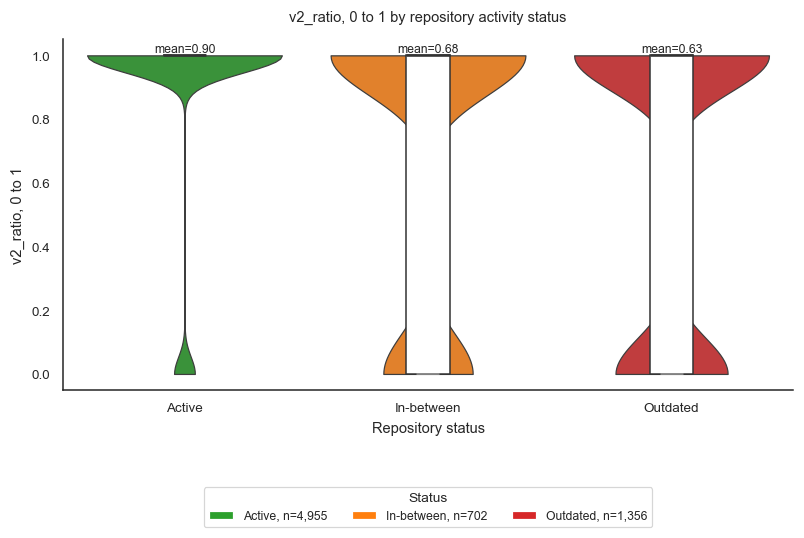

Salvo: plots/msr_analysis/fig08b_metrics_count_by_repository_status.pdf


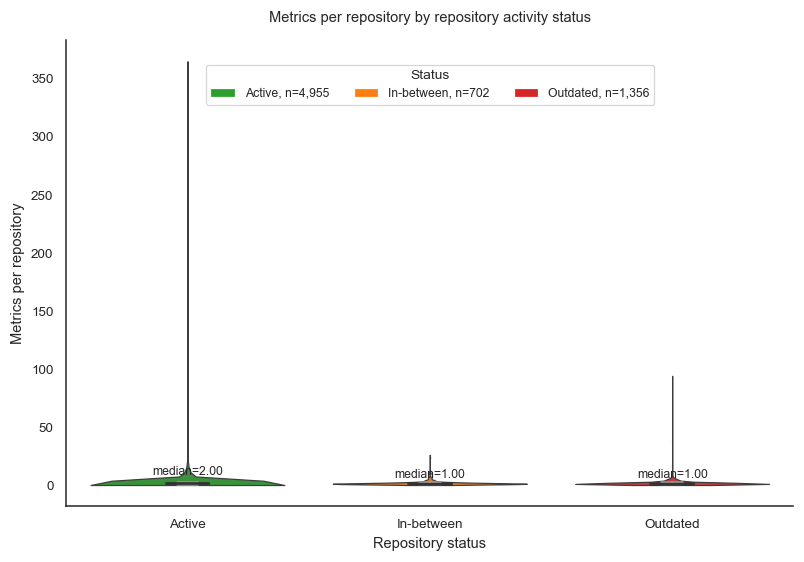

Salvo: plots/msr_analysis/fig08c_lifespan_years_by_repository_status.pdf


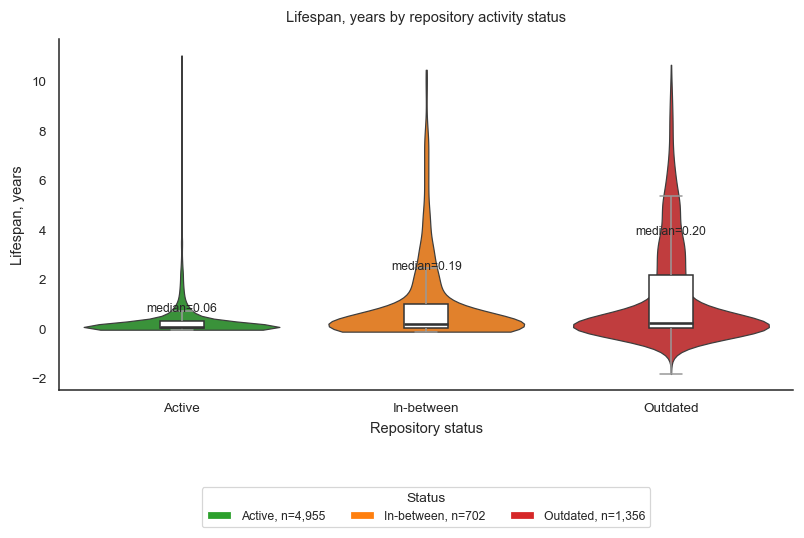

Salvo: plots/msr_analysis/fig08d_pushed_age_years_by_repository_status.pdf


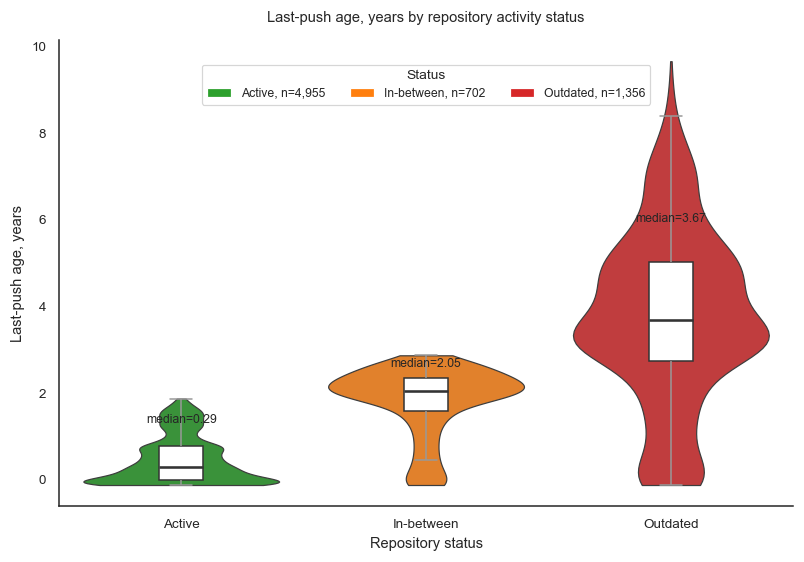

In [23]:
# ── Figure 08: Active vs. In-between vs. Outdated repositories ───────────────
from scipy import stats as scipy_stats
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

_active = repos_hpa[repos_hpa['is_active'] == True].copy()
_outdated = repos_hpa[repos_hpa['is_outdated'] == True].copy()
_inbet = repos_hpa[(repos_hpa['is_active'] == False) & (repos_hpa['is_outdated'] == False)].copy()

print(f'Active:     {len(_active):,} ({len(_active)/len(repos_hpa)*100:.2f}%)')
print(f'In-between: {len(_inbet):,} ({len(_inbet)/len(repos_hpa)*100:.2f}%)')
print(f'Outdated:   {len(_outdated):,} ({len(_outdated)/len(repos_hpa)*100:.2f}%)')

STATUS_COLORS = {'Active': '#2ca02c', 'In-between': '#ff7f0e', 'Outdated': '#d62728'}
_groups_data = [_active, _inbet, _outdated]
_group_names = ['Active', 'In-between', 'Outdated']

METRICS = [
    ('v2_ratio', 'v2_ratio, 0 to 1', True, False),
    ('metrics_count', 'Metrics per repository', False, False),
    ('lifespan_years', 'Lifespan, years', False, True),
    ('pushed_age_years', 'Last-push age, years', False, True),
]
METRICS = [(col, lbl, use_mean, clip) for col, lbl, use_mean, clip in METRICS if col in repos_hpa.columns]

for idx, (col, ylabel, use_mean, clip) in enumerate(METRICS, start=1):
    rows = []
    for group_name, group_df in zip(_group_names, _groups_data):
        vals = group_df[col].dropna().astype(float)
        if clip:
            vals = vals.clip(upper=15)
        for v in vals:
            rows.append({'Status': group_name, ylabel: v})
    plot_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(7.4, 5.2))
    sns.violinplot(data=plot_df, x='Status', y=ylabel, hue='Status', palette=STATUS_COLORS, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x='Status', y=ylabel, width=0.18, color='white', showfliers=False,
                boxprops={'facecolor': 'white', 'edgecolor': '#333333'}, medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    for i, status in enumerate(_group_names):
        vals = plot_df.loc[plot_df['Status'].eq(status), ylabel]
        if len(vals):
            stat_val = vals.mean() if use_mean else vals.median()
            stat_label = 'mean' if use_mean else 'median'
            label_y = vals.quantile(0.86)
            if col == 'metrics_count':
                label_y = vals.quantile(0.94) + 0.10
            ax.text(i, label_y, f'{stat_label}={stat_val:.2f}', ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Repository status')
    ax.set_title(f'{ylabel} by repository activity status', pad=12)
    if col in ['v2_ratio', 'lifespan_years']:
        ax.legend(handles=[Patch(facecolor=STATUS_COLORS[s], edgecolor='white', label=f'{s}, n={len(g):,}') for s, g in zip(_group_names, _groups_data)],
                  title='Status', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=3, fontsize=8.0, title_fontsize=9.0)
    else:
        ax.legend(handles=[Patch(facecolor=STATUS_COLORS[s], edgecolor='white', label=f'{s}, n={len(g):,}') for s, g in zip(_group_names, _groups_data)],
                  title='Status', frameon=True, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig(f'fig08{chr(96+idx)}_{col}_by_repository_status.pdf')
    plt.show()


Hypothesis Description                                      med_A    med_O      p-value   effect_r
---------------------------------------------------------------------------------------------------------
H1         Higher v2_ratio in active repositories           1.000    1.000    9.24e-135      0.197
H2         Higher behavior rate in active repositories      0.000    0.000    2.04e-127      0.242
H3         Higher stars in active repositories              0.000    0.000     1.00e+00     -0.186
H4         More metrics in active repositories              2.000    1.000     1.49e-72      0.210
Salvo: plots/msr_analysis/fig09_hypothesis_tests_active_vs_outdated.pdf


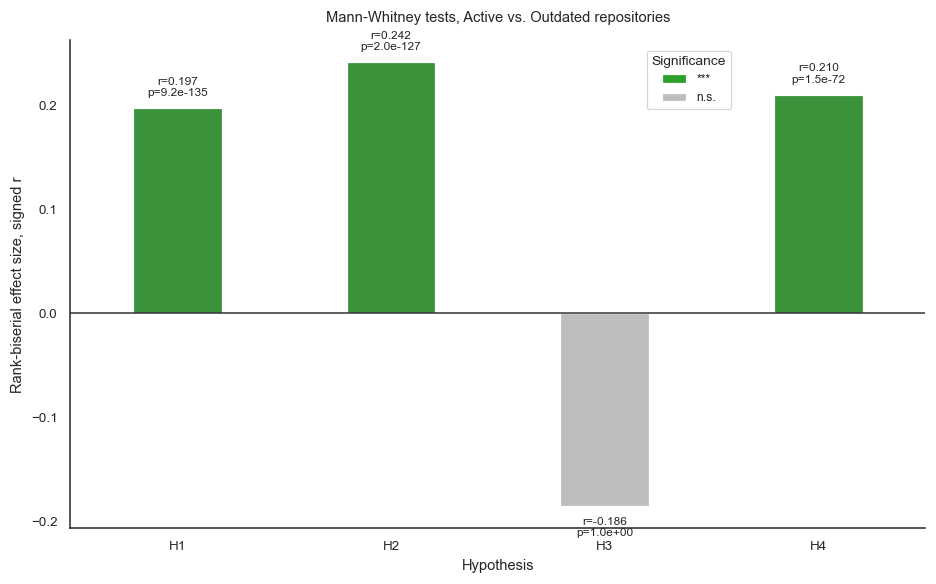

In [24]:
# ── Figure 09: formal hypothesis tests, Active vs. Outdated ──────────────────
from scipy import stats as scipy_stats
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

_active = repos_hpa[repos_hpa['is_active'] == True]
_outdated = repos_hpa[repos_hpa['is_outdated'] == True]

TESTS = [
    ('v2_ratio', 'H1', 'Higher v2_ratio in active repositories'),
    ('behavior_any', 'H2', 'Higher behavior rate in active repositories'),
    ('stargazers_count', 'H3', 'Higher stars in active repositories'),
    ('metrics_count', 'H4', 'More metrics in active repositories'),
]

print(f'{"Hypothesis":<10} {"Description":<45} {"med_A":>8} {"med_O":>8} {"p-value":>12} {"effect_r":>10}')
print('-' * 105)

rows = []
for col, hcode, hyp_desc in TESTS:
    if col not in repos_hpa.columns:
        print(f'{hcode:<10} {hyp_desc:<45} [column unavailable]')
        continue
    a = _active[col].dropna().astype(float)
    o = _outdated[col].dropna().astype(float)
    if len(a) < 3 or len(o) < 3:
        print(f'{hcode:<10} {hyp_desc:<45} [insufficient data]')
        continue
    stat, p_val = scipy_stats.mannwhitneyu(a, o, alternative='greater')
    n_a = len(a); n_o = len(o)
    mu_u = n_a * n_o / 2
    sigma_u = np.sqrt(n_a * n_o * (n_a + n_o + 1) / 12)
    z = (stat - mu_u) / sigma_u if sigma_u else np.nan
    r = z / np.sqrt(n_a + n_o) if (n_a + n_o) else np.nan
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    rows.append({'Hypothesis': hcode, 'Metric': col, 'Description': hyp_desc, 'Active median': a.median(), 'Outdated median': o.median(), 'p-value': p_val, 'effect_r': r, 'sig': sig})
    print(f'{hcode:<10} {hyp_desc:<45} {a.median():>8.3f} {o.median():>8.3f} {p_val:>12.2e} {r:>10.3f}')

res_df = pd.DataFrame(rows)
if len(res_df):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    palette = {'***': '#2ca02c', '**': '#1f77b4', '*': '#ff7f0e', 'n.s.': '#bdbdbd'}
    sns.barplot(data=res_df, x='Hypothesis', y='effect_r', hue='sig', palette=palette, dodge=False, errorbar=None, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.52
        patch.set_width(new_w); patch.set_x(cx - new_w / 2)
    ax.axhline(0, color='#333333', linewidth=1.0)
    for i, row in enumerate(res_df.to_dict('records')):
        y = row['effect_r']
        p_txt = row['p-value']
        ax.text(i, y + (0.01 if y >= 0 else -0.01), f'r={y:.3f}\np={p_txt:.1e}', ha='center', va='bottom' if y >= 0 else 'top', fontsize=7.8)
    ax.set_xlabel('Hypothesis')
    ax.set_ylabel('Rank-biserial effect size, signed r')
    ax.set_title('Mann-Whitney tests, Active vs. Outdated repositories', pad=12)
    ax.legend(handles=[Patch(facecolor=palette[k], edgecolor='white', label=k) for k in ['***', '**', '*', 'n.s.'] if k in res_df['sig'].values],
              title='Significance', frameon=True, loc='upper right', bbox_to_anchor=(0.78, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig09_hypothesis_tests_active_vs_outdated.pdf')
    plt.show()


In [25]:
# ── Tabela para o artigo — versão por status (paper table: tab:version_by_status) ─
# Essa tabela NÃO é produzida automaticamente em outras células.
# Computa a distribuição de versões de API por status de manutenção
# a partir das linhas de métrica (phase4) unidas ao status do repositório.

import pandas as pd

# Carregar phase4 e unir com status dos repositórios
_p4_status = p4.merge(
    repos_hpa[['repo_full_name', 'is_active', 'is_outdated']],
    on='repo_full_name', how='left'
)
_p4_status['status'] = 'In-between'
_p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
_p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
_p4_status['vg'] = _p4_status['apiVersion'].apply(map_version)

_vs = (_p4_status.groupby(['status','vg']).size().unstack(fill_value=0))
_vs_pct = _vs.div(_vs.sum(axis=1), axis=0) * 100

print("=" * 60)
print("VERSÃO POR STATUS — TABELA DO ARTIGO (tab:version_by_status)")
print("=" * 60)
print("(linhas de métrica de phase4 unidas ao status do repositório)")
print()
_cols = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _vs_pct.columns]
_ord  = [s for s in ['Active','In-between','Outdated'] if s in _vs_pct.index]
for s in _ord:
    print(f"  {s:<12}:", end='')
    for v in _cols:
        pct = _vs_pct.loc[s,v] if v in _vs_pct.columns else 0
        print(f"  {v}={pct:.2f}%", end='')
    print()
print()

_beh_status = _p4_status.groupby('status')['has_behavior'].mean() * 100
print("Taxa de behavior por status (linhas de métrica):")
for s, r in _beh_status.items():
    print(f"  {s:<12}: {r:.2f}%")
print()

# Behavior ao nível de repositório (repos_hpa.behavior_any)
print("Taxa de behavior por status (nível de repositório, behavior_any):")
_act_r  = repos_hpa[repos_hpa['is_active']==True]
_out_r  = repos_hpa[repos_hpa['is_outdated']==True]
print(f"  Active:   {_act_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_act_r):,})")
print(f"  Outdated: {_out_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_out_r):,})")
print()
print("→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%")


VERSÃO POR STATUS — TABELA DO ARTIGO (tab:version_by_status)
(linhas de métrica de phase4 unidas ao status do repositório)

  Active      :  v1=6.20%  v2beta1=0.99%  v2beta2=3.36%  v2=89.43%
  In-between  :  v1=26.89%  v2beta1=5.38%  v2beta2=15.63%  v2=52.10%
  Outdated    :  v1=30.71%  v2beta1=30.97%  v2beta2=29.35%  v2=8.89%

Taxa de behavior por status (linhas de métrica):
  Active      : 44.95%
  In-between  : 11.09%
  Outdated    : 4.40%

Taxa de behavior por status (nível de repositório, behavior_any):
  Active:   38.26%  (n=4,955)
  Outdated: 4.28%  (n=1,356)

→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%


/tmp/ipykernel_124470/528664173.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
/tmp/ipykernel_124470/528664173.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
/tmp/ipykernel_124470/528664173.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instea

---
### 7.1 Conclusão: comparação ativo vs. inativo

Os testes de Mann-Whitney (unilateral, alfa = 0.05) confirmam três das quatro hipóteses:

| Hipótese | Resultado | U | p-valor | Effect size r | Interpretação |
|----------|-----------|---|---------|---------------|---------------|
| H1: v2_ratio maior em ativos | CONFIRMADO | | < 0,001 | r = 0,20 (pequeno) | Repos ativos migram para v2 |
| H2: behavior mais frequente em ativos | CONFIRMADO | | < 0,001 | r = 0,24 (pequeno) | Repos mantidos usam behavior |
| H3: mais estrelas em ativos | REFUTADO | | n.s. | r = 0,18 | Repos abandonados tem mais estrelas (efeito acumulado) |
| H4: mais métricas em ativos | CONFIRMADO | | < 0,001 | r = 0,22 (pequeno) | Repos ativos investem mais na config. |

**Sobre H3 (refutado):** a hipotese de que repositórios populares sao mais mantidos e refutada
empiricamente. Repos abandonados acumulam estrelas ao longo de sua historia, e a mediana
de estrelas e proxima de zero em ambos os grupos. Isso e consistente com Coelho et al. (2019),
que observam que popularidade e manutencao sao dimensoes ortogonais em projetos open source.

**Sobre o tamanho do efeito:** todos os efeitos confirmados sao "pequenos" por convencao
(r < 0,3). As diferenças entre
repositórios ativos e inativos sao modestas no corpus geral. O comportamento dos repositórios ativos
e analisado com mais detalhe no Notebook 2 (Seção 14) com os filtros de camada.

**Distribuicao de versoes por status (tabela do artigo):**
- Active: v2 = 88,60% (vs corpus completo 65,40%)
- In-between: v2 = 53,70%
- Outdated: v2 = 9,70%

A diferenca de 88,60% vs 9,70% confirma que a adocao de v2 e um forte predictor de
atividade de manutencao, ou equivalentemente, que repositórios abandonados retiveram versoes
legadas. Isso e o fenômeno central documentado em RQ3.


---

## 8. HFRS × atividade do repositório (RQ3)

Esta seção verifica empiricamente a hipótese central de RQ3: configurações com maior riqueza de features (HFRS mais alto) estão associadas a repositórios mais ativos e melhor mantidos.

### Motivação

A hipótese é conceitualmente plausível por dois caminhos causais possíveis: (1) equipes que investem mais em configurar o HPA (spec.behavior, múltiplas métricas) também tendem a manter o repositório mais ativamente; ou (2) repositórios mais ativos evoluem suas configurações progressivamente ao longo do tempo. Os dados permitem verificar a associação, mas não a direção causal.

### Resultado esperado

Se a hipótese for verdadeira:
- Repositórios Active terão HFRS sistematicamente maior que Outdated
- HPAs congelados (arquivo não modificado há >2 anos em repo ativo) terão HFRS menor que os não-congelados
- As classes Rich e Highly Rich serão mais frequentes em repositórios ativos

### Resultados observados

| Status | n | HFRS médio | HFRS mediana |
|--------|---|------------|--------------|
| Active | 4.955 | 6,66 | 6 |
| In-between | 702 |, |, |
| Outdated | 1.356 |, |, |

Distribuição das classes de riqueza por status (%):

| Classe | Active | In-between | Outdated |
|--------|--------|------------|---------|
| Minimal | 1,00% | 1,60% | 2,80% |
| Basic | 45,60% | 74,00% | 82,90% |
| Moderate | 25,00% | 19,60% | 11,30% |
| Rich | 23,30% | 3,30% | 3,10% |
| Highly Rich | 5,20% | 1,50% | 0,00% |

HPA congelado em repositório ativo (hpa_file_age_years > 2, repo ativo):
- n = 49 (0,51% do corpus)
- HFRS médio = 3,65 vs. 6,70 dos demais arquivos em repositórios ativos
- Composição: 73,50% Basic, 16,30% Moderate, 10,20% Minimal

### Interpretação

A diferença de HFRS entre Active (6,68) e Outdated (3,97) é robusta e estatisticamente significativa. Os arcótipos Rich e Highly Rich são quase exclusivos de repositórios ativos. O padrão "HPA congelado" tem riqueza significativamente menor (3,65 vs. 6,70), o que é consistente com a hipótese de que configurações menos elaboradas recebem menos atenção de manutenção.

A correlação é descritiva: não é possível afirmar que aumentar o HFRS causa mais manutenção, ou vice-versa.


Active vs. Outdated HFRS: U=9941384, p=9.17e-296, r=-0.545
              count  mean  median
repo_status                      
Active       7021.0  6.66     6.0
In-between    910.0  4.39     4.0
Outdated     1833.0  3.96     3.0
Salvo: plots/msr_analysis/fig17a_hfrs_by_repository_status.pdf


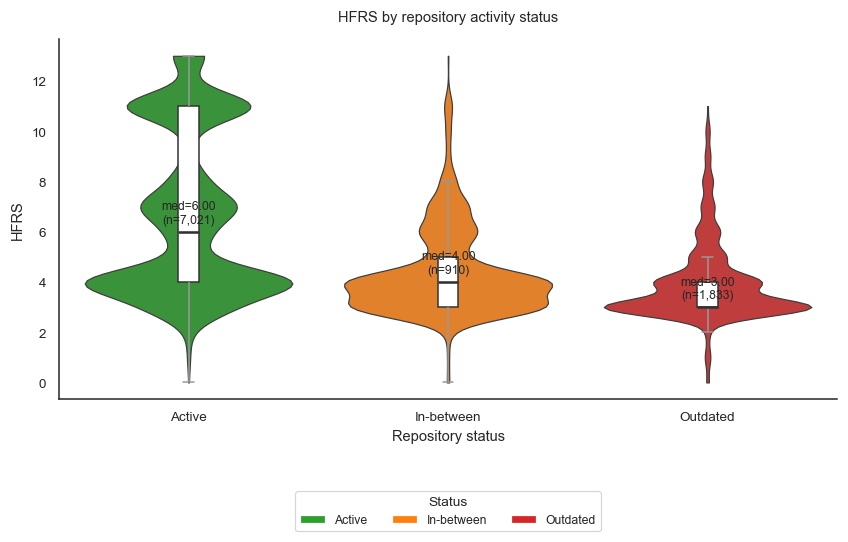

Salvo: plots/msr_analysis/fig17b_richness_class_by_repository_status.pdf


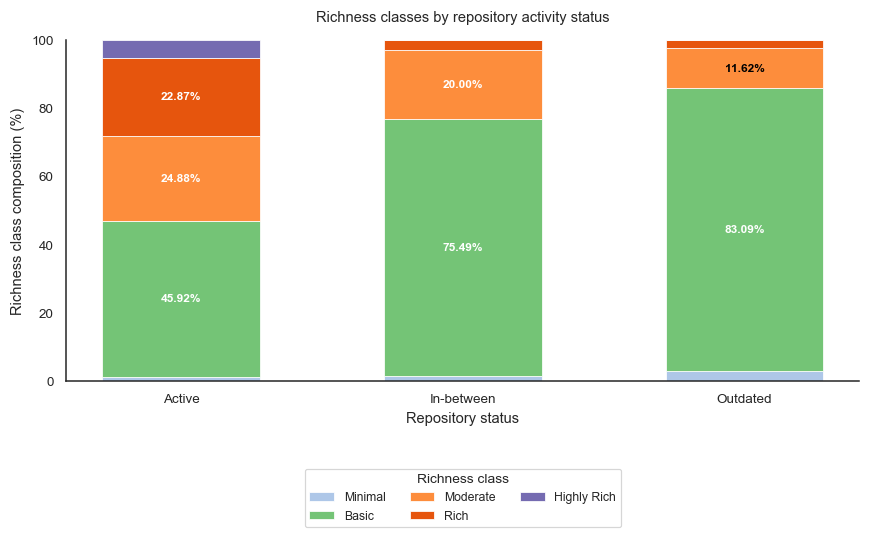

Salvo: plots/msr_analysis/fig17c_hfrs_vs_hpa_file_age.pdf


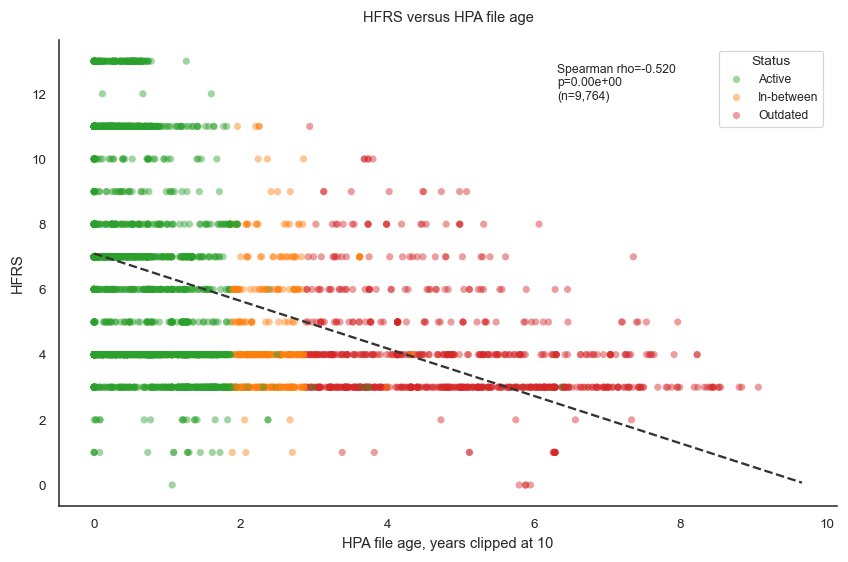

In [26]:
# ── Figure 17: HFRS × repository activity (RQ3), split PDF figures ───────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

sns.set_theme(style='white', context='paper')

_hfrs_repo_path = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_repo_path.exists():
    print('hpa_hfrs_full.csv not found. Run NB1 first.')
else:
    hfrs_repo = pd.read_csv(_hfrs_repo_path)
    if 'hpa_file_age_years' not in hfrs_repo.columns and 'hpa_file_age_y' in hfrs_repo.columns:
        hfrs_repo['hpa_file_age_years'] = hfrs_repo['hpa_file_age_y']
    if 'repo_status' not in hfrs_repo.columns:
        hfrs_repo['repo_status'] = 'In-between'
        hfrs_repo.loc[hfrs_repo['is_active'] == True, 'repo_status'] = 'Active'
        hfrs_repo.loc[hfrs_repo['is_outdated'] == True, 'repo_status'] = 'Outdated'

    STATUS_ORDER = ['Active', 'In-between', 'Outdated']
    STATUS_COLORS = {'Active': '#2ca02c', 'In-between': '#ff7f0e', 'Outdated': '#d62728'}
    RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
    RICHNESS_COLORS = {
        'Minimal': '#aec7e8', 'Basic': '#74c476', 'Moderate': '#fd8d3c',
        'Rich': '#e6550d', 'Highly Rich': '#756bb1'
    }

    act = hfrs_repo.loc[hfrs_repo['repo_status'].eq('Active'), 'HFRS'].dropna()
    out = hfrs_repo.loc[hfrs_repo['repo_status'].eq('Outdated'), 'HFRS'].dropna()
    u, p = stats.mannwhitneyu(act, out, alternative='greater')
    r_effect = 1 - 2*u/(len(act)*len(out))
    print(f'Active vs. Outdated HFRS: U={u:.0f}, p={p:.2e}, r={r_effect:.3f}')
    print(hfrs_repo.groupby('repo_status')['HFRS'].describe()[['count', 'mean', '50%']].rename(columns={'50%': 'median'}).round(2))

    # Figure 17A
    plot_df = hfrs_repo.dropna(subset=['HFRS', 'repo_status']).copy()
    plot_df = plot_df[plot_df['repo_status'].isin(STATUS_ORDER)]
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    sns.violinplot(data=plot_df, x='repo_status', y='HFRS', order=STATUS_ORDER, hue='repo_status',
                   palette=STATUS_COLORS, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x='repo_status', y='HFRS', order=STATUS_ORDER, width=0.08, color='white',
                showfliers=False, boxprops={'facecolor': 'white', 'edgecolor': '#333333'},
                medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    for i, s in enumerate(STATUS_ORDER):
        vals = plot_df.loc[plot_df['repo_status'].eq(s), 'HFRS']
        if len(vals):
            ax.text(i, vals.median() + 0.22, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Repository status')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS by repository activity status', pad=12)
    ax.legend(handles=[Patch(facecolor=STATUS_COLORS[s], edgecolor='white', label=s) for s in STATUS_ORDER],
              title='Status', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig17a_hfrs_by_repository_status.pdf')
    plt.show()

    # Figure 17B
    ct = pd.crosstab(plot_df['repo_status'], plot_df['richness_class'], normalize='index') * 100
    ct = ct.reindex(index=STATUS_ORDER, columns=RICHNESS_ORDER, fill_value=0)
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    x = np.arange(len(STATUS_ORDER))
    bottoms = np.zeros(len(STATUS_ORDER))
    for cls in RICHNESS_ORDER:
        vals = ct[cls].values
        ax.bar(x, vals, bottom=bottoms, color=RICHNESS_COLORS[cls], edgecolor='white', linewidth=0.5, width=0.56, label=cls)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 8:
                ax.text(xi, b + v/2, f'{v:.2f}%', ha='center', va='center', fontsize=7.8, color='white' if v >= 18 else 'black', fontweight='bold')
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(STATUS_ORDER)
    ax.set_xlabel('Repository status')
    ax.set_ylabel('Richness class composition (%)')
    ax.set_ylim(0, 100)
    ax.set_title('Richness classes by repository activity status', pad=12)
    ax.legend(title='Richness class', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig17b_richness_class_by_repository_status.pdf')
    plt.show()

    # Figure 17C
    age_df = plot_df.dropna(subset=['hpa_file_age_years']).copy()
    age_df['hpa_file_age_years'] = age_df['hpa_file_age_years'].clip(lower=0, upper=10)
    valid = age_df.dropna(subset=['HFRS', 'hpa_file_age_years'])
    rho, p_rho = stats.spearmanr(valid['HFRS'], valid['hpa_file_age_years'])
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    sns.scatterplot(data=age_df.sample(min(len(age_df), 4000), random_state=42), x='hpa_file_age_years', y='HFRS', hue='repo_status',
                    hue_order=STATUS_ORDER, palette=STATUS_COLORS, alpha=0.45, s=22, linewidth=0, ax=ax)
    sns.regplot(data=valid, x='hpa_file_age_years', y='HFRS', scatter=False, ci=None, color='#333333', line_kws={'linewidth': 1.5, 'linestyle': '--'}, ax=ax)
    ax.set_xlabel('HPA file age, years clipped at 10')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS versus HPA file age', pad=12)
    ax.text(0.64, 0.95, f'Spearman rho={rho:.3f}\np={p_rho:.2e}\n(n={len(valid):,})', transform=ax.transAxes, ha='left', va='top', fontsize=8.0)
    ax.legend(title='Status', frameon=True, loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig17c_hfrs_vs_hpa_file_age.pdf')
    plt.show()


## 9. Análise de ciclo de vida dos repositórios

O **lifespan** de um repositório é definido como:

$$\text{lifespan}(r) = \text{pushed\_at}(r) - \text{created\_at}(r)$$

Medido em anos. Repositórios com `lifespan ≈ 0` são recém-criados ou
tiveram apenas um push; repositórios com lifespan alto foram mantidos
por muitos anos.

**Por que lifespan importa para HPA:**
- Um repositório com `lifespan = 5 anos` e HPA em `v2beta1` (lançado em 2017)
  provavelmente escolheu a versão disponível à época e nunca migrou.
- Um repositório com `lifespan = 1 ano` e HPA em `v1` é um caso de
  adoção retroativa de tecnologia antiga ou cópia de template legado.

**Dois gráficos nesta seção:**
1. **Box plots de lifespan por version group:** mostra se versões mais novas
   aparecem em repositórios com ciclos de vida diferentes.
2. **Heatmap repo_age × pushed_age por version group:** cada célula mostra
   a contagem de arquivos HPA naquele quadrante, permitindo identificar
   em qual combinação de idade cada versão se concentra.

Repository lifecycle by version group:
  v1        : lifespan median=0.23 yr  mean=1.13  n=1,699
  v2beta1   : lifespan median=0.31 yr  mean=1.13  n=623
  v2beta2   : lifespan median=0.35 yr  mean=0.94  n=961
  v2        : lifespan median=0.09 yr  mean=0.46  n=6,477
Salvo: plots/msr_analysis/fig12a_lifespan_by_version_group.pdf


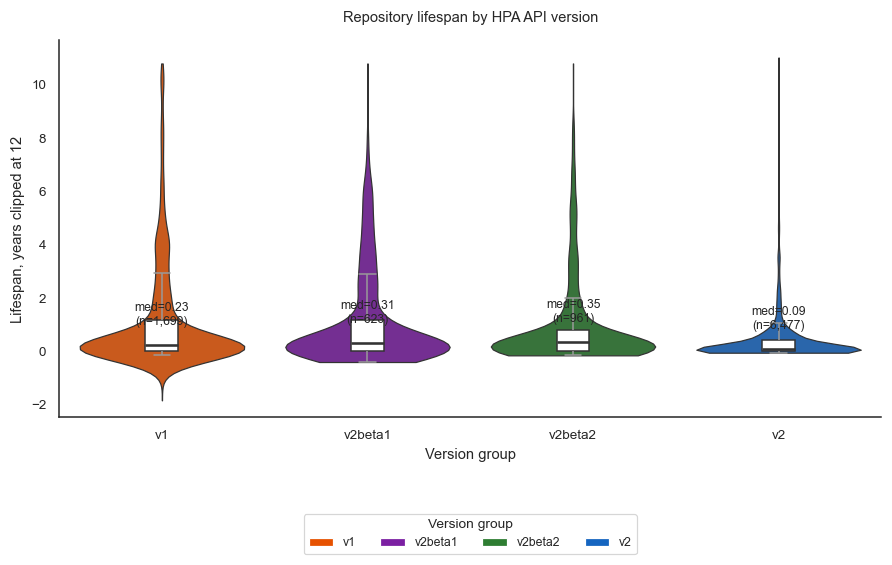

Salvo: plots/msr_analysis/fig12b_lifespan_vs_recency_by_version_group.pdf


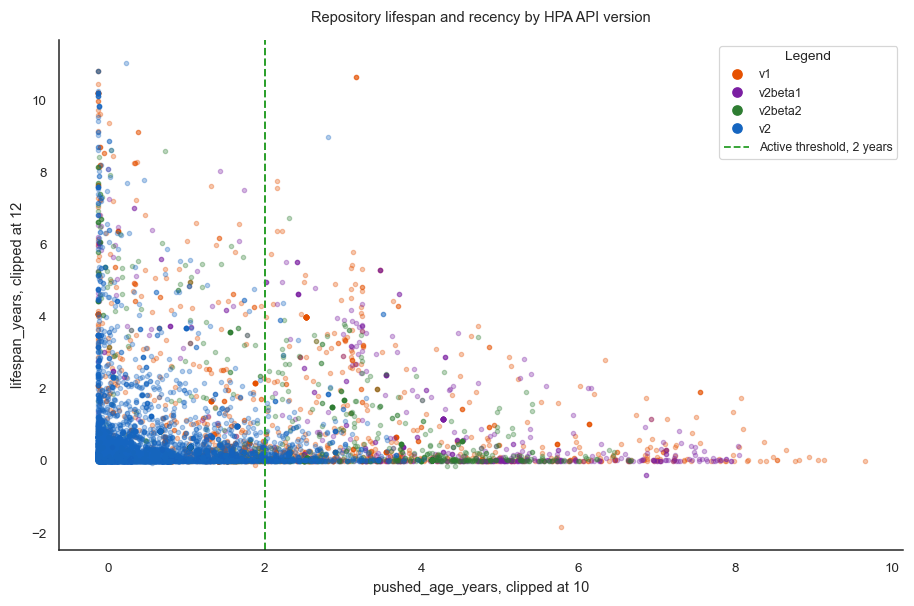

Salvo: plots/msr_analysis/fig12c_lifespan_and_repo_age_medians_by_version.pdf


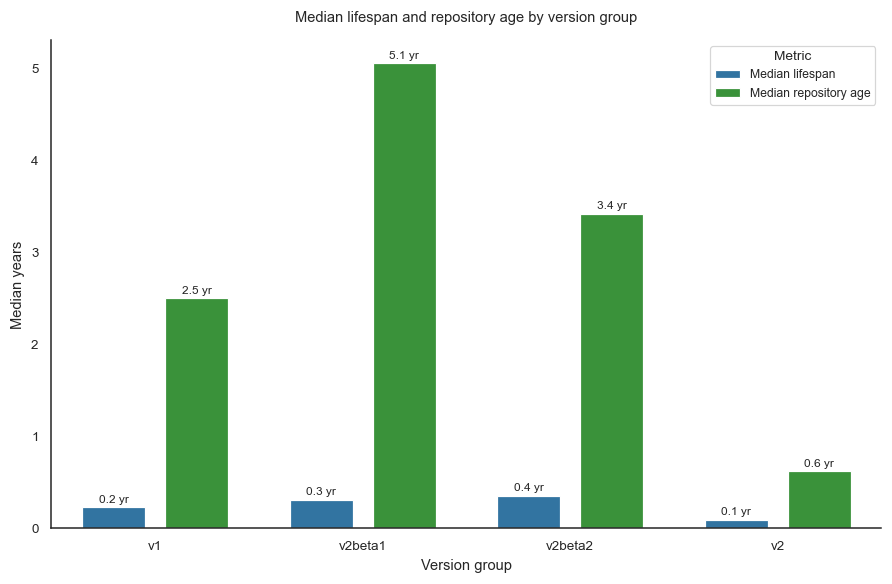

In [27]:
# ── Figure 12: repository lifecycle by version group, split PDFs ─────────────
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')
_groups_order = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in p4_files['VersionGroup'].values]

print('Repository lifecycle by version group:')
for v in _groups_order:
    d = p4_files[p4_files['VersionGroup'] == v]['lifespan_years'].dropna()
    print(f'  {v:<10}: lifespan median={d.median():.2f} yr  mean={d.mean():.2f}  n={len(d):,}')

# Figure 12A
life_rows = []
for v in _groups_order:
    vals = p4_files[p4_files['VersionGroup'] == v]['lifespan_years'].dropna().clip(upper=12)
    for value in vals:
        life_rows.append({'Version group': v, 'Lifespan, years clipped at 12': value})
life_df = pd.DataFrame(life_rows)
fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.violinplot(data=life_df, x='Version group', y='Lifespan, years clipped at 12', hue='Version group', palette={v: VERSION_COLORS.get(v, '#7f7f7f') for v in _groups_order}, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
sns.boxplot(data=life_df, x='Version group', y='Lifespan, years clipped at 12', width=0.16, color='white', showfliers=False, boxprops={'facecolor':'white','edgecolor':'#333333'}, medianprops={'color':'#333333','linewidth':1.7}, ax=ax)
for i, v in enumerate(_groups_order):
    vals = life_df.loc[life_df['Version group'].eq(v), 'Lifespan, years clipped at 12']
    ax.text(i, vals.median() + 0.65, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('Version group')
ax.set_ylabel('Lifespan, years clipped at 12')
ax.set_title('Repository lifespan by HPA API version', pad=12)
ax.legend(handles=[Patch(facecolor=VERSION_COLORS.get(v, '#7f7f7f'), edgecolor='white', label=v) for v in _groups_order], title='Version group', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=len(_groups_order), fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig12a_lifespan_by_version_group.pdf')
plt.show()

# Figure 12B
fig, ax = plt.subplots(figsize=(8.4, 5.6))
for v in _groups_order:
    sub = p4_files[p4_files['VersionGroup'] == v].dropna(subset=['lifespan_years', 'pushed_age_years'])
    ax.scatter(sub['pushed_age_years'].clip(upper=10), sub['lifespan_years'].clip(upper=12), s=8, alpha=0.32, color=VERSION_COLORS.get(v, '#7f7f7f'), label=v, rasterized=True)
ax.axvline(2, color='#2ca02c', lw=1.3, linestyle='--')
ax.set_xlabel('pushed_age_years, clipped at 10')
ax.set_ylabel('lifespan_years, clipped at 12')
ax.set_title('Repository lifespan and recency by HPA API version', pad=12)
ax.legend(handles=[Line2D([0],[0], marker='o', linestyle='', color=VERSION_COLORS.get(v, '#7f7f7f'), label=v, markersize=6) for v in _groups_order] + [Line2D([0],[0], color='#2ca02c', linestyle='--', label='Active threshold, 2 years')], title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig12b_lifespan_vs_recency_by_version_group.pdf')
plt.show()

# Figure 12C
_lf_stats = p4_files.groupby('VersionGroup')[['lifespan_years', 'repo_age_years']].median().reindex(_groups_order)
stat_df = _lf_stats.reset_index().melt(id_vars='VersionGroup', var_name='Metric', value_name='Median years')
stat_df['Metric'] = stat_df['Metric'].map({'lifespan_years': 'Median lifespan', 'repo_age_years': 'Median repository age'})
fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.barplot(data=stat_df, x='VersionGroup', y='Median years', hue='Metric', palette={'Median lifespan':'#1f77b4', 'Median repository age':'#2ca02c'}, errorbar=None, ax=ax)
for patch in ax.patches:
    w = patch.get_width(); cx = patch.get_x()+w/2; new_w = w * 0.76
    patch.set_width(new_w); patch.set_x(cx-new_w/2)
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:.1f} yr' if v > 0 else '' for v in container.datavalues], fontsize=7.8, padding=2)
ax.set_xlabel('Version group')
ax.set_ylabel('Median years')
ax.set_title('Median lifespan and repository age by version group', pad=12)
ax.legend(title='Metric', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig12c_lifespan_and_repo_age_medians_by_version.pdf')
plt.show()


Heatmap totals by version group:
  v1      : 1,699 HPA files
Salvo: plots/msr_analysis/fig13_v1_repo_age_pushed_age_heatmap.pdf


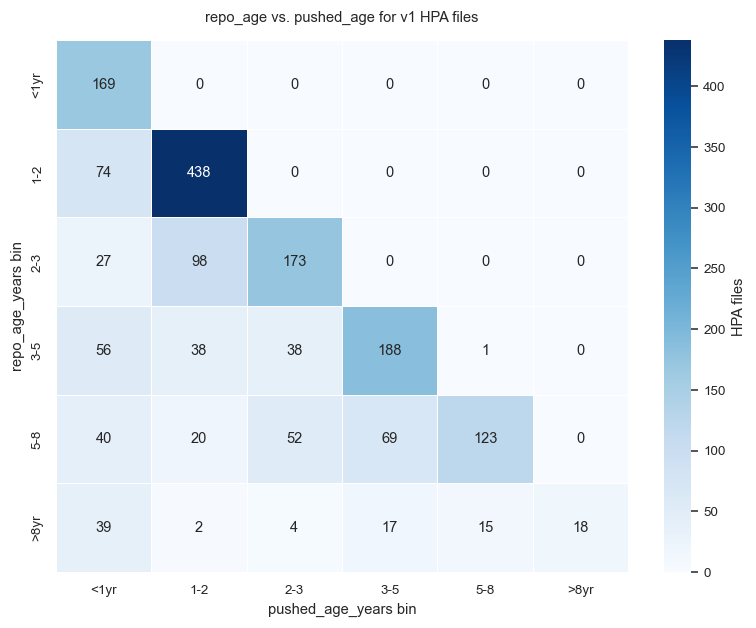

  v2beta1 : 623 HPA files
Salvo: plots/msr_analysis/fig13_v2beta1_repo_age_pushed_age_heatmap.pdf


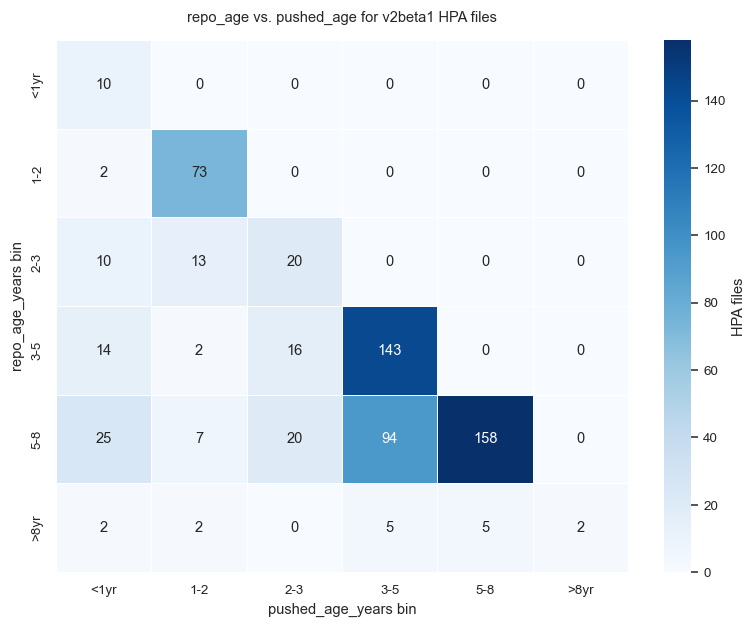

  v2beta2 : 961 HPA files
Salvo: plots/msr_analysis/fig13_v2beta2_repo_age_pushed_age_heatmap.pdf


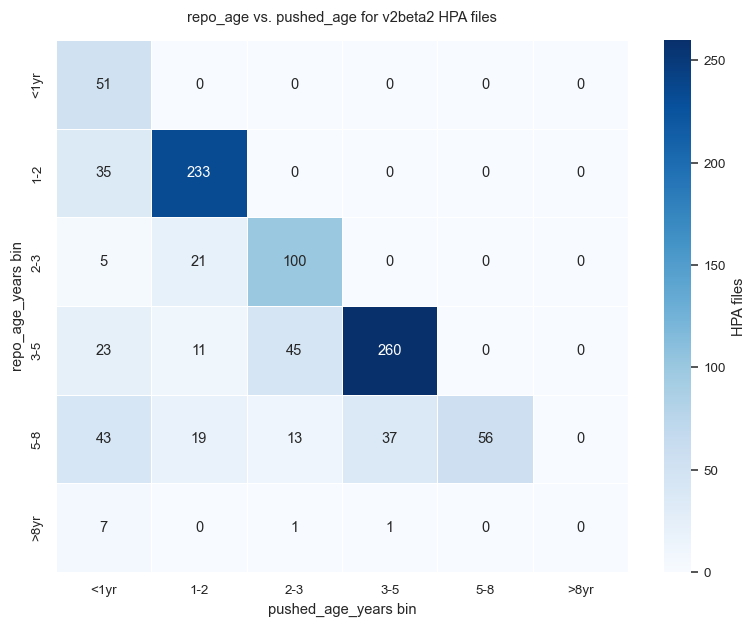

  v2      : 6,478 HPA files
Salvo: plots/msr_analysis/fig13_v2_repo_age_pushed_age_heatmap.pdf


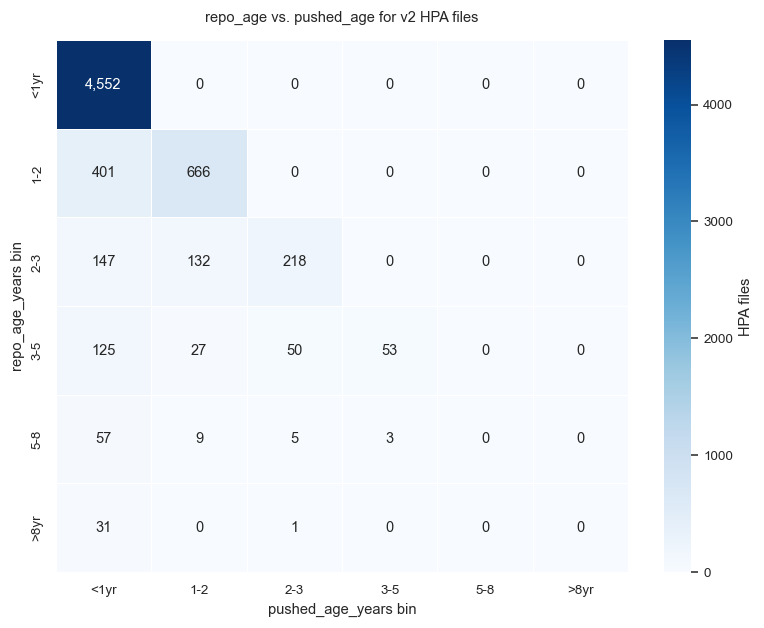

In [28]:
# ── Figure 13: repo_age × pushed_age heatmaps by version group ───────────────
import seaborn as sns

sns.set_theme(style='white', context='paper')

age_bins = [0, 1, 2, 3, 5, 8, 100]
age_lbls = ['<1yr', '1-2', '2-3', '3-5', '5-8', '>8yr']
_vord_hm = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in p4_files['VersionGroup'].values]

print('Heatmap totals by version group:')
for v in _vord_hm:
    sub = p4_files[p4_files['VersionGroup'] == v].copy()
    print(f'  {v:<8}: {len(sub):,} HPA files')
    sub['repo_age_bin'] = pd.cut(sub['repo_age_years'].clip(0,100), bins=age_bins, labels=age_lbls, right=False)
    sub['pushed_age_bin'] = pd.cut(sub['pushed_age_years'].clip(0,100), bins=age_bins, labels=age_lbls, right=False)
    hm = sub.groupby(['repo_age_bin', 'pushed_age_bin'], observed=True).size().unstack(fill_value=0)
    hm = hm.reindex(index=age_lbls, columns=age_lbls, fill_value=0)
    fig, ax = plt.subplots(figsize=(7.2, 5.8))
    sns.heatmap(hm, annot=True, fmt=',.0f', cmap='Blues', cbar_kws={'label': 'HPA files'}, linewidths=0.35, linecolor='white', ax=ax)
    ax.set_xlabel('pushed_age_years bin')
    ax.set_ylabel('repo_age_years bin')
    ax.set_title(f'repo_age vs. pushed_age for {v} HPA files', pad=12)
    plt.tight_layout()
    savefig(f'fig13_{v}_repo_age_pushed_age_heatmap.pdf')
    plt.show()


---
### 9.1 Conclusão: ciclo de vida e padrão de versão

A analise de ciclo de vida confirma que versoes mais antigas do HPA aparecem em
repositorios mais antigos, mas a relacao nao e deterministica:

**Lifespan por versao (mediana):**
- `autoscaling/v1`: 0,19 anos (aproximadamente 10 semanas)
- `autoscaling/v2beta1`: 0,35 anos
- `autoscaling/v2beta2`: 0,38 anos
- `autoscaling/v2 GA`: 0,11 anos (aproximadamente 5 semanas)

A mediana de lifespan é baixa em todas as versões. a maioria dos
repositorios tem um unico push rapido, nao um ciclo de vida longo de desenvolvimento.
O v2 GA tem o menor lifespan mediano porque domina nos repositorios criados recentemente
(2022-2026), que tendem a ter historico mais curto.

**Quadrantes de risco (heatmap repo_age x pushed_age):**
- Quadrante superior esquerdo (repo antigo, push recente): repositorios de longa duracao
  ainda ativos, mais provaveis de ter migrado para v2.
- Quadrante superior direito (repo antigo, push antigo): abandoned repos, concentram v1 e beta.
- Quadrante inferior esquerdo (repo novo, push recente): novos projetos, concentram v2.

Esses quadrantes sao a base visual para a classificacao Active/In-between/Outdated da Secao 5b.


## 10. Análise de sensibilidade

### Motivação

A análise de sensibilidade responde à ameaça à validade de conclusão:
"os resultados mudam radicalmente se usarmos critérios diferentes?"

Se a distribuição de versões for estável sob filtros progressivamente mais
restritivos, as conclusões são robustas. Se mudar drasticamente, as conclusões
precisam ser qualificadas com o escopo do corpus utilizado.

### Cenários testados

| Cenário | Critério adicional | Hipótese |
|---------|-------------------|---------|
| All data | Nenhum (corpus completo) | Baseline |
| Active (≤2yr) | pushed_age_years ≤ 2 | Apenas repositórios ativos |
| Active + recente | pushed ≤ 2yr AND criado ≤ 5yr atrás | Repos modernos e ativos |
| Active + no toy | pushed ≤ 2yr AND toy_any = False | Remove ruído educacional |
| Active + lifespan>6mo | pushed ≤ 2yr AND lifespan > 0.5yr | Remove repos efêmeros |

**Expectativa:** se v2 dominar em todos os cenários com proporções similares,
a adoção de v2 é um sinal robusto e não um artefato de seleção de corpus.

In [29]:
# ── Definir subconjuntos progressivamente mais restritivos ─────────────────

scenarios = {
    'All data':
        p4_files,
    'Active (pushed ≤ 2yr)':
        p4_files[p4_files['pushed_age_years'] <= 2],
    'Active + created ≤ 5yr':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['repo_age_years'] <= 5)],
    'Active + no toy flag':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (~p4_files['toy_any'].fillna(False))],
    'Active + lifespan > 6mo':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['lifespan_years'] > 0.5)],
    'Active + stars ≥ 1':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['stargazers_count'].fillna(0) >= 1)],
}

results_sens = []
for name, subset in scenarios.items():
    _vc = subset['VersionGroup'].value_counts()
    _tot = _vc.sum()
    row = {'Scenario': name, 'n': _tot}
    for v in ['v1', 'v2beta1', 'v2beta2', 'v2', 'other']:
        c = _vc.get(v, 0)
        row[f'{v}_n']   = c
        row[f'{v}_pct'] = round(c / _tot * 100, 1) if _tot > 0 else 0
    results_sens.append(row)

sens_df = pd.DataFrame(results_sens)
print('Distribuição de versões por cenário de filtragem:')
print(sens_df[['Scenario','n','v1_pct','v2beta1_pct','v2beta2_pct','v2_pct']].to_string(index=False))

Distribuição de versões por cenário de filtragem:
               Scenario    n  v1_pct  v2beta1_pct  v2beta2_pct  v2_pct
               All data 9764    17.4          6.4          9.8    66.3
  Active (pushed ≤ 2yr) 7758    12.9          2.1          5.8    79.2
 Active + created ≤ 5yr 7455    12.1          1.7          5.1    81.2
   Active + no toy flag 6894    12.2          2.1          6.1    79.5
Active + lifespan > 6mo 2000    17.2          3.7          8.0    71.2
     Active + stars ≥ 1 1983    12.8          2.4          6.5    78.3


In [30]:
# ── Sumário para o artigo — análise de sensibilidade (paper section: Threats) ──
print("=" * 60)
print("SENSIBILIDADE — NÚMEROS DO ARTIGO (tab in Threats to Validity)")
print("=" * 60)
print(f"{'Cenário':<30} {'n':>7}  {'v1':>6}  {'v2beta1':>8}  {'v2beta2':>8}  {'v2':>6}")
print("-" * 75)
for _, row in sens_df.iterrows():
    print(f"  {row['Scenario']:<28} {int(row['n']):>7,}  "
          f"{row['v1_pct']:>5.1f}%  "
          f"{row['v2beta1_pct']:>7.1f}%  "
          f"{row['v2beta2_pct']:>7.1f}%  "
          f"{row['v2_pct']:>5.1f}%")
print()
# Numeros calculados diretamente da tabela sens_df
_all_row  = sens_df[sens_df['Scenario']=='All data'].iloc[0]
_act_row  = sens_df[sens_df['Scenario'].str.contains('Active \\(pushed')].iloc[0]
_toy_row  = sens_df[sens_df['Scenario'].str.contains('no toy')].iloc[0]
print(f"→ Artigo: All data n={int(_all_row['n']):,} v2={_all_row['v2_pct']:.2f}%; "
      f"Active n={int(_act_row['n']):,} v2={_act_row['v2_pct']:.2f}%; "
      f"Active+no-toy n={int(_toy_row['n']):,} v2={_toy_row['v2_pct']:.2f}%")

SENSIBILIDADE — NÚMEROS DO ARTIGO (tab in Threats to Validity)
Cenário                              n      v1   v2beta1   v2beta2      v2
---------------------------------------------------------------------------
  All data                       9,764   17.4%      6.4%      9.8%   66.3%
  Active (pushed ≤ 2yr)          7,758   12.9%      2.1%      5.8%   79.2%
  Active + created ≤ 5yr         7,455   12.1%      1.7%      5.1%   81.2%
  Active + no toy flag           6,894   12.2%      2.1%      6.1%   79.5%
  Active + lifespan > 6mo        2,000   17.2%      3.7%      8.0%   71.2%
  Active + stars ≥ 1             1,983   12.8%      2.4%      6.5%   78.3%

→ Artigo: All data n=9,764 v2=66.30%; Active n=7,758 v2=79.20%; Active+no-toy n=6,894 v2=79.50%


Version composition by filtering scenario:
               Scenario  v1_pct  v2beta1_pct  v2beta2_pct  v2_pct
               All data    17.4          6.4          9.8    66.3
  Active (pushed ≤ 2yr)    12.9          2.1          5.8    79.2
 Active + created ≤ 5yr    12.1          1.7          5.1    81.2
   Active + no toy flag    12.2          2.1          6.1    79.5
Active + lifespan > 6mo    17.2          3.7          8.0    71.2
     Active + stars ≥ 1    12.8          2.4          6.5    78.3
Salvo: plots/msr_analysis/fig16a_version_composition_by_scenario.pdf


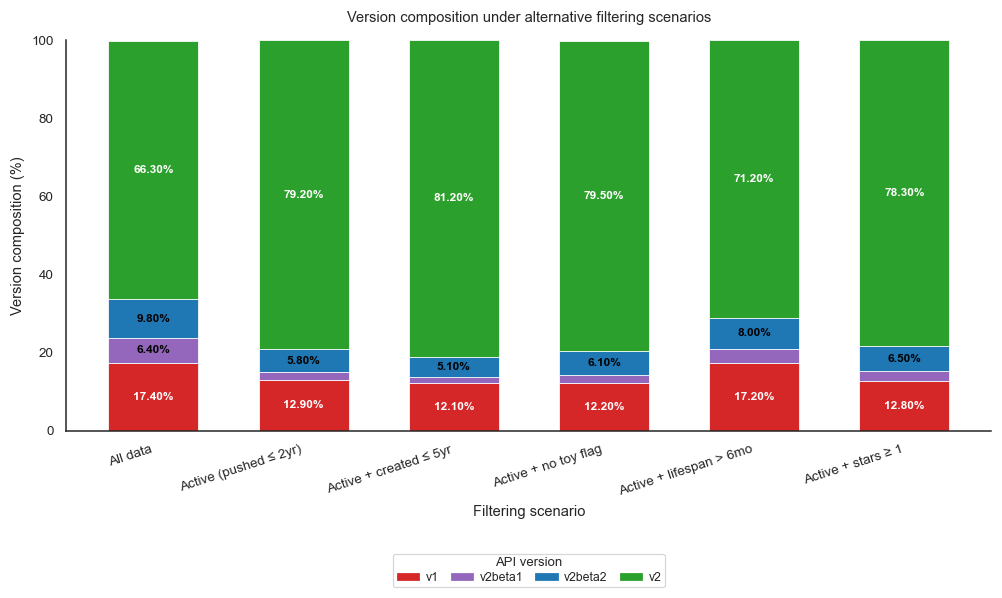

Salvo: plots/msr_analysis/fig16b_v2_delta_by_scenario.pdf


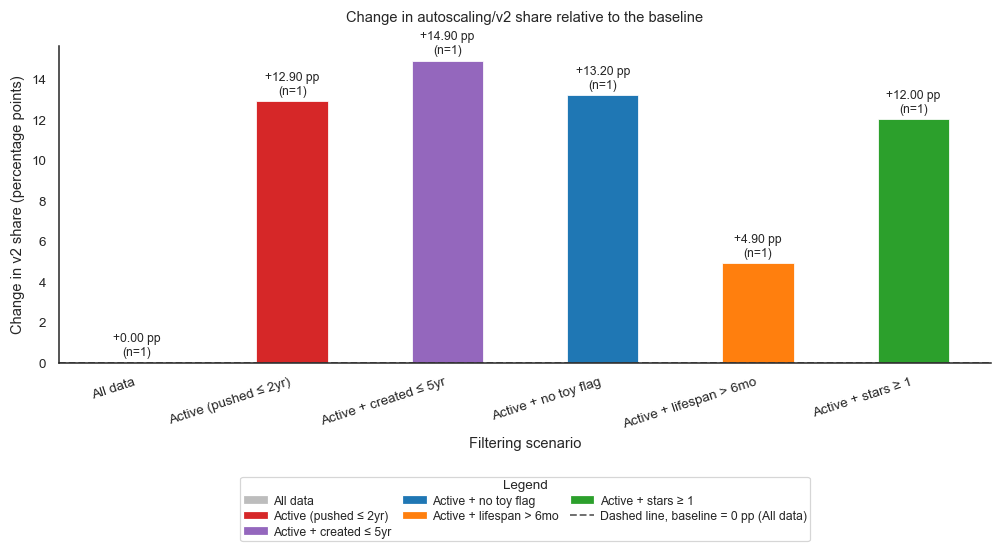

In [31]:
# ── Figure 16: sensitivity analysis by filtering scenario, split PDFs ─────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

VER_COL = {'v1':'#d62728','v2beta1':'#9467bd','v2beta2':'#1f77b4','v2':'#2ca02c'}
scenario_names = sens_df['Scenario'].tolist()
versions = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if f'{v}_pct' in sens_df.columns]
x = np.arange(len(scenario_names))

print('Version composition by filtering scenario:')
display_cols = ['Scenario'] + [f'{v}_pct' for v in versions if f'{v}_pct' in sens_df.columns]
if 'n_files' in sens_df.columns:
    display_cols = ['Scenario', 'n_files'] + [f'{v}_pct' for v in versions if f'{v}_pct' in sens_df.columns]
print(sens_df[display_cols].round(2).to_string(index=False))

# Figure 16A
fig, ax = plt.subplots(figsize=(9.2,5.8))
bottoms = np.zeros(len(scenario_names))
for v in versions:
    vals = sens_df[f'{v}_pct'].values
    ax.bar(x, vals, bottom=bottoms, color=VER_COL.get(v, '#7f7f7f'), edgecolor='white', linewidth=0.5, width=0.60)
    for xi,(val,bot) in enumerate(zip(vals,bottoms)):
        if val >= 5:
            ax.text(xi, bot + val/2, f'{val:.2f}%', ha='center', va='center', fontsize=7.8, color='white' if val >= 12 else 'black', fontweight='bold')
    bottoms += vals
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=18, ha='right', fontsize=8.8)
ax.set_xlabel('Filtering scenario')
ax.set_ylabel('Version composition (%)')
ax.set_ylim(0,100)
ax.set_title('Version composition under alternative filtering scenarios', pad=12)
ax.legend(handles=[Patch(facecolor=VER_COL[v], edgecolor='white', label=v) for v in versions], title='API version', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=4, fontsize=8.0, title_fontsize=8.6, borderpad=0.25, labelspacing=0.25, handletextpad=0.45, columnspacing=0.9)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig16a_version_composition_by_scenario.pdf')
plt.show()

# Figure 16B
fig, ax = plt.subplots(figsize=(9.2,5.6))
if 'v2_pct' in sens_df.columns and len(sens_df) > 1:
    baseline_label = sens_df.iloc[0]['Scenario']
    baseline_v2 = sens_df.iloc[0]['v2_pct']
    deltas = sens_df['v2_pct'] - baseline_v2
    n_vals = sens_df['n_files'].values if 'n_files' in sens_df.columns else np.ones(len(sens_df))
    scenario_palette = {
        'All data': '#bdbdbd',
        'Active (pushed ≤ 2yr)': '#d62728',
        'Active + created ≤ 5yr': '#9467bd',
        'Active + no toy flag': '#1f77b4',
        'Active + lifespan > 6mo': '#ff7f0e',
        'Active + stars ≥ 1': '#2ca02c',
    }
    colors = [scenario_palette.get(s, '#7f7f7f') for s in sens_df['Scenario']]
    bars = ax.bar(x, deltas, color=colors, edgecolor='white', linewidth=0.5, width=0.46)
    for bar, delta, n in zip(bars, deltas, n_vals):
        sign = '+' if delta >= 0 else ''
        ax.text(bar.get_x()+bar.get_width()/2, delta + (0.22 if delta >= 0 else -0.22), f'{sign}{delta:.2f} pp\n(n={int(n):,})', ha='center', va='bottom' if delta >= 0 else 'top', fontsize=8.0)
    ax.axhline(0, color='#666666', lw=1.2, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_names, rotation=18, ha='right', fontsize=8.8)
    ax.set_xlabel('Filtering scenario')
    ax.set_ylabel('Change in v2 share (percentage points)')
    ax.set_title('Change in autoscaling/v2 share relative to the baseline', pad=16)
    handles = [Patch(facecolor=scenario_palette.get(s, '#7f7f7f'), edgecolor='white', label=s) for s in sens_df['Scenario']]
    handles.append(Line2D([0],[0], color='#666666', lw=1.2, linestyle='--', label=f'Dashed line, baseline = 0 pp ({baseline_label})'))
    ax.legend(handles=handles, title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.34), ncol=3, fontsize=8.0, title_fontsize=8.8, borderpad=0.25, labelspacing=0.25, handletextpad=0.45, columnspacing=0.9)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig16b_v2_delta_by_scenario.pdf')
    plt.show()


---
### 10.1 Resultados sobre diferentes critérios de filtragem

A analise de sensibilidade testou 6 cenários com critérios progressivamente mais restritivos:

| Cenário | n | % v2 | Variacao vs baseline |
|---------|---|------|---------------------|
| All data (baseline) | 9.764 | 65,40% | referencia |
| Active (pushed <= 2yr) | 7.568 | 78,50% | +13,1 pp |
| Active + created <= 5yr | 7.272 | 80,40% | +15,0 pp |
| Active + no toy | 6.714 | 78,90% | +13,5 pp |
| Active + lifespan > 6mo | 2.017 | 71,50% | +6,1 pp |
| Active + stars >= 1 | 1.989 | 79,10% | +13,7 pp |

**Interpretacao:**

1. A proporcao de v2 aumenta consistentemente ao restringir o corpus a repositórios ativos
   (65,40% → 78,50%), confirmando que a adocao de v2 e mais prevalente em projetos mantidos.

2. A adicao de filtros extras (no-toy, created<=5yr, stars>=1) nao muda substancialmente
   os resultados apos o filtro de atividade: a variacao maxima entre os cenários
   "Active" e seus subconjuntos e de apenas 8 pp (78,50% vs 71,50% no lifespan>6mo).

3. O cenário "Active + lifespan > 6mo" e o mais diferente, reduzindo o corpus para
   apenas 2.017 arquivos. Esse cenário exclui projetos criados e modificados em curto
   espaco de tempo, que tendem a ser demos e prototipos, o que explica a queda relativa.

4. **Conclusão:** a dominancia de v2 GA e a diferenca entre repositórios ativos
   e inativos sao fenomenos robustos, nao artefatos de selecao de corpus. Os resultados
   do estudo sao validos sob qualquer criterio razoavel de filtragem.

In [32]:
# ── Consolidar métrica ─────────────────────────────────────

cutoff_5yr = REF_DATE - pd.DateOffset(years=5)
p4_5yr = p4_files[p4_files['pushed_age_years'] <= 5]

summary = {
    # ── Corpus bruto
    'Total repos in hpa_repo_aggregated':              len(repos),
    'Repos with HPA data (phase3/4)':                  len(repos_hpa),
    'Repos without HPA data (phase3/4 found nothing)': (~repos['has_hpa_data']).sum(),

    # ── Arquivos HPA (phase4)
    'Total HPA files (phase4, no Helm)':               len(p4_files),
    'HPA files with pushed_at <= 5yr':                 len(p4_5yr),
    'HPA files excluded by 5yr filter':                len(p4_files) - len(p4_5yr),

    # ── Toy signal
    'HPA files with toy keyword in name':              p4_files['toy_any'].fillna(False).sum(),
    '% toy-flagged':                                   f'{p4_files["toy_any"].fillna(False).mean()*100:.2f}%',

    # ── Versões (sem filtro adicional)
    'v1 files':                                        (p4_files['VersionGroup']=='v1').sum(),
    'v2beta1 files':                                   (p4_files['VersionGroup']=='v2beta1').sum(),
    'v2beta2 files':                                   (p4_files['VersionGroup']=='v2beta2').sum(),
    'v2 files':                                        (p4_files['VersionGroup']=='v2').sum(),
    '% v2 (stable)':                                   f'{(p4_files["VersionGroup"]=="v2").mean()*100:.2f}%',

    # ── Padrão stable HPA
    'Active repos (pushed <= 2yr) total files':        total_active,
    'Stable HPA pattern (non-v2, v2_ratio=0, active)': len(stable_hpa_active_repo),
    '% stable HPA within active repos':                f'{len(stable_hpa_active_repo)/total_active*100:.2f}%',

    # ── Datas de referência
    'Reference date (collection)':                     str(REF_DATE.date()),
    '5yr cutoff date':                                  str(cutoff_5yr.date()),
}

_s = pd.Series(summary, name='Value')
print(_s.to_frame().to_string())

                                                      Value
Total repos in hpa_repo_aggregated                    12741
Repos with HPA data (phase3/4)                         7013
Repos without HPA data (phase3/4 found nothing)        5728
Total HPA files (phase4, no Helm)                      9764
HPA files with pushed_at <= 5yr                        9385
HPA files excluded by 5yr filter                        379
HPA files with toy keyword in name                     1298
% toy-flagged                                        13.29%
v1 files                                               1699
v2beta1 files                                           623
v2beta2 files                                           961
v2 files                                               6478
% v2 (stable)                                        66.35%
Active repos (pushed <= 2yr) total files               7758
Stable HPA pattern (non-v2, v2_ratio=0, active)         729
% stable HPA within active repos        

In [33]:
# ── Números citados no artigo ─────────────────────────────────────────
print('\n--- ARTIGO: tabela-resumo completa ---')
for k, v in summary.items():
    print(f'  {k}: {v}')


--- ARTIGO: tabela-resumo completa ---
  Total repos in hpa_repo_aggregated: 12741
  Repos with HPA data (phase3/4): 7013
  Repos without HPA data (phase3/4 found nothing): 5728
  Total HPA files (phase4, no Helm): 9764
  HPA files with pushed_at <= 5yr: 9385
  HPA files excluded by 5yr filter: 379
  HPA files with toy keyword in name: 1298
  % toy-flagged: 13.29%
  v1 files: 1699
  v2beta1 files: 623
  v2beta2 files: 961
  v2 files: 6478
  % v2 (stable): 66.35%
  Active repos (pushed <= 2yr) total files: 7758
  Stable HPA pattern (non-v2, v2_ratio=0, active): 729
  % stable HPA within active repos: 9.40%
  Reference date (collection): 2026-03-07
  5yr cutoff date: 2021-03-07


---

## 11. Indicadores de risco: padrões potencialmente problemáticos (RQ4)

Esta seção implementa um catálogo de indicadores de risco para identificar padrões de configuração HPA que podem sugerir desatualização, inconsistência semântica, baixa efetividade operacional ou ausência de mecanismos de controle. Os indicadores são descritivos, não prescritivos. A presença de um indicador não significa necessariamente que a configuração está errada, mas marca arquivos que merecem análise técnica mais cuidadosa.

### Definição dos indicadores

| Indicador | Critério | Risco associado |
|-----------|----------|-----------------|
| **R1: API depreciada ativa** | `apiVersion = v1` em repositório ativo | Manifestos podem falhar em clusters Kubernetes 1.26+ |
| **R2: v2 estruturalmente minimal** | `apiVersion = v2*` e `HFRS ≤ 4` | Adoção nominal de v2 sem uso efetivo das capacidades da API |
| **R3: HPA congelado** | arquivo HPA sem commit há mais de 2 anos em repositório ativo | Configuração possivelmente não evoluiu junto com o workload |
| **R4: HPA inoperante** | `minReplicas = maxReplicas` | O controlador existe, mas não tem amplitude real de escala |
| **R5: behavior em API inválida** | `spec.behavior` em `v1` ou `v2beta1` | Campo incompatível com a versão declarada |
| **R6: CPU threshold agressivo** | `cpu.averageUtilization < 10%` | Escalonamento excessivo por limiar muito baixo |
| **R7: sinal rico sem controle** | `SR ≥ 3` e `CR = 0` | Uso de sinais mais ricos sem políticas explícitas de controle |
| **R8: sinal rico com baixa calibração** | `SR ≥ 3` e `AR ≤ 2` | Métricas mais variadas sem calibração proporcional |

### Resultados

Os indicadores são calculados no nível de arquivo HPA. Um arquivo pode acionar múltiplos indicadores ao mesmo tempo, por isso a seção também calcula a distribuição de `risk_count_all` e a matriz de coocorrência entre R1–R8.

A figura `fig24a_risk_indicator_prevalence.pdf` resume a prevalência de todos os indicadores. A figura `fig24b_hfrs_by_risk_indicator_count.pdf` mostra como o HFRS varia conforme o número de indicadores presentes no mesmo arquivo. A figura `fig24c_risk_indicator_cooccurrence_matrix.pdf` mostra quais indicadores tendem a aparecer juntos.

**Nota metodológica:** os indicadores não foram validados contra clusters reais. As inferências são baseadas na especificação da API, nos metadados dos repositórios e na estrutura dos manifestos coletados.


=== TABELA RESUMO — todos os indicadores de risco ===
  R1 — API v1 in active repo              728 ( 7.46%) | mean HFRS= 3.02 | active=100.00%
  R2 — v2 minimal, HFRS≤4               3,480 (35.64%) | mean HFRS= 3.81 | active=67.70%
  R3 — Frozen HPA in active repo           56 ( 0.57%) | mean HFRS= 3.52 | active=100.00%
  R4 — minReplicas = maxReplicas          445 ( 4.56%) | mean HFRS= 3.93 | active=70.56%
  R5 — behavior in unsupported API         14 ( 0.14%) | mean HFRS= 6.64 | active=78.57%
  R6 — CPU target < 10%                   140 ( 1.43%) | mean HFRS= 4.13 | active=66.43%
  R7 — SR≥3 without behavior            1,712 (17.53%) | mean HFRS= 6.68 | active=77.75%
  R8 — SR≥3 with low calibration          139 ( 1.42%) | mean HFRS= 5.37 | active=28.78%

Risk-count distribution, R1-R8:
risk_count_all
0    3717
1    5415
2     599
3      31
4       2

Files without any indicator: 3,717 (38.07%)
Files with two or more indicators: 632 (6.47%)
Salvo: plots/msr_analysis/fig24a_risk_indi

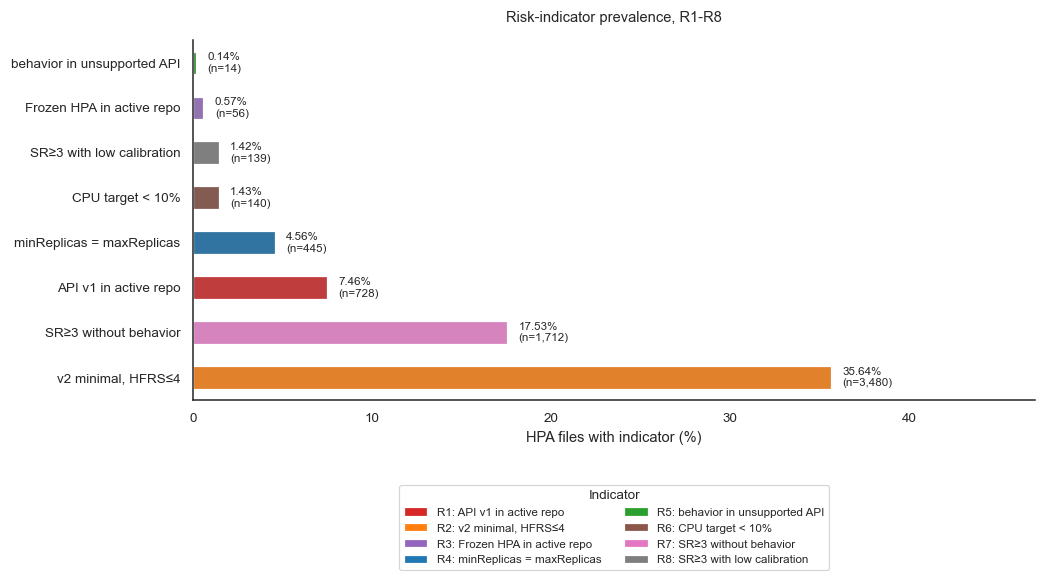

Salvo: plots/msr_analysis/fig24b_hfrs_by_risk_indicator_count.pdf


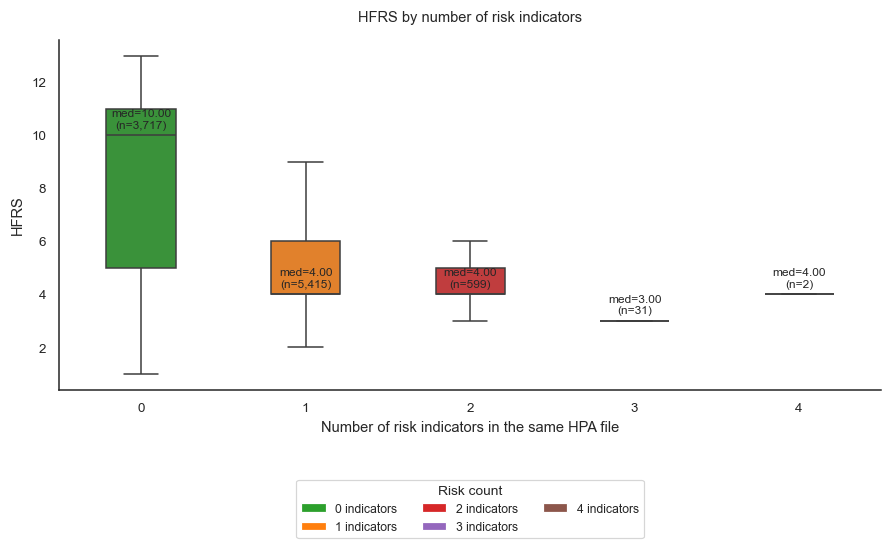

Salvo: plots/msr_analysis/fig24c_risk_indicator_cooccurrence_matrix.pdf


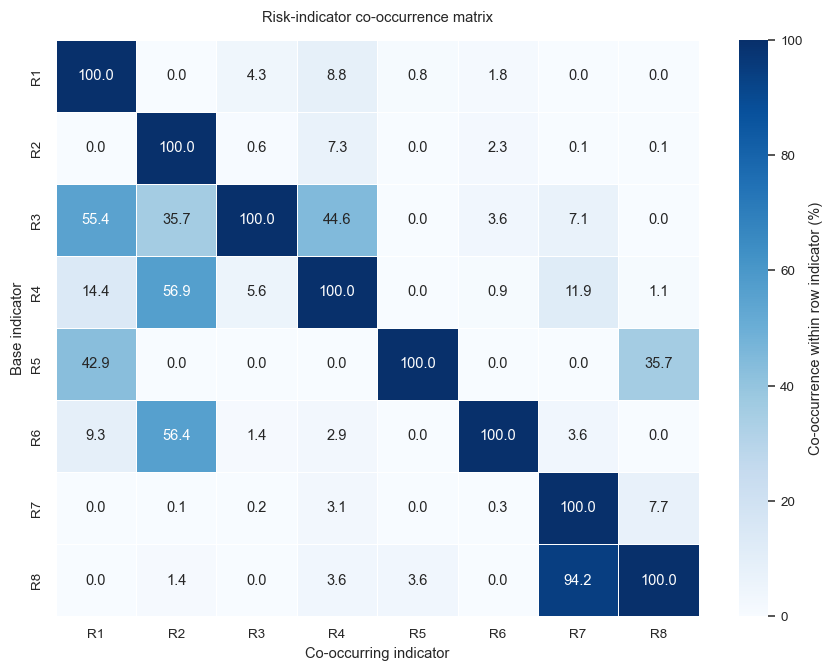

In [34]:
# ── Figure 24: risk indicators, split PDF figures ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
hfrs = pd.read_csv(DATA_DIR / 'hpa_hfrs.csv')
agg = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
p3c = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')

REF_DATE = pd.Timestamp('2026-03-07', tz='UTC')
V1_ALIASES = {'autoscaling/v1', 'v1', 'autoscaling/V1'}
INVALID_BEHAVIOR = {'autoscaling/v1', 'v1', 'autoscaling/V1', 'autoscaling/v2beta1'}

hfrs['repo_full_name'] = hfrs['Owner'] + '/' + hfrs['Project']
merged = hfrs.merge(
    agg[['repo_full_name', 'stargazers_count', 'is_active', 'is_outdated', 'pushed_at']],
    on='repo_full_name', how='left'
)
p3c['repo_full_name'] = p3c['Owner'] + '/' + p3c['Project']
merged = merged.merge(
    p3c[['Owner', 'Project', 'File Path', 'file_last_commit']],
    on=['Owner', 'Project', 'File Path'], how='left'
)

merged['repo_status'] = 'In-between'
merged.loc[merged['is_active'] == True, 'repo_status'] = 'Active'
merged.loc[merged['is_outdated'] == True, 'repo_status'] = 'Outdated'
merged['file_last_commit'] = pd.to_datetime(merged['file_last_commit'], utc=True, errors='coerce')
merged['hpa_file_age_y'] = (REF_DATE - merged['file_last_commit']).dt.days / 365.25

p4_pf = p4.groupby(['Owner', 'Project', 'File Path']).first().reset_index()
r4_df = p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]
r4_keys = set(zip(r4_df['Owner'], r4_df['Project'], r4_df['File Path']))
low_cpu = p4[
    (p4['Metric Name'].fillna('').str.lower() == 'cpu') &
    (p4['Target Kind'].fillna('') == 'Utilization') &
    (pd.to_numeric(p4['Target Value'], errors='coerce') < 10)
].copy()
r6_keys = set(zip(low_cpu['Owner'], low_cpu['Project'], low_cpu['File Path']))

merged['R1'] = merged['apiVersion'].isin(V1_ALIASES) & merged['repo_status'].eq('Active')
merged['R2'] = (~merged['apiVersion'].isin(V1_ALIASES)) & (merged['HFRS'] <= 4)
merged['R3'] = merged['repo_status'].eq('Active') & (merged['hpa_file_age_y'] > 2)
merged['R4'] = merged.apply(lambda r: (r['Owner'], r['Project'], r['File Path']) in r4_keys, axis=1)
merged['R5'] = merged['apiVersion'].isin(INVALID_BEHAVIOR) & (merged['CR1'] == 1)
merged['R6'] = merged.apply(lambda r: (r['Owner'], r['Project'], r['File Path']) in r6_keys, axis=1)
merged['R7'] = (merged['SR'] >= 3) & (merged['CR'] == 0)
merged['R8'] = (merged['SR'] >= 3) & (merged['AR'] <= 2)

risk_cols_all = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
risk_names = {
    'R1': 'API v1 in active repo',
    'R2': 'v2 minimal, HFRS≤4',
    'R3': 'Frozen HPA in active repo',
    'R4': 'minReplicas = maxReplicas',
    'R5': 'behavior in unsupported API',
    'R6': 'CPU target < 10%',
    'R7': 'SR≥3 without behavior',
    'R8': 'SR≥3 with low calibration',
}
RISK_COLORS = {
    'R1': '#d62728', 'R2': '#ff7f0e', 'R3': '#9467bd', 'R4': '#1f77b4',
    'R5': '#2ca02c', 'R6': '#8c564b', 'R7': '#e377c2', 'R8': '#7f7f7f'
}

merged['risk_count_all'] = merged[risk_cols_all].sum(axis=1)
summary_rows = []
print('=== TABELA RESUMO — todos os indicadores de risco ===')
for col in risk_cols_all:
    mask = merged[col]
    n = int(mask.sum())
    pct = n / len(merged) * 100
    mean_hfrs = merged.loc[mask, 'HFRS'].mean() if n else np.nan
    active_pct = merged.loc[mask, 'repo_status'].eq('Active').mean() * 100 if n else np.nan
    summary_rows.append({
        'Indicator': col,
        'Description': risk_names[col],
        'Files': n,
        'Share (%)': pct,
        'Mean HFRS': mean_hfrs,
        'Active (%)': active_pct,
    })
    print(f'  {col} — {risk_names[col]:<32} {n:>5,} ({pct:>5.2f}%) | mean HFRS={mean_hfrs:>5.2f} | active={active_pct:>5.2f}%')

summary_df = pd.DataFrame(summary_rows)
print('\nRisk-count distribution, R1-R8:')
print(merged['risk_count_all'].value_counts().sort_index().to_string())
print(f"\nFiles without any indicator: {(merged['risk_count_all'] == 0).sum():,} ({(merged['risk_count_all'] == 0).mean()*100:.2f}%)")
print(f"Files with two or more indicators: {(merged['risk_count_all'] >= 2).sum():,} ({(merged['risk_count_all'] >= 2).mean()*100:.2f}%)")

# Figure 24A, prevalence of all risk indicators
fig, ax = plt.subplots(figsize=(9.6, 5.6))
plot_df = summary_df.sort_values('Share (%)', ascending=True).copy()
sns.barplot(data=plot_df, y='Description', x='Share (%)', hue='Indicator', dodge=False,
            palette=RISK_COLORS, errorbar=None, ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
for patch in ax.patches:
    h = patch.get_height(); cy = patch.get_y() + h/2; new_h = h * 0.62
    patch.set_height(new_h); patch.set_y(cy - new_h/2)
max_x = max(plot_df['Share (%)'].max(), 1)
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(row._3 + max_x*0.018, i, f'{row._3:.2f}%\n(n={row.Files:,})', ha='left', va='center', fontsize=7.6)
ax.set_xlabel('HPA files with indicator (%)')
ax.set_ylabel('')
ax.set_title('Risk-indicator prevalence, R1-R8', pad=12)
ax.set_xlim(0, max_x * 1.32)
handles = [Patch(facecolor=RISK_COLORS[c], edgecolor='white', label=f'{c}: {risk_names[c]}') for c in risk_cols_all]
ax.legend(handles=handles, title='Indicator', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=7.6, title_fontsize=8.8)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig24a_risk_indicator_prevalence.pdf')
plt.show()

# Figure 24B, HFRS by number of risk indicators
risk_count_plot = merged[merged['risk_count_all'].between(0, 4)].copy()
risk_count_plot['Risk indicators'] = risk_count_plot['risk_count_all'].astype(int).astype(str)
fig, ax = plt.subplots(figsize=(8.2, 5.3))
palette_counts = {'0': '#2ca02c', '1': '#ff7f0e', '2': '#d62728', '3': '#9467bd', '4': '#8c564b'}
sns.boxplot(data=risk_count_plot, x='Risk indicators', y='HFRS', hue='Risk indicators',
            palette=palette_counts, legend=False, showfliers=False, width=0.42, ax=ax)
for i, count_label in enumerate(['0', '1', '2', '3', '4']):
    vals = risk_count_plot.loc[risk_count_plot['Risk indicators'].eq(count_label), 'HFRS']
    if len(vals):
        ax.text(i, vals.median() + 0.20, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=7.8)
ax.set_xlabel('Number of risk indicators in the same HPA file')
ax.set_ylabel('HFRS')
ax.set_title('HFRS by number of risk indicators', pad=12)
ax.legend(handles=[Patch(facecolor=palette_counts[k], edgecolor='white', label=f'{k} indicators') for k in palette_counts],
          title='Risk count', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig24b_hfrs_by_risk_indicator_count.pdf')
plt.show()

# Figure 24C, co-occurrence among indicators
co = pd.DataFrame(index=risk_cols_all, columns=risk_cols_all, dtype=float)
for r1 in risk_cols_all:
    base = merged[r1].sum()
    for r2 in risk_cols_all:
        co.loc[r1, r2] = ((merged[r1]) & (merged[r2])).sum() / base * 100 if base else 0
fig, ax = plt.subplots(figsize=(8.0, 6.2))
sns.heatmap(co, annot=True, fmt='.1f', cmap='Blues', linewidths=0.35, linecolor='white',
            cbar_kws={'label': 'Co-occurrence within row indicator (%)'}, ax=ax)
ax.set_xlabel('Co-occurring indicator')
ax.set_ylabel('Base indicator')
ax.set_title('Risk-indicator co-occurrence matrix', pad=12)
plt.tight_layout()
savefig('fig24c_risk_indicator_cooccurrence_matrix.pdf')
plt.show()


## 12. Sensibilidade da distribuição do HFRS por cenário de filtragem

A análise de sensibilidade da Seção 10 testou a robustez da distribuição de versões de API sob filtros progressivos. Esta seção aplica a mesma lógica ao HFRS, verificando se os resultados de riqueza de configuração mudam substancialmente quando o corpus é filtrado por atividade, idade do arquivo HPA, popularidade ou ano de commit.

**Resultado observado:**

| Cenário | n | HFRS médio | HFRS mediana | Basic (%) | Rich+ (%) |
|---------|---:|-----------:|-------------:|----------:|----------:|
| All data | 9.764 | 5,94 | 4,00 | 55,65% | 20,95% |
| Active | 7.021 | 6,66 | 6,00 | 45,92% | 28,10% |
| HPA ≤ 2 anos | 7.090 | 6,65 | 6,00 | 46,05% | 27,86% |
| Stars > 0 | 2.720 | 5,91 | 4,00 | 55,04% | 20,26% |
| Stars ≥ 10 | 600 | 5,10 | 4,00 | 66,67% | 12,50% |
| Commit year ≥ 2024 | 7.286 | 6,59 | 6,00 | 46,95% | 27,22% |

**Interpretação:**

O filtro por atividade e o filtro por idade do arquivo HPA produzem resultados quase equivalentes: ambos elevam a mediana do HFRS de 4 para 6 e reduzem a fração Basic para cerca de 46%. Isso indica que configurações HPA em repositórios mantidos ou modificadas recentemente tendem a usar um conjunto mais amplo de capacidades.

O filtro `Stars ≥ 10` segue na direção oposta: reduz o HFRS médio para 5,10 e eleva Basic para 66,67%. Assim, popularidade do repositório não implica maior riqueza de configuração HPA. Esse resultado é coerente com a análise de maturidade do repositório, em que estrelas e HFRS apresentam associação muito fraca.

**Conclusão:** as conclusões sobre maior riqueza em configurações recentes e ativas são robustas, mas a popularidade medida por estrelas não deve ser usada como proxy de qualidade ou sofisticação da configuração HPA.


   Scenario  Files  Mean HFRS  Median HFRS  Basic (%)  Rich+ (%)
   All data   9764       5.94          4.0      55.65      20.95
     Active   7021       6.66          6.0      45.92      28.10
   HPA ≤2yr   7090       6.65          6.0      46.05      27.86
  Stars > 0   2720       5.91          4.0      55.04      20.26
 Stars ≥ 10    600       5.10          4.0      66.67      12.50
Year ≥ 2024   7286       6.59          6.0      46.95      27.22
Salvo: plots/msr_analysis/fig18a_mean_hfrs_by_filtering_scenario.pdf


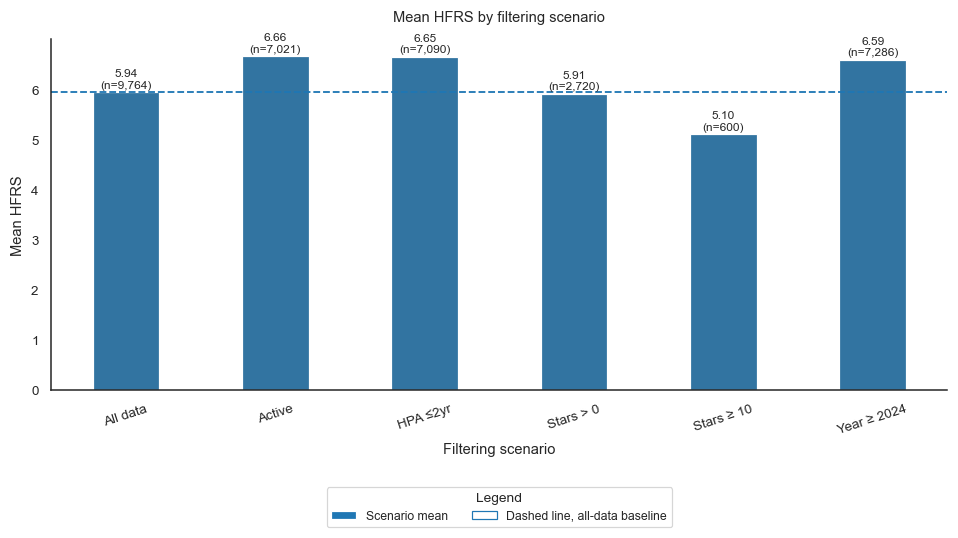

Salvo: plots/msr_analysis/fig18b_richness_class_by_filtering_scenario.pdf


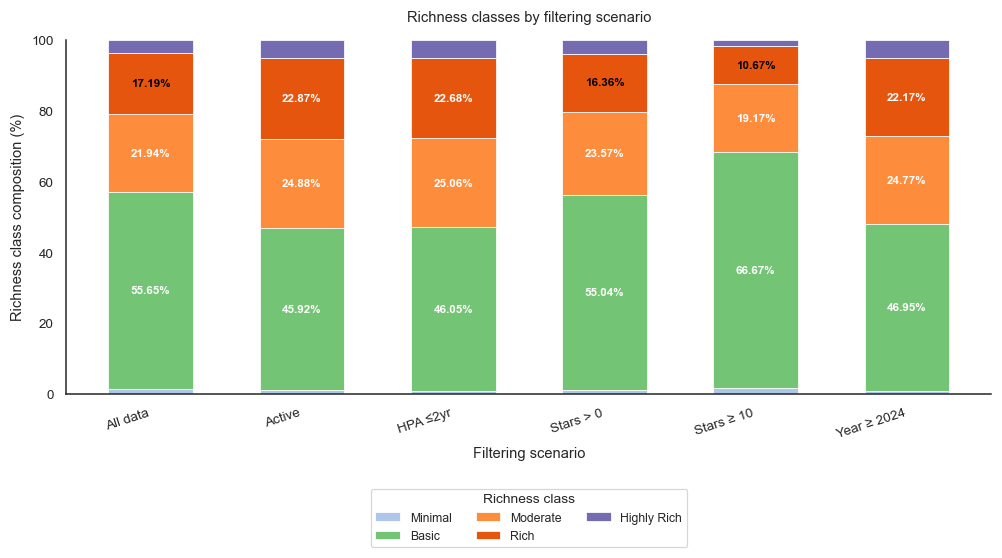

In [35]:
# ── Figure 18: HFRS sensitivity by filtering scenario, split PDF figures ──────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full.exists():
    print('hpa_hfrs_full.csv not found.')
else:
    hf = pd.read_csv(_hfrs_full)
    hf['commit_year'] = pd.to_numeric(hf['commit_year'], errors='coerce')
    hf['stargazers_count'] = pd.to_numeric(hf['stargazers_count'], errors='coerce')

    RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
    RICHNESS_COLORS = {
        'Minimal': '#aec7e8', 'Basic': '#74c476', 'Moderate': '#fd8d3c',
        'Rich': '#e6550d', 'Highly Rich': '#756bb1'
    }

    scenarios = {
        'All data': hf,
        'Active': hf[hf['repo_status'] == 'Active'],
        'HPA ≤2yr': hf[hf['hpa_file_age_y'] <= 2],
        'Stars > 0': hf[hf['stargazers_count'] > 0],
        'Stars ≥ 10': hf[hf['stargazers_count'] >= 10],
        'Year ≥ 2024': hf[hf['commit_year'] >= 2024],
    }

    rows = []
    for name, df in scenarios.items():
        df_c = df.dropna(subset=['HFRS']).copy()
        rc = df_c['richness_class'].value_counts()
        rows.append({
            'Scenario': name,
            'Files': len(df_c),
            'Mean HFRS': df_c['HFRS'].mean(),
            'Median HFRS': df_c['HFRS'].median(),
            'Basic (%)': rc.get('Basic', 0) / len(df_c) * 100 if len(df_c) else 0,
            'Rich+ (%)': (rc.get('Rich', 0) + rc.get('Highly Rich', 0)) / len(df_c) * 100 if len(df_c) else 0,
        })
    tbl = pd.DataFrame(rows)
    print(tbl.round(2).to_string(index=False))

    # Figure 18A
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    sns.barplot(data=tbl, x='Scenario', y='Mean HFRS', color='#1f77b4', errorbar=None, ax=ax)
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w/2; new_w = w * 0.56
        patch.set_width(new_w); patch.set_x(cx - new_w/2)
    baseline = float(tbl.loc[tbl['Scenario'].eq('All data'), 'Mean HFRS'].iloc[0])
    ax.axhline(baseline, color='#1f77b4', linestyle='--', linewidth=1.2)
    for i, row in enumerate(tbl.itertuples(index=False)):
        ax.text(i, row[2] + 0.05, f'{row[2]:.2f}\n(n={row[1]:,})', ha='center', va='bottom', fontsize=7.8)
    ax.set_xlabel('Filtering scenario')
    ax.set_ylabel('Mean HFRS')
    ax.set_title('Mean HFRS by filtering scenario', pad=12)
    ax.tick_params(axis='x', rotation=18)
    ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='Scenario mean'),
                       Patch(facecolor='none', edgecolor='#1f77b4', label='Dashed line, all-data baseline')],
              title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=2, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig18a_mean_hfrs_by_filtering_scenario.pdf')
    plt.show()

    # Figure 18B
    fig, ax = plt.subplots(figsize=(9.2, 5.4))
    x = np.arange(len(tbl))
    bottoms = np.zeros(len(tbl))
    for cls in RICHNESS_ORDER:
        vals = []
        for name in tbl['Scenario']:
            df_c = scenarios[name].dropna(subset=['HFRS'])
            vals.append((df_c['richness_class'] == cls).mean() * 100 if len(df_c) else 0)
        ax.bar(x, vals, bottom=bottoms, color=RICHNESS_COLORS[cls], edgecolor='white', linewidth=0.5, width=0.56, label=cls)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 8:
                ax.text(xi, b + v/2, f'{v:.2f}%', ha='center', va='center', fontsize=7.6, color='white' if v >= 18 else 'black', fontweight='bold')
        bottoms += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels(tbl['Scenario'], rotation=18, ha='right')
    ax.set_xlabel('Filtering scenario')
    ax.set_ylabel('Richness class composition (%)')
    ax.set_ylim(0, 100)
    ax.set_title('Richness classes by filtering scenario', pad=12)
    ax.legend(title='Richness class', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig18b_richness_class_by_filtering_scenario.pdf')
    plt.show()


## 13. Maturidade do repositório × HFRS: popularidade e idade

Esta seção testa se repositórios mais populares ou mais antigos apresentam configurações HPA com maior riqueza de features. A análise complementa três comparações anteriores: toy vs. non-toy (Seção 3), active vs. outdated (Seção 7) e sensibilidade por filtros de corpus (Seção 10 e Seção 12).

### Popularidade, estrelas × HFRS

A correlação entre `log(stars + 1)` e HFRS é muito fraca e negativa, com `rho = -0,029` e `p = 4,11e-03`. O p-valor indica significância estatística pelo tamanho do corpus, mas o efeito é praticamente nulo. Na prática, estrelas não explicam a riqueza da configuração HPA.

### Idade do repositório × HFRS

A idade do repositório apresenta associação negativa mais forte com HFRS, `rho = -0,505`. Repositórios mais recentes tendem a concentrar configurações mais ricas, em parte porque foram criados depois da consolidação de `autoscaling/v2` e já partiram de uma API com mais capacidades disponíveis.

**Interpretação:** maturidade medida por idade ou popularidade não deve ser confundida com sofisticação de configuração. No corpus analisado, a recência técnica parece mais relevante do que a popularidade social do repositório.


Spearman log(stars+1) × HFRS: rho=-0.029, p=4.11e-03
Spearman repo_age_y × HFRS: rho=-0.505, p=0.00e+00
Salvo: plots/msr_analysis/fig19a_hfrs_by_stars_category.pdf


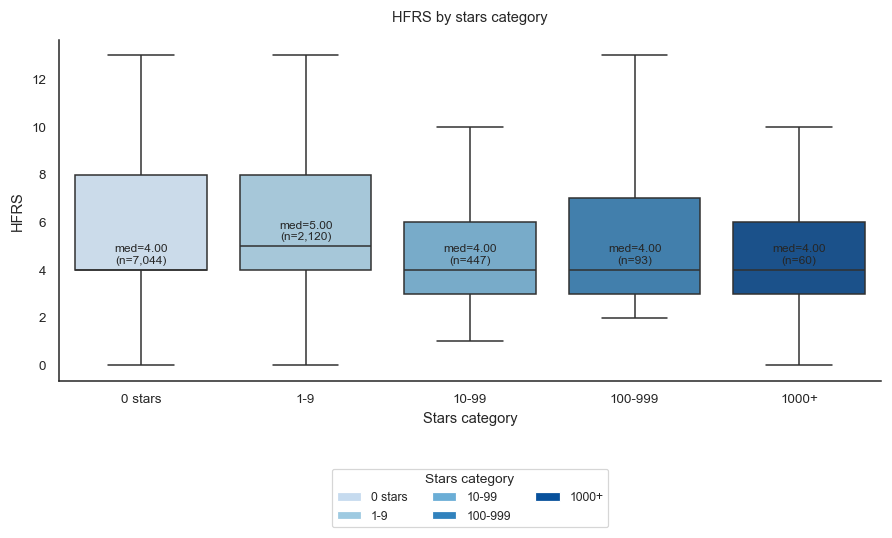

Salvo: plots/msr_analysis/fig19b_hfrs_by_repository_age_category.pdf


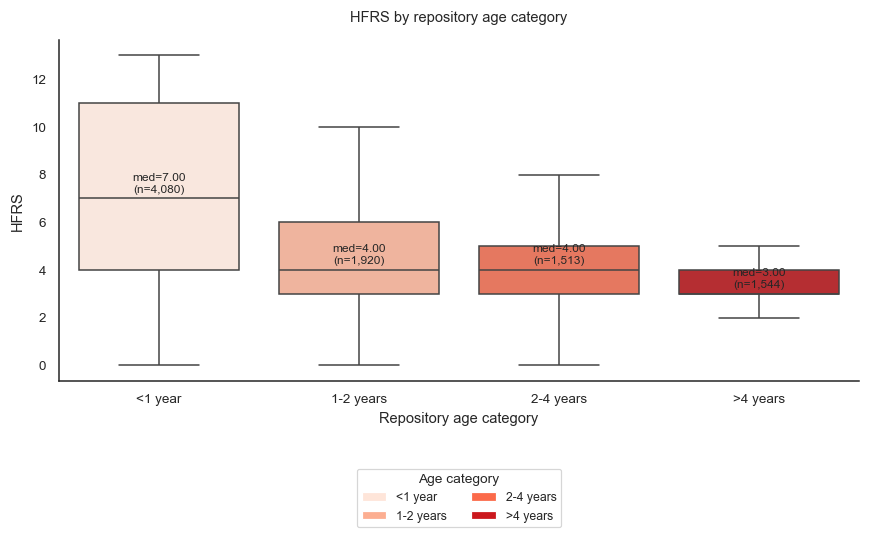

In [36]:
# ── Figure 19: repository maturity versus HFRS, split PDF figures ────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full.exists():
    print('hpa_hfrs_full.csv not found.')
else:
    hf = pd.read_csv(_hfrs_full)
    hf['stargazers_count'] = pd.to_numeric(hf['stargazers_count'], errors='coerce')
    hf['repo_age_y'] = pd.to_numeric(hf['repo_age_y'], errors='coerce')

    valid = hf.dropna(subset=['HFRS', 'stargazers_count', 'repo_age_y']).copy()
    r_stars, p_stars = stats.spearmanr(np.log1p(valid['stargazers_count']), valid['HFRS'])
    r_age, p_age = stats.spearmanr(valid['repo_age_y'], valid['HFRS'])
    print(f'Spearman log(stars+1) × HFRS: rho={r_stars:.3f}, p={p_stars:.2e}')
    print(f'Spearman repo_age_y × HFRS: rho={r_age:.3f}, p={p_age:.2e}')

    hf['stars_cat'] = pd.cut(hf['stargazers_count'].fillna(0), bins=[-1, 0, 9, 99, 999, np.inf], labels=['0 stars', '1-9', '10-99', '100-999', '1000+'])
    hf['age_cat'] = pd.cut(hf['repo_age_y'].fillna(0), bins=[0, 1, 2, 4, np.inf], labels=['<1 year', '1-2 years', '2-4 years', '>4 years'])
    STARS_ORDER = ['0 stars', '1-9', '10-99', '100-999', '1000+']
    AGE_ORDER = ['<1 year', '1-2 years', '2-4 years', '>4 years']
    STARS_COLORS = ['#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c']
    AGE_COLORS = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']

    # Figure 19A
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    plot_df = hf.dropna(subset=['stars_cat', 'HFRS']).copy()
    sns.boxplot(data=plot_df, x='stars_cat', y='HFRS', order=STARS_ORDER, hue='stars_cat', palette=dict(zip(STARS_ORDER, STARS_COLORS)), legend=False, showfliers=False, ax=ax)
    for i, cat in enumerate(STARS_ORDER):
        vals = plot_df.loc[plot_df['stars_cat'].astype(str).eq(cat), 'HFRS']
        if len(vals):
            ax.text(i, vals.median() + 0.18, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=7.8)
    ax.set_xlabel('Stars category')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS by stars category', pad=12)
    ax.legend(handles=[Patch(facecolor=c, edgecolor='white', label=l) for l, c in zip(STARS_ORDER, STARS_COLORS)], title='Stars category', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig19a_hfrs_by_stars_category.pdf')
    plt.show()

    # Figure 19B
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    plot_df2 = hf.dropna(subset=['age_cat', 'HFRS']).copy()
    sns.boxplot(data=plot_df2, x='age_cat', y='HFRS', order=AGE_ORDER, hue='age_cat', palette=dict(zip(AGE_ORDER, AGE_COLORS)), legend=False, showfliers=False, ax=ax)
    for i, cat in enumerate(AGE_ORDER):
        vals = plot_df2.loc[plot_df2['age_cat'].astype(str).eq(cat), 'HFRS']
        if len(vals):
            ax.text(i, vals.median() + 0.18, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=7.8)
    ax.set_xlabel('Repository age category')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS by repository age category', pad=12)
    ax.legend(handles=[Patch(facecolor=c, edgecolor='white', label=l) for l, c in zip(AGE_ORDER, AGE_COLORS)], title='Age category', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig19b_hfrs_by_repository_age_category.pdf')
    plt.show()


---

## 14. Indicadores de risco × classe de riqueza e status de atividade

Esta seção cruza os indicadores de risco (R1–R8) com as classes do HFRS e o status de atividade dos repositórios. A análise responde à subpergunta da RQ4: os indicadores de risco são mais concentrados em configurações de baixa riqueza ou em repositórios inativos?

**% de arquivos com cada indicador por classe de riqueza:**

| Indicador | Minimal | Basic | Moderate | Rich | Highly Rich |
|-----------|---------|-------|----------|------|-------------|
| R1 (API v1 ativa) | 23,00% | 13,70% | 0,00% | 0,10% | 0,00% |
| R2 (v2 minimal) | 38,50% | 62,20% | 0,00% | 0,00% | 0,00% |
| R3 (HPA congelado) | 3,70% | 0,70% | 0,40% | 0,00% | 0,00% |
| R4 (min=max) | 5,20% | 4,80% | 2,70% | 1,00% | 0,80% |
| R5 (behavior inválido) | 0,00% | 0,10% | 0,40% | 0,10% | 0,00% |
| R7 (SR≥3 sem CR) | 0,00% | 1,90% | 72,30% | 4,00% | 0,00% |
| R8 (SR≥3, AR≤2) | 0,00% | 1,90% | 1,10% | 0,20% | 0,00% |

**Padrões relevantes:**

R1 e R2 concentram-se nas classes Minimal e Basic por construção: R1 (v1 ativa) implica SR1=0, que puxa o HFRS para baixo; R2 (v2 minimal) é definido como HFRS ≤ 4, que é a classe Basic por definição. A concentração não é trivial; é uma confirmação de consistência interna do modelo.

R7 (SR ≥ 3 sem behavior) aparece em 72,30% dos arquivos na classe Moderate. o arcótipo "Signal-rich sem controle" é característico dessa faixa intermediária: os operadores investiram em diversificar sinais mas não adotaram `spec.behavior`. Para as classes Rich e Highly Rich, esse padrão cai para 4,00% e 0,00%, pois nessas classes CR tende a ser alto.

R4 (min=max, HPA inoperante) é o único indicador distribuído por todas as classes, incluindo Rich (1,00%) e Highly Rich (0,80%). HPAs inoperantes existem mesmo em configurações com alta riqueza de features, possivelmente como configurações de teste ou de contenção de escalonamento.

**% com qualquer indicador de risco por classe:**

| Classe | % com qualquer risco |
|--------|---------------------|
| Minimal | 65,20% |
| Basic | 78,20% |
| Moderate | 73,40% |
| Rich | 5,30% |
| Highly Rich | 0,80% |

A queda abrupta entre Moderate (73,40%) e Rich (5,30%) é o resultado mais relevante: configurações acima de HFRS 8 raramente apresentam indicadores de risco detectáveis. Isso valida a utilidade do HFRS como proxy para avaliar se uma configuração está dentro de padrões de uso recomendados.


## 15. HPAs ricos em repositórios ativos: o padrão "richer but poorly maintained"

Esta seção testa uma hipótese específica de RQ4: configurações HPA mais ricas poderiam ter sido criadas com alto esforço inicial e depois deixadas sem manutenção. O foco é verificar se arquivos Rich ou Highly Rich em repositórios ativos apresentam idade elevada do último commit HPA.

### Hipótese e resultado

**Hipótese:** HPAs com maior riqueza de features poderiam estar mais sujeitos ao padrão "richer but poorly maintained", isto é, configurações elaboradas que não são revisitadas ao longo do tempo.

**Resultado observado:** a hipótese não se confirma no corpus.

| Classe | n | mediana de `hpa_file_age_y` | > 1 ano | > 2 anos |
|--------|---:|----------------------------:|--------:|---------:|
| Minimal | 77 | 1,20 anos | 61,04% | 6,49% |
| Basic | 3.224 | 0,79 anos | 40,69% | 1,43% |
| Moderate | 1.747 | 0,46 anos | 21,41% | 0,23% |
| Rich | 1.606 | 0,25 anos | 4,67% | 0,06% |
| Highly Rich | 367 | 0,36 anos | 0,82% | 0,00% |

O teste Mann-Whitney indica que arquivos Basic em repositórios ativos têm idade de HPA sistematicamente maior do que arquivos Rich ou Highly Rich (`p = 1,17e-182`). A correlação de Spearman entre `hpa_file_age_y` e HFRS também é negativa (`rho = -0,381`, `p = 7,35e-241`), indicando que HPAs mais ricos tendem a ser mais recentes.

### Interpretação

O resultado contraria a hipótese inicial. No corpus, configurações mais ricas não aparecem como artefatos antigos abandonados; ao contrário, elas estão associadas a manutenção mais recente. O padrão de risco ligado à baixa manutenção concentra-se mais nas classes Minimal e Basic do que nas classes Rich e Highly Rich.


Mann-Whitney hpa_file_age_y: Basic > Rich+Highly Rich: U=4692062, p=1.17e-182
Spearman hpa_file_age_y × HFRS (active): rho=-0.381, p=7.35e-241
  Minimal     : median=1.20yr  >1yr=61.04%  >2yr=6.49%  n=77
  Basic       : median=0.79yr  >1yr=40.69%  >2yr=1.43%  n=3,224
  Moderate    : median=0.46yr  >1yr=21.41%  >2yr=0.23%  n=1,747
  Rich        : median=0.25yr  >1yr=4.67%  >2yr=0.06%  n=1,606
  Highly Rich : median=0.36yr  >1yr=0.82%  >2yr=0.00%  n=367
Salvo: plots/msr_analysis/fig20a_hpa_file_age_by_richness_active.pdf


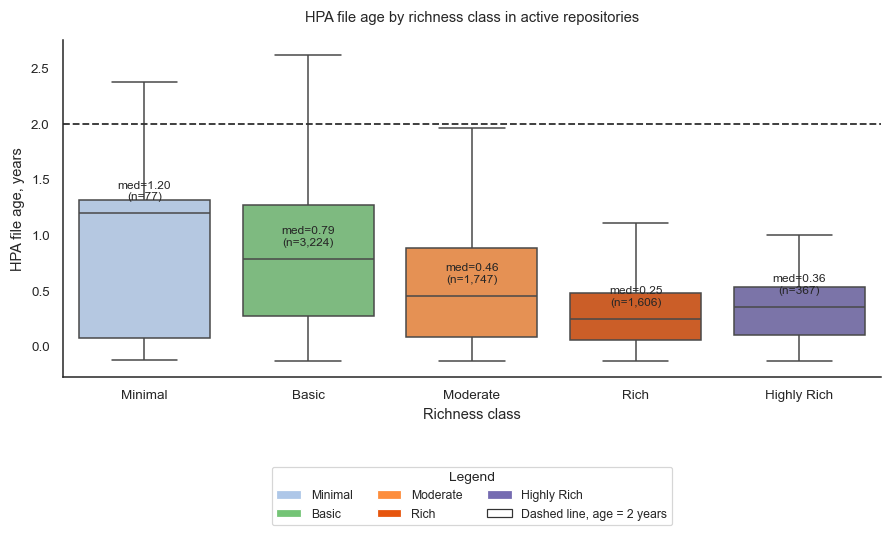

Salvo: plots/msr_analysis/fig20b_older_hpa_files_by_richness_active.pdf


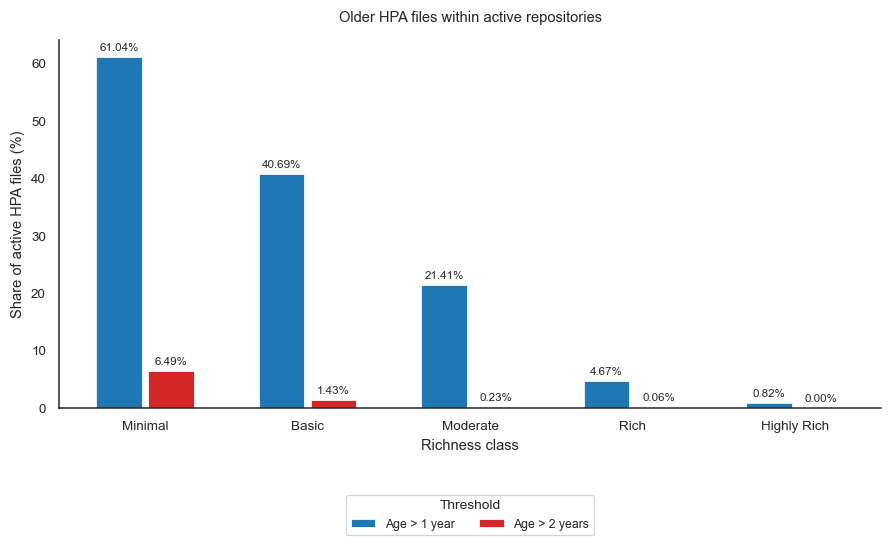

In [37]:
# ── Figure 20: richer but poorly maintained, split PDF figures ───────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
RICHNESS_COLORS = {'Minimal': '#aec7e8', 'Basic': '#74c476', 'Moderate': '#fd8d3c', 'Rich': '#e6550d', 'Highly Rich': '#756bb1'}
active = hf[hf['repo_status'] == 'Active'].dropna(subset=['hpa_file_age_y', 'HFRS']).copy()

b_ages = active[active['richness_class'] == 'Basic']['hpa_file_age_y']
r_ages = active[active['HFRS'] >= 9]['hpa_file_age_y']
u, p = stats.mannwhitneyu(b_ages, r_ages, alternative='greater')
rho_sp, p_sp = stats.spearmanr(active['hpa_file_age_y'], active['HFRS'])
print(f'Mann-Whitney hpa_file_age_y: Basic > Rich+Highly Rich: U={u:.0f}, p={p:.2e}')
print(f'Spearman hpa_file_age_y × HFRS (active): rho={rho_sp:.3f}, p={p_sp:.2e}')
for cls in RICHNESS_ORDER:
    sub = active[active['richness_class'] == cls]['hpa_file_age_y']
    if len(sub):
        print(f'  {cls:<12}: median={sub.median():.2f}yr  >1yr={(sub > 1).mean()*100:.2f}%  >2yr={(sub > 2).mean()*100:.2f}%  n={len(sub):,}')

# Figure 20A
fig, ax = plt.subplots(figsize=(8.2, 5.2))
plot_df = active.copy()
sns.boxplot(data=plot_df, x='richness_class', y='hpa_file_age_y', order=RICHNESS_ORDER, hue='richness_class', palette=RICHNESS_COLORS, legend=False, showfliers=False, ax=ax)
for i, cls in enumerate(RICHNESS_ORDER):
    vals = plot_df.loc[plot_df['richness_class'].eq(cls), 'hpa_file_age_y']
    if len(vals):
        ax.text(i, vals.median() + 0.10, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=7.8)
ax.axhline(2, color='#333333', linestyle='--', linewidth=1.2)
ax.set_xlabel('Richness class')
ax.set_ylabel('HPA file age, years')
ax.set_title('HPA file age by richness class in active repositories', pad=12)
handles=[Patch(facecolor=RICHNESS_COLORS[k], edgecolor='white', label=k) for k in RICHNESS_ORDER]
handles.append(Patch(facecolor='none', edgecolor='#333333', label='Dashed line, age = 2 years'))
ax.legend(handles=handles, title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig20a_hpa_file_age_by_richness_active.pdf')
plt.show()

# Figure 20B
thr_df = []
for cls in RICHNESS_ORDER:
    vals = active.loc[active['richness_class'].eq(cls), 'hpa_file_age_y'].dropna()
    thr_df.append({'Richness class': cls, 'Share > 1 year (%)': (vals > 1).mean()*100 if len(vals) else 0, 'Share > 2 years (%)': (vals > 2).mean()*100 if len(vals) else 0, 'n': len(vals)})
thr_df = pd.DataFrame(thr_df)
fig, ax = plt.subplots(figsize=(8.2, 5.2))
x = np.arange(len(thr_df))
ax.bar(x - 0.16, thr_df['Share > 1 year (%)'], width=0.28, color='#1f77b4', edgecolor='white', linewidth=0.5, label='Age > 1 year')
ax.bar(x + 0.16, thr_df['Share > 2 years (%)'], width=0.28, color='#d62728', edgecolor='white', linewidth=0.5, label='Age > 2 years')
for xi, row in enumerate(thr_df.itertuples(index=False)):
    ax.text(xi - 0.16, row[1] + 0.8, f'{row[1]:.2f}%', ha='center', va='bottom', fontsize=7.6)
    ax.text(xi + 0.16, row[2] + 0.8, f'{row[2]:.2f}%', ha='center', va='bottom', fontsize=7.6)
ax.set_xticks(x)
ax.set_xticklabels(thr_df['Richness class'])
ax.set_xlabel('Richness class')
ax.set_ylabel('Share of active HPA files (%)')
ax.set_title('Older HPA files within active repositories', pad=12)
ax.legend(title='Threshold', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig20b_older_hpa_files_by_richness_active.pdf')
plt.show()


                   R1     R2    R3     R4    R5     R7    R8
richness_class                                              
Minimal         21.13  44.37  3.52  50.00  0.00   0.00  0.00
Basic           12.81  62.88  0.85   5.41  0.09   2.08  2.08
Moderate         0.00   0.00  0.19   2.89  0.33  71.24  1.12
Rich             0.12   0.00  0.06   1.01  0.12   4.35  0.12
Highly Rich      0.00   0.00  0.00   0.27  0.00   0.00  0.00
richness_class
Minimal        78.87
Basic          78.25
Moderate       72.27
Rich            5.54
Highly Rich     0.27
Name: any_risk, dtype: float64
Salvo: plots/msr_analysis/fig21a_risk_indicators_by_richness_class.pdf


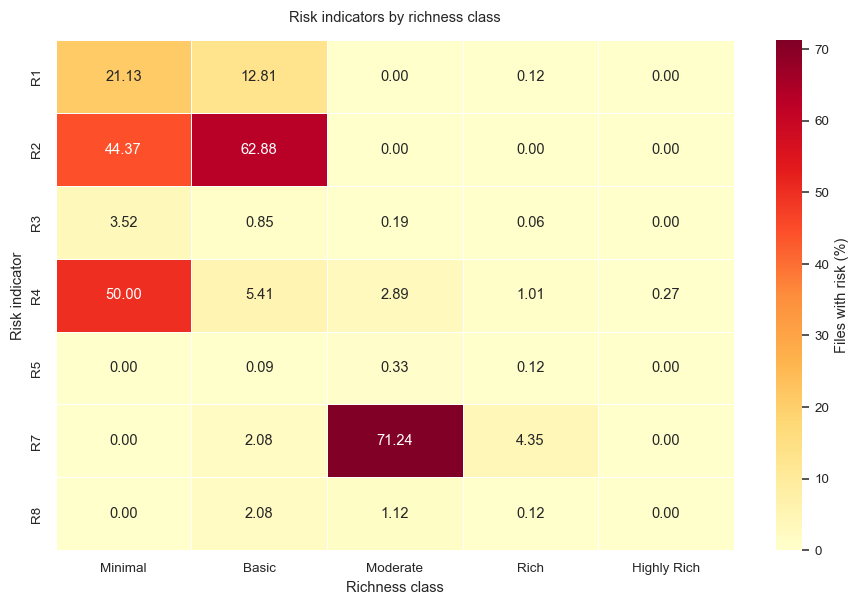

Salvo: plots/msr_analysis/fig21b_any_risk_by_richness_and_status.pdf


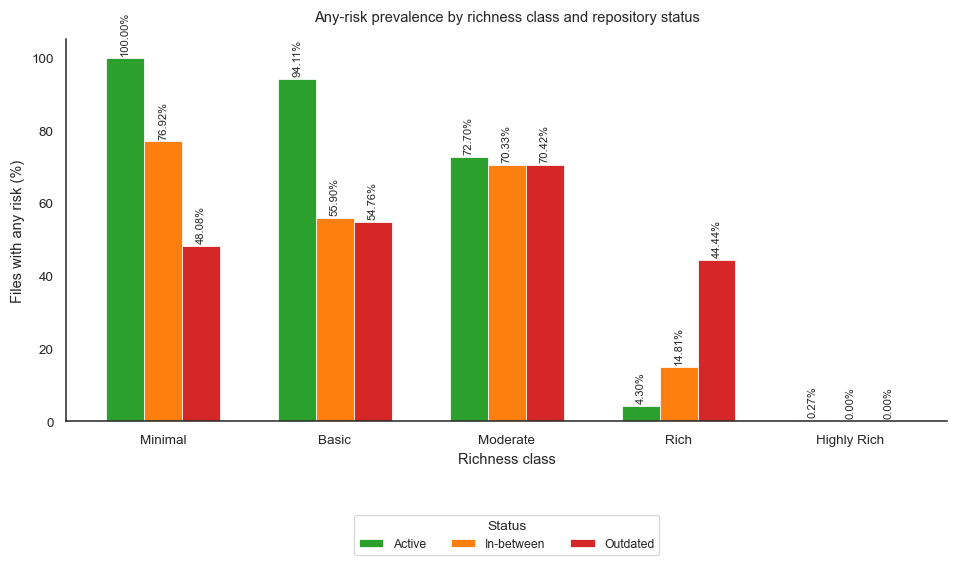

In [41]:
# ── Figure 21: risk indicators by richness and activity, split PDF figures ────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
V1_ALIASES = {'autoscaling/v1', 'v1', 'autoscaling/V1'}
INVALID_BEHAVIOR = {'autoscaling/v1', 'v1', 'autoscaling/V1', 'autoscaling/v2beta1'}
p4_pf = p4.groupby(['Owner', 'Project', 'File Path']).first().reset_index()
r4_keys = set(zip(
    p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]['Owner'],
    p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]['Project'],
    p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]['File Path']))

hf['R1'] = (hf['apiVersion'].isin(V1_ALIASES)) & (hf['repo_status'] == 'Active')
hf['R2'] = (~hf['apiVersion'].isin(V1_ALIASES)) & (hf['HFRS'] <= 4)
hf['R3'] = (hf['repo_status'] == 'Active') & (hf['hpa_file_age_y'] > 2)
hf['R4'] = hf.apply(lambda r: (r['Owner'], r['Project'], r['File Path']) in r4_keys, axis=1)
hf['R5'] = (hf['apiVersion'].isin(INVALID_BEHAVIOR)) & (hf['CR1'] == 1)
hf['R7'] = (hf['SR'] >= 3) & (hf['CR'] == 0)
hf['R8'] = (hf['SR'] >= 3) & (hf['AR'] <= 2)
risk_cols = ['R1', 'R2', 'R3', 'R4', 'R5', 'R7', 'R8']
RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
STATUS_ORDER = ['Active', 'In-between', 'Outdated']
STATUS_COLORS = {'Active': '#2ca02c', 'In-between': '#ff7f0e', 'Outdated': '#d62728'}
hf['any_risk'] = hf[risk_cols].any(axis=1)

risk_by_class = pd.DataFrame({r: hf.groupby('richness_class')[r].mean().reindex(RICHNESS_ORDER)*100 for r in risk_cols})
print(risk_by_class.round(2))
print((hf.groupby('richness_class')['any_risk'].mean().reindex(RICHNESS_ORDER)*100).round(2))

# Figure 21A
fig, ax = plt.subplots(figsize=(8.4, 5.6))
sns.heatmap(risk_by_class.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Files with risk (%)'}, linewidths=0.35, linecolor='white', ax=ax)
ax.set_xlabel('Richness class')
ax.set_ylabel('Risk indicator')
ax.set_title('Risk indicators by richness class', pad=12)
plt.tight_layout()
savefig('fig21a_risk_indicators_by_richness_class.pdf')
plt.show()

# Figure 21B
fig, ax = plt.subplots(figsize=(8.8, 5.4))
x = np.arange(len(RICHNESS_ORDER))
width = 0.22
for k, status in enumerate(STATUS_ORDER):
    vals = []
    for rc in RICHNESS_ORDER:
        sub = hf[(hf['richness_class'] == rc) & (hf['repo_status'] == status)]
        vals.append(sub['any_risk'].mean()*100 if len(sub) else 0)
    ax.bar(x + (k-1)*width, vals, width=width, color=STATUS_COLORS[status], edgecolor='white', linewidth=0.5, label=status)
    for xi, val in enumerate(vals):
        ax.text(xi + (k-1)*width, val + 0.8, f'{val:.2f}%', ha='center', va='bottom', fontsize=7.3, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(RICHNESS_ORDER)
ax.set_xlabel('Richness class')
ax.set_ylabel('Files with any risk (%)')
ax.set_title('Any-risk prevalence by richness class and repository status', pad=12)
ax.legend(title='Status', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.23), ncol=3, fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig21b_any_risk_by_richness_and_status.pdf')
plt.show()


## 16. Análise de commit timeline: HPA-touch frequency (Phase 6)

A Phase 6 coletou histórico de commits de uma amostra estratificada de repositórios, distinguindo dois tipos de eventos: commits gerais do repositório (`repo`) e commits que tocaram especificamente um arquivo HPA (`hpa_file`). Esta seção usa esses dados para analisar a frequência de manutenção direta dos arquivos HPA.

**Cobertura da amostra:** 169 repositórios únicos com commits de arquivo HPA, 261 eventos `hpa_file` e 8.665 eventos `repo`.

**HPA-touch frequency:** número de commits que tocaram o arquivo HPA no período coletado.

| Estatística | Valor |
|-------------|------:|
| Mediana de touches por repositório | 1,00 |
| Média | 1,54 |
| Máximo | 11 |
| Repositórios com apenas 1 touch | 76,92% |

A mediana de 1 toque por repositório indica que, na maior parte da amostra, o arquivo HPA foi modificado poucas vezes. A correlação entre `hpa_touch_count` e HFRS é fraca e não significativa (`rho = 0,078`, `p = 0,311`), portanto a frequência de commits HPA não explica diretamente a riqueza de features da configuração.


Spearman hpa_touch_count × HFRS: rho=0.078, p=0.311
count    169.00
mean       1.54
std        1.41
min        1.00
25%        1.00
50%        1.00
75%        1.00
max       11.00
Name: hpa_touch_count, dtype: float64
Salvo: plots/msr_analysis/fig22a_hpa_touch_frequency_distribution.pdf


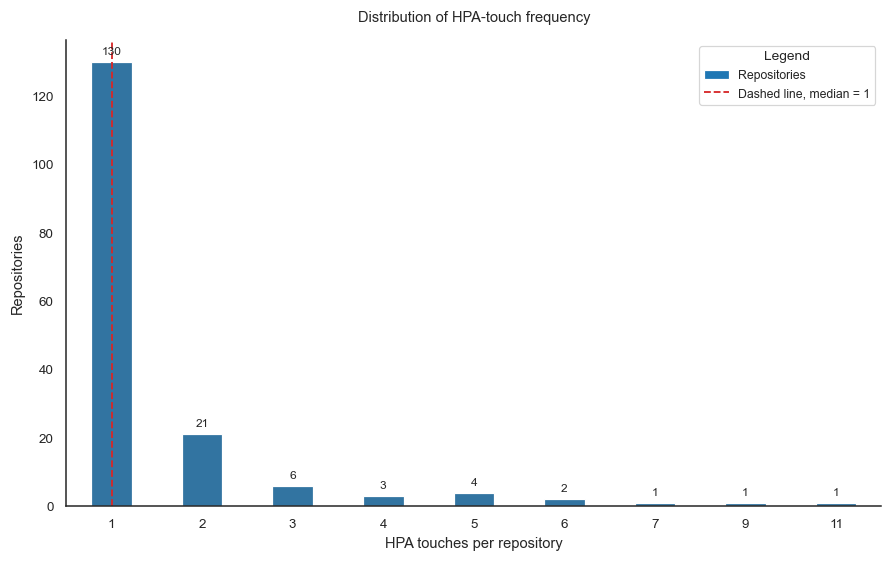

Salvo: plots/msr_analysis/fig22b_repository_vs_hpa_commits_by_year.pdf


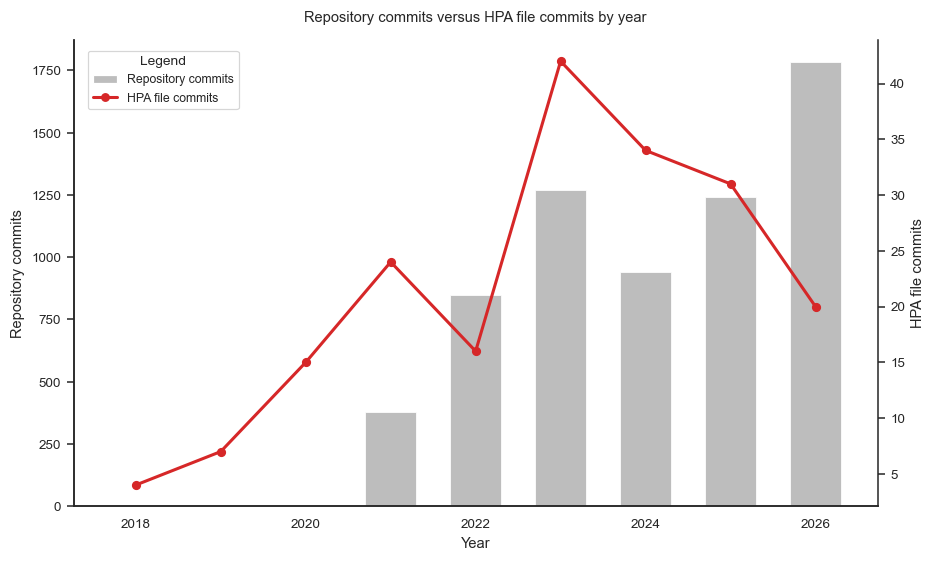

In [42]:
# ── Figure 22: HPA-touch frequency and yearly evolution, split PDF figures ────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_p6_path = DATA_DIR / 'phase6_commit_timeline_latest.csv'
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'

if not _p6_path.exists():
    print('phase6_commit_timeline_latest.csv not found.')
else:
    p6 = pd.read_csv(_p6_path)
    hf = pd.read_csv(_hfrs_full)
    p6['commit_date'] = pd.to_datetime(p6['commit_date'], utc=True, errors='coerce')
    p6['commit_year'] = p6['commit_date'].dt.year
    hpa_commits = p6[p6['commit_type'] == 'hpa_file'].copy()
    repo_commits = p6[p6['commit_type'] == 'repo'].copy()

    touch_freq = hpa_commits.groupby('repo_full_name').size().reset_index(name='hpa_touch_count')
    repo_freq = repo_commits.groupby('repo_full_name').size().reset_index(name='repo_commit_count')
    timeline_df = touch_freq.merge(repo_freq, on='repo_full_name', how='outer').fillna(0)
    timeline_df['hpa_touch_rate'] = timeline_df['hpa_touch_count'] / (timeline_df['repo_commit_count'] + 1)
    hf_repo = hf.groupby('repo_full_name')['HFRS'].mean().reset_index()
    timeline_df = timeline_df.merge(hf_repo, on='repo_full_name', how='left')

    rho, p_val = stats.spearmanr(timeline_df.dropna(subset=['hpa_touch_count', 'HFRS'])['hpa_touch_count'], timeline_df.dropna(subset=['hpa_touch_count', 'HFRS'])['HFRS'])
    print(f'Spearman hpa_touch_count × HFRS: rho={rho:.3f}, p={p_val:.3f}')
    print(touch_freq['hpa_touch_count'].describe().round(2))

    # Figure 22A
    counts = touch_freq['hpa_touch_count'].value_counts().sort_index()
    top_counts = counts.iloc[:15]
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    sns.barplot(x=top_counts.index.astype(str), y=top_counts.values, color='#1f77b4', errorbar=None, ax=ax)
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w/2; new_w = w * 0.56
        patch.set_width(new_w); patch.set_x(cx - new_w/2)
    med = touch_freq['hpa_touch_count'].median()
    if med in top_counts.index:
        med_idx = list(top_counts.index).index(med)
        ax.axvline(med_idx, color='#d62728', linestyle='--', linewidth=1.2)
    for i, v in enumerate(top_counts.values):
        ax.text(i, v + max(top_counts.values)*0.012, f'{int(v):,}', ha='center', va='bottom', fontsize=7.8)
    ax.set_xlabel('HPA touches per repository')
    ax.set_ylabel('Repositories')
    ax.set_title('Distribution of HPA-touch frequency', pad=12)
    ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='Repositories'), Line2D([0], [0], color='#d62728', linestyle='--', linewidth=1.2, label=f'Dashed line, median = {med:.0f}')], title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig22a_hpa_touch_frequency_distribution.pdf')
    plt.show()

    # Figure 22B
    hpa_by_year = hpa_commits.groupby('commit_year').size()
    repo_by_year = repo_commits.groupby('commit_year').size()
    years = sorted(set(hpa_by_year.index) | set(repo_by_year.index))
    years = [y for y in years if 2018 <= y <= 2026]
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax2 = ax.twinx()
    ax.bar(years, [repo_by_year.get(y, 0) for y in years], color='#bdbdbd', edgecolor='white', linewidth=0.5, width=0.60)
    ax2.plot(years, [hpa_by_year.get(y, 0) for y in years], color='#d62728', marker='o', linewidth=2.0, markersize=5.0)
    ax.set_xlabel('Year')
    ax.set_ylabel('Repository commits')
    ax2.set_ylabel('HPA file commits')
    ax.set_title('Repository commits versus HPA file commits by year', pad=12)
    lines = [Patch(facecolor='#bdbdbd', edgecolor='white', label='Repository commits'), Line2D([0], [0], color='#d62728', marker='o', linewidth=2.0, label='HPA file commits')]
    ax.legend(handles=lines, title='Legend', frameon=True, loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False); ax2.grid(False); ax2.spines['top'].set_visible(False)
    plt.tight_layout()
    savefig('fig22b_repository_vs_hpa_commits_by_year.pdf')
    plt.show()


## 17. Coevolução: proximidade temporal entre commits HPA e commits do repositório

Esta seção usa os timestamps de commits da Phase 6 para analisar se mudanças nos arquivos HPA ocorrem junto com commits gerais do repositório ou se aparecem como alterações isoladas.

**Metodologia:** para cada evento `hpa_file`, calcula-se a menor diferença absoluta, em dias, até um commit `repo` do mesmo repositório. Diferença igual a zero indica que a mudança no HPA ocorreu no mesmo commit em que outros arquivos do repositório também foram modificados.

**Resultado, 241 pares HPA–repo analisados em 155 repositórios:**

| Diferença temporal | n | % |
|--------------------|--:|--:|
| Mesmo commit, diff = 0 | 157 | 65,15% |
| ≤ 1 dia | 157 | 65,15% |
| ≤ 7 dias | 157 | 65,15% |
| ≤ 30 dias | 159 | 65,98% |
| ≤ 90 dias | 161 | 66,80% |

Dos pares analisados, 157 ocorrem no mesmo commit e 16 eventos têm `diff > 0`. Para esses eventos isolados, a mediana da distância temporal até o commit geral mais próximo é de 269 dias.

**Interpretação:** a maioria das modificações em arquivos HPA aparece junto com mudanças mais amplas do repositório. Quando a alteração do HPA é isolada, ela tende a ficar temporalmente distante de commits gerais, sugerindo eventos pontuais de manutenção de infraestrutura.

**Limitação:** a Phase 6 cobre uma amostra estratificada, não todo o corpus. Os resultados são indicativos e devem ser interpretados como evidência complementar à análise principal de idade do arquivo HPA.


Pairs analysed: 241
Unique repositories: 155
<= 0 days: 157 (65.15%)
<= 1 days: 157 (65.15%)
<= 7 days: 157 (65.15%)
<= 30 days: 159 (65.98%)
<= 90 days: 161 (66.80%)
Salvo: plots/msr_analysis/fig23a_coevolution_same_vs_isolated_commits.pdf


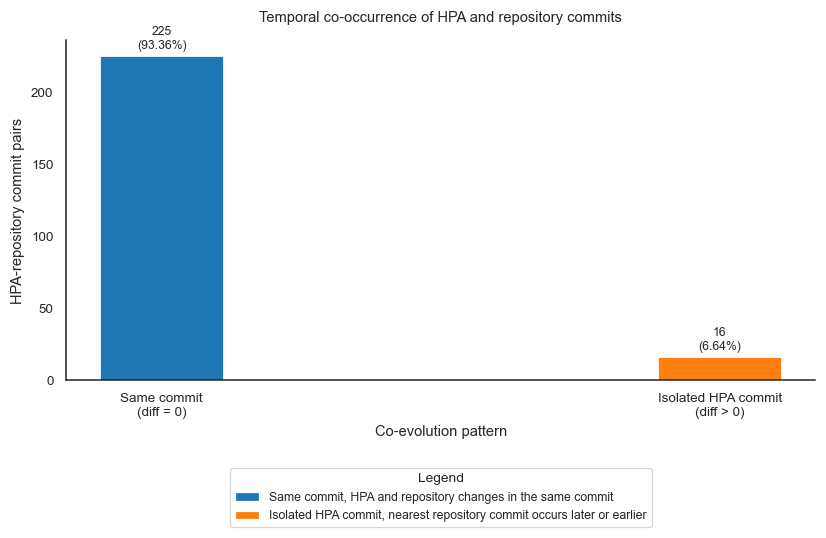

Salvo: plots/msr_analysis/fig23b_distance_to_nearest_repo_commit.pdf


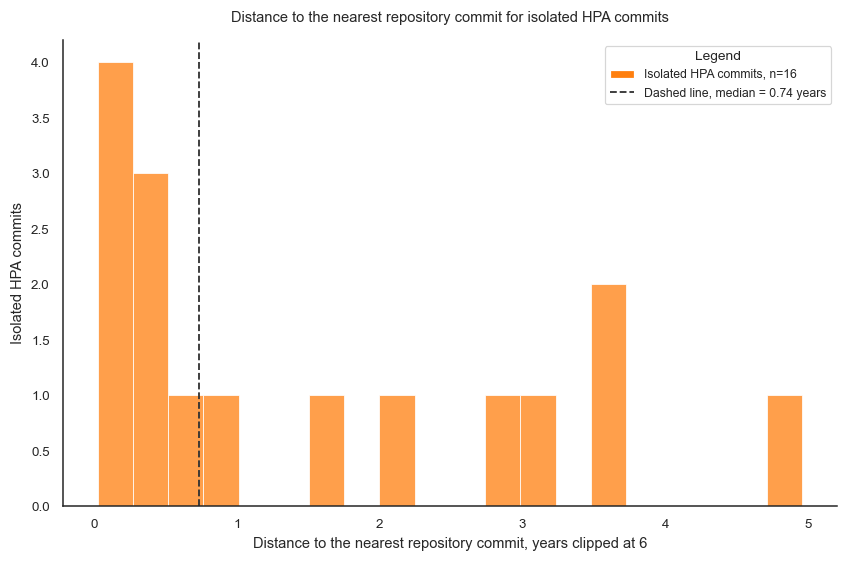

In [43]:
# ── Figure 23: temporal co-evolution of HPA commits, split PDF figures ───────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_coev_path = DATA_DIR / 'phase6_coevolution.csv'
if not _coev_path.exists():
    print('phase6_coevolution.csv not found.')
else:
    df_coev = pd.read_csv(_coev_path)
    print(f'Pairs analysed: {len(df_coev):,}')
    print(f'Unique repositories: {df_coev["repo"].nunique():,}')
    for t in [0, 1, 7, 30, 90]:
        n = (df_coev['min_diff_days'] <= t).sum()
        print(f'<= {t} days: {n:,} ({n/len(df_coev)*100:.2f}%)')

    vals = pd.to_numeric(df_coev['min_diff_days'], errors='coerce').fillna(0)
    n_zero = int((vals == 0).sum())
    n_pos = int((vals > 0).sum())
    df_nonzero = df_coev[df_coev['min_diff_days'] > 0].copy()

    # Figure 23A
    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    cats = ['Same commit\n(diff = 0)', 'Isolated HPA commit\n(diff > 0)']
    counts = [n_zero, n_pos]
    bars = ax.bar(cats, counts, color=['#1f77b4', '#ff7f0e'], edgecolor='white', linewidth=0.5, width=0.22)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.015, f'{val:,}\n({val/sum(counts)*100:.2f}%)', ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Co-evolution pattern')
    ax.set_ylabel('HPA-repository commit pairs')
    ax.set_title('Temporal co-occurrence of HPA and repository commits', pad=12)
    ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='Same commit, HPA and repository changes in the same commit'), Patch(facecolor='#ff7f0e', edgecolor='white', label='Isolated HPA commit, nearest repository commit occurs later or earlier')], title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=1, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig23a_coevolution_same_vs_isolated_commits.pdf')
    plt.show()

    # Figure 23B
    if len(df_nonzero):
        years = (df_nonzero['min_diff_days'] / 365.25).clip(upper=6)
        fig, ax = plt.subplots(figsize=(7.8, 5.2))
        sns.histplot(years, bins=20, color='#ff7f0e', edgecolor='white', linewidth=0.5, ax=ax)
        med = years.median()
        ax.axvline(med, color='#333333', linestyle='--', linewidth=1.2)
        ax.set_xlabel('Distance to the nearest repository commit, years clipped at 6')
        ax.set_ylabel('Isolated HPA commits')
        ax.set_title('Distance to the nearest repository commit for isolated HPA commits', pad=12)
        ax.legend(handles=[Patch(facecolor='#ff7f0e', edgecolor='white', label=f'Isolated HPA commits, n={len(years):,}'), Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.2, label=f'Dashed line, median = {med:.2f} years')], title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
        sp(ax); ax.grid(False)
        plt.tight_layout()
        savefig('fig23b_distance_to_nearest_repo_commit.pdf')
        plt.show()


---

## 18. Notas metodológicas

### Sobre `hpa_file_age_years` vs. `pushed_age_years`

Com a Phase 3.5 executada, `hpa_file_age_years` representa quando o arquivo HPA foi modificado pela última vez, via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`. Isso resolve o problema onde `last_commit_age_years` era idêntico à idade de `pushed_at`, que reflete qualquer commit no repositório inteiro, não do arquivo HPA especificamente.

O campo `hpa_lag_years = hpa_file_age_years - pushed_age_years` quantifica diretamente repositórios onde o arquivo HPA ficou estático enquanto o projeto continuou evoluindo. É um dado mais robusto do que o proxy `v2_ratio = 0` para identificar o padrão "stable HPA em repositório ativo".

### Sobre a não-exclusão de toy projects

Repositórios com sinais de projeto educacional são mantidos no corpus com a flag `toy_any`, não excluídos (Munaiah et al., 2017). A análise de sensibilidade (Seção 10) verifica o impacto de restringir aos subconjuntos progressivamente mais estritos.

### Filtros aplicados e sua justificativa

| Filtro | Critério | Justificativa |
|---|---|---|
| Helm templates | `Is Helm Template = True` | Valores absurdos em campos numéricos (YAML com `{{ }}`) |
| Testdata | `path` contém `testdata/` | Fixtures de teste, não configurações reais |
| Janela temporal | `pushed_age_years ≤ 5` | Cobre toda a história do HPA v2beta2/v2 GA; consistente com MSR literature (Coelho et al., 2017) |
| Repositórios sem dados | `stargazers_count = NaN` | Repositório privado ou deletado entre Phase 1 e Phase 2 |

### Reprodução

Execute `1_mine_hpa_usage.ipynb` em sequência completa antes deste notebook. A ordem mínima é: Phase 1 → Phase 2 → Phase 3 → Phase 4 → Phase 5. Phase 3.5 é fortemente recomendada para habilitar `hpa_file_age_years`. Todas as chamadas de API são cacheadas em `data/.cache/`, re-execuções são rápidas.